# 01 · Raw tables: complete profile
**Medallion re-analysis, layer 0 (raw)** · LATAM Bank dataset (Factored Datathon 2026)

## Why this notebook exists
The platform moves the 13 source tables through **raw → bronze → silver → gold (Kimball star schemas)**.
Every later layer cleans, conforms or models something it found here. This notebook is the
baseline: a complete, table-by-table profile of the raw Parquet extracts in `data/parquet/`,
so each transformation downstream can be judged against what the source really looked like.

| layer | notebook | question |
|---|---|---|
| raw | **01 (this one)** | What is in each source table: shape, types, gaps, distributions, relationships? |
| bronze | 02 | What did ingestion change (types, rejects, quarantine, lineage columns)? |
| silver | 03 | Did conformance fix the raw issues found here (labels, currencies, keys)? |
| gold | 04 | Do the Kimball facts and dimensions reconcile with the raw totals? |

## How to read it
* **Exact vs. sample.** Counts, nulls, `describe`, value counts, histograms, crosstabs and time profiles
  are computed by **DuckDB on the full table** (exact). Views that need pandas: `info()`, missingno,
  KDEs and association matrices use a **reproducible sample** of at most 200,000 rows
  (the rows with the lowest `hash(primary key, 42)`; small tables are used whole). Each view says which.
* **Null vs. missing.** *Nulls* are SQL `NULL`s. *Missing* adds **disguised** missing values:
  blank strings and placeholders such as `'N/A'`, `'None'`, `'null'`. Raw extracts often hide gaps this way.
* **Money** columns are heavy-tailed, so their histograms and KDEs use a **log10 scale**.
* **PII.** Names, document numbers, e-mails, phones, addresses, IPs and dates of birth are profiled by
  **shape and cardinality only** (`A` = letters, `9` = digit run); their values are never printed.
* **Interactivity.** Plotly charts zoom and hover; tables are searchable. The **explorers** in the last
  section are ipywidgets and need a **live kernel**: in the HTML export they show nothing.

## Contents
1. Toolkit · 2. Inventory and referential integrity
3. Core banking: customers, products, transactions, daily exchange rates
4. Network and people: branches, service agents
5. Customer service: call-center interactions, call transcripts, satisfaction surveys, complaints
6. Marketing: marketing campaigns, campaign sends
7. Digital: digital events
8. Interactive explorers · 9. Findings to carry into bronze and silver

## 1 · Toolkit
Shared helpers. Everything statistical lives in `latam_eda.profiling` (tested in `eda/tests/test_profiling.py`);
the functions below only lay out the figures, so you can tweak a view without touching the statistics.

In [1]:
import sys

sys.path.insert(0, "../../src")
import warnings

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from IPython.display import Markdown, display
from itables import init_notebook_mode, show
from plotly.subplots import make_subplots

from latam_eda import profiling as p
from latam_eda import theme
from latam_eda.data import DIMS, FACTS, PK, connect

warnings.filterwarnings("ignore", category=FutureWarning)
theme.register()
theme.register_mpl()
init_notebook_mode(all_interactive=False, connected=True)  # DataTables from the CDN, like plotly.js
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 40
con = connect()

TABLES = DIMS + FACTS
BLUE_RGB = tuple(int(theme.BLUE[i : i + 2], 16) / 255 for i in (1, 3, 5))
# Heavy-tailed money columns and multi-scale FX rates: binned and smoothed on log10
MONEY = {
    "exchange_rate",
    "buy_rate",
    "sell_rate",
    "amount",
    "amount_usd",
    "current_balance",
    "credit_limit",
    "estimated_monthly_income",
    "claimed_amount",
    "compensation_granted",
    "conversion_value",
    "budget",
    "send_cost",
    "event_value",
}
# (partition date, event timestamp) of each time-stamped table
TIME = {
    "transactions": ("process_date", "transaction_date"),
    "digital_events": ("process_date", "event_date"),
    "call_center_interactions": ("process_date", "interaction_date"),
    "call_transcripts": ("process_date", None),
    "campaign_sends": ("process_date", "send_date"),
    "complaints": ("process_date", "creation_date"),
    "satisfaction_surveys": ("process_date", "survey_date"),
    "daily_exchange_rates": ("date", None),
}
OV: dict[str, pd.DataFrame] = {}  # overview per table, filled as sections run
_samples: dict[str, pd.DataFrame] = {}


def rel(t):
    return f"m_{t}"


def smp(t, n=200_000):
    """Cached reproducible sample of table t (whole table when small)."""
    if t not in _samples:
        _samples[t] = p.sample(con, rel(t), n=n, key=PK.get(t))
    return _samples[t]


def kinds(t, *ks):
    return p.cols_of(con, rel(t), *ks)


def missing_view(df):
    """Placeholders ('', 'N/A', 'None'...) turned into NaN, for the 'missing data' views."""
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_string_dtype(out[c]) or out[c].dtype == object:
            s = out[c].astype("string").str.strip().str.lower()
            out[c] = out[c].mask(s.isin(p.PLACEHOLDERS))
    return out


def h(text):
    display(Markdown(text))


def fmt_overview(ov):
    cols = [
        "dtype",
        "kind",
        "non_null",
        "nulls",
        "placeholders",
        "null_pct",
        "missing_pct",
        "distinct",
        "distinct_pct",
    ]
    return (
        ov.set_index("column")[cols]
        .style.format(
            {
                "non_null": "{:,}",
                "nulls": "{:,}",
                "placeholders": "{:,}",
                "distinct": "{:,}",
                "null_pct": "{:.1f}%",
                "missing_pct": "{:.1f}%",
                "distinct_pct": "{:.1f}%",
            }
        )
        .background_gradient(
            cmap=theme.cmap_seq(), subset=["null_pct", "missing_pct"], vmin=0, vmax=100
        )
        .bar(subset=["distinct_pct"], color=theme.SEQ_BLUE[1], vmin=0, vmax=100)
    )


# ---------- per-table core views ----------
def show_overview(t):
    """Shape, primary key, pandas info() on the sample, and the per-column null/missing/distinct table."""
    ov = p.overview(con, rel(t))
    OV[t] = ov
    n = ov.attrs["rows"]
    s = smp(t)
    mem = s.memory_usage(deep=True).sum() * n / max(len(s), 1) / 1e6
    line = f"**Shape** {n:,} rows × {len(ov)} columns · **est. pandas memory (full table)** {mem:,.0f} MB"
    if t in PK:
        k = p.pk_check(con, rel(t), PK[t])
        ok = "unique" if k["duplicate_keys"] == 0 and k["null_keys"] == 0 else "**NOT unique**"
        line += f" · **PK** `{PK[t]}` {ok} ({k['duplicate_keys']:,} duplicated, {k['null_keys']:,} null)"
    else:
        line += " · no single-column primary key"
    h(line)
    h(f"`info()` on the sample ({len(s):,} rows):")
    s.info(memory_usage="deep", show_counts=True)
    display(fmt_overview(ov))


def show_describe(t):
    """Exact describe() of numeric columns, plus describe() of the non-numeric columns (sample)."""
    num = kinds(t, "numeric")
    if num:
        h(
            "**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share"
        )
        d = p.numeric_summary(con, rel(t), num)
        shares = ["zero_share", "negative_share", "iqr_outlier_share"]
        display(
            d.style.format("{:,.2f}")
            .format("{:.1%}", subset=shares)
            .background_gradient(cmap=theme.cmap_seq(), subset=shares, vmin=0, vmax=1)
        )
    other = p.safe(smp(t)).select_dtypes(exclude="number")
    if other.shape[1]:
        h(
            "**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency"
        )
        display(other.astype("string").describe().T)


def show_missing(t):
    """missingno matrix (rows in time order), bar, nullity correlation heatmap and dendrogram."""
    df = missing_view(smp(t))
    order = TIME.get(t, (None, None))
    sort_col = order[1] or order[0]
    if sort_col and sort_col in df:
        df = df.sort_values(sort_col)
    gaps = [c for c in df.columns if df[c].isna().any()]
    if not gaps:
        h("No nulls or placeholders in this table.")
        return
    h(
        f"**Missing data (nulls + placeholders), sample.** {len(gaps)} of {df.shape[1]} columns have gaps. "
        "The matrix rows run in time order, so a block that starts or stops mid-way means the field "
        "was added or dropped at some date."
    )
    view = df.iloc[:: max(1, len(df) // 3000)]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [3, 2]})
    msno.matrix(view, ax=axes[0], color=BLUE_RGB, sparkline=False, fontsize=8)
    msno.bar(df, ax=axes[1], color=BLUE_RGB, fontsize=8)
    for ax in axes:
        ax.grid(False)
    axes[0].set_title("Nullity matrix (dark = present)")
    axes[1].set_title("Share present per column")
    plt.tight_layout()
    plt.show()
    partial = [c for c in gaps if df[c].notna().any()]
    if len(partial) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(16, max(4, 0.35 * len(partial) + 2)))
        msno.heatmap(df[partial], ax=axes[0], cmap=theme.cmap_div(), fontsize=8, cbar=False)
        axes[0].set_title(
            "Nullity correlation (+1 missing together, −1 one or the other; blank = none)"
        )
        for ax in axes:
            ax.grid(False)
        if len(partial) >= 3:
            msno.dendrogram(df[partial], ax=axes[1], fontsize=8, orientation="left")
            axes[1].set_title("Nullity clusters")
        else:
            axes[1].axis("off")
        plt.tight_layout()
        plt.show()


def show_distributions(t, cols=None, per_row=3):
    """SQL-binned histograms over the full table (log10 bins for money) and sample KDEs."""
    num = cols or kinds(t, "numeric")
    if not num:
        return
    rows = -(-len(num) // per_row)
    fig = make_subplots(
        rows=rows,
        cols=per_row,
        subplot_titles=[f"{c} (log10)" if c in MONEY else c for c in num],
        vertical_spacing=0.12 / max(rows, 1) * 3,
    )
    for i, c in enumerate(num):
        hist = p.binned_hist(con, rel(t), c, bins=40, log=c in MONEY)
        mid = (
            (hist["left"] * hist["right"]) ** 0.5
            if c in MONEY
            else (hist["left"] + hist["right"]) / 2
        )
        r, k = divmod(i, per_row)
        fig.add_bar(
            x=mid,
            y=hist["n"],
            marker_color=theme.BLUE,
            showlegend=False,
            row=r + 1,
            col=k + 1,
            customdata=np.c_[hist["left"], hist["right"]],
            hovertemplate="%{customdata[0]:,.2f} – %{customdata[1]:,.2f}<br>%{y:,} rows<extra></extra>",
        )
        if c in MONEY:
            fig.update_xaxes(type="log", row=r + 1, col=k + 1)
    fig.update_layout(
        title=f"{t}: numeric distributions (exact, full table)", height=260 * rows + 80, bargap=0.02
    )
    fig.update_annotations(font_size=12)
    fig.show()

    s = smp(t)
    smooth = [c for c in num if s[c].nunique() > 10]
    if not smooth:
        return
    rows = -(-len(smooth) // per_row)
    fig, axes = plt.subplots(rows, per_row, figsize=(5.3 * per_row, 2.6 * rows), squeeze=False)
    for ax, c in zip(axes.flat, smooth):
        x = s[c].dropna().astype(float)
        x = x[x > 0] if c in MONEY else x
        x = x.sample(min(len(x), 50_000), random_state=0)
        sns.kdeplot(
            x=x,
            ax=ax,
            fill=True,
            color=theme.BLUE,
            alpha=0.25,
            linewidth=1.4,
            cut=0,
            log_scale=c in MONEY,
            warn_singular=False,
        )
        ax.axvline(x.median(), color=theme.INK2, linewidth=0.8, linestyle="--")
        ax.set_title(f"{c}  (median {x.median():,.2f})", fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
    for ax in axes.flat[len(smooth) :]:
        ax.axis("off")
    fig.suptitle(f"{t}: kernel density (sample; dashed = median)", x=0.01, ha="left", fontsize=12)
    plt.tight_layout()
    plt.show()


def show_categories(t, per_row=3, top=12):
    """Exact top-N value counts of every categorical and boolean column, as bars and a searchable table."""
    cats = kinds(t, "categorical", "boolean")
    if not cats:
        return
    vcs = {c: p.value_counts(con, rel(t), c, top=top) for c in cats}
    rows = -(-len(cats) // per_row)
    titles = [f"{c} ({vcs[c].attrs['cardinality']:,} values)" for c in cats]
    fig = make_subplots(
        rows=rows,
        cols=per_row,
        subplot_titles=titles,
        horizontal_spacing=0.18,
        vertical_spacing=0.25 / max(rows, 1) + 0.03,
    )
    for i, c in enumerate(cats):
        vc = vcs[c].iloc[::-1]
        colors = [
            theme.GRID if str(v).startswith(("(other", "(null")) else theme.BLUE
            for v in vc["value"]
        ]
        r, k = divmod(i, per_row)
        fig.add_bar(
            x=vc["share_pct"],
            y=vc["value"].astype(str).str.slice(0, 28),
            orientation="h",
            marker_color=colors,
            showlegend=False,
            row=r + 1,
            col=k + 1,
            customdata=vc["n"],
            hovertemplate="%{y}: %{customdata:,} rows (%{x:.1f}%)<extra></extra>",
        )
    fig.update_layout(
        title=f"{t}: categories (exact; share of rows, %; gray = tail or null)",
        height=max(330, 60 + 300 * rows),
    )
    fig.update_yaxes(tickfont_size=10, type="category")  # codes such as postal_code stay labels
    fig.update_annotations(font_size=12)
    fig.show()
    long = pd.concat([v.assign(column=c) for c, v in vcs.items()])[
        ["column", "value", "n", "share_pct", "cum_pct"]
    ]
    show(
        long,
        caption=f"{t}: value counts (top {top} + tail), searchable",
        pageLength=10,
        classes="display compact",
    )


def show_associations(t):
    """Spearman correlation of numeric/boolean columns and Cramér's V of low-cardinality categoricals."""
    s = smp(t)
    num = [c for c in kinds(t, "numeric", "boolean") if s[c].nunique() > 1]
    cats = [c for c in kinds(t, "categorical", "boolean") if 2 <= s[c].nunique() <= 60]
    panels = [x for x in (("num", num), ("cat", cats)) if len(x[1]) >= 2]
    if not panels:
        return
    fig, axes = plt.subplots(
        1,
        len(panels),
        figsize=(8 * len(panels), 0.42 * max(len(num), len(cats)) + 3),
        squeeze=False,
    )
    for ax, (which, cols) in zip(axes.flat, panels):
        # lower triangle without the all-1 diagonal, so the colour scale is spent on the pairs
        if which == "num":
            m = p.spearman_matrix(s, cols).iloc[1:, :-1]
            sns.heatmap(
                m,
                ax=ax,
                cmap=theme.cmap_div(),
                vmin=-1,
                vmax=1,
                annot=len(cols) <= 12,
                fmt=".2f",
                mask=np.triu(np.ones_like(m, dtype=bool), 1),
                cbar_kws={"shrink": 0.6},
                annot_kws={"size": 8},
                linewidths=0.5,
                linecolor=theme.SURFACE,
            )
            ax.set_title("Spearman rank correlation (sample)")
        else:
            m = p.cramers_v_matrix(s.sample(min(len(s), 50_000), random_state=0), cols).iloc[
                1:, :-1
            ]
            sns.heatmap(
                m,
                ax=ax,
                cmap=theme.cmap_seq(),
                vmin=0,
                vmax=1,
                annot=len(cols) <= 12,
                fmt=".2f",
                mask=np.triu(np.ones_like(m, dtype=bool), 1),
                cbar_kws={"shrink": 0.6},
                annot_kws={"size": 8},
                linewidths=0.5,
                linecolor=theme.SURFACE,
            )
            ax.set_title("Cramér's V, bias-corrected (sample)")
        ax.tick_params(labelsize=8)
        ax.grid(False)
    plt.tight_layout()
    plt.show()


def show_time(t):
    """Daily volume by partition date (with 28-day mean) and weekday × hour heatmap of the event timestamp."""
    if t not in TIME:
        return
    part, ts = TIME[t]
    d = p.time_profile(con, rel(t), part, "day")
    d["mean_28d"] = d["value"].rolling(28, min_periods=7).mean()
    fig = go.Figure()
    fig.add_scatter(
        x=d["period"],
        y=d["value"],
        mode="lines",
        name="rows per day",
        line=dict(color=theme.SEQ_BLUE[1], width=1),
    )
    fig.add_scatter(
        x=d["period"],
        y=d["mean_28d"],
        mode="lines",
        name="28-day mean",
        line=dict(color=theme.BLUE, width=2.2),
    )
    fig.update_layout(
        title=f"{t}: rows per {part} (exact)", height=320, yaxis_title="rows", hovermode="x unified"
    )
    fig.show()
    if ts:
        g = p.weekday_hour(con, rel(t), ts)
        fig = px.imshow(
            g,
            color_continuous_scale=theme.SEQ_SCALE,
            aspect="auto",
            labels=dict(x="hour of day", y="", color="rows"),
        )
        fig.update_layout(title=f"{t}: rows by weekday × hour of {ts} (exact)", height=300)
        fig.show()


# ---------- small builders for the bespoke views ----------
def wilson(k, n, z=1.96):
    """95% Wilson interval for a proportion (stable for the rare events of fraud and churn)."""
    k, n = np.asarray(k, float), np.asarray(n, float)
    ph = np.divide(k, n, out=np.zeros_like(k), where=n > 0)
    den = 1 + z**2 / n
    centre = (ph + z**2 / (2 * n)) / den
    half = z * np.sqrt(ph * (1 - ph) / n + z**2 / (4 * n**2)) / den
    return centre - half, centre + half


def rate_by(t, by, flag, top=20, min_n=200):
    """Exact rate of a boolean SQL expression per category, with Wilson 95% intervals."""
    df = con.sql(
        f"""select {p.q(by)}::varchar as level, count(*) n, sum(({flag})::int) k
            from {rel(t)} group by 1 having count(*) >= {min_n} order by n desc limit {top}"""
    ).df()
    df["level"] = df["level"].fillna("(null)")
    df["rate"] = df["k"] / df["n"]
    df["lo"], df["hi"] = wilson(df["k"], df["n"])
    return df.sort_values("rate")


def rate_bars(frames, title, pct=True, per_row=2, height=300):
    """Small multiples of horizontal rate bars with 95% CIs; frames = {subtitle: rate_by(...)}."""
    rows = -(-len(frames) // per_row)
    fig = make_subplots(
        rows=rows, cols=per_row, subplot_titles=list(frames), horizontal_spacing=0.2
    )
    m = 100 if pct else 1
    for i, df in enumerate(frames.values()):
        r, k = divmod(i, per_row)
        fig.add_bar(
            x=df["rate"] * m,
            y=df["level"],
            orientation="h",
            marker_color=theme.BLUE,
            showlegend=False,
            error_x=dict(
                type="data",
                symmetric=False,
                array=(df["hi"] - df["rate"]) * m,
                arrayminus=(df["rate"] - df["lo"]) * m,
                color=theme.INK2,
                thickness=1,
            ),
            customdata=np.c_[df["k"], df["n"]],
            row=r + 1,
            col=k + 1,
            hovertemplate="%{y}: %{x:.3f}"
            + ("%" if pct else "")
            + " (%{customdata[0]:,} of %{customdata[1]:,})<extra></extra>",
        )
    fig.update_layout(title=title, height=height * rows + 60)
    fig.update_annotations(font_size=12)
    fig.show()


def heat(ct, title, fmt=".1f", scale=None, height=None, zmid=None):
    """Annotated plotly heatmap for a crosstab."""
    fig = px.imshow(
        ct,
        text_auto=fmt,
        aspect="auto",
        color_continuous_scale=scale or theme.SEQ_SCALE,
        color_continuous_midpoint=zmid,
    )
    fig.update_layout(title=title, height=height or max(320, 34 * len(ct) + 140))
    fig.update_xaxes(side="bottom", tickangle=-30)
    fig.show()


def core(t):
    """The full standard profile of one table, in order."""
    show_overview(t)
    show_describe(t)
    show_missing(t)
    show_distributions(t)
    show_categories(t)
    show_associations(t)
    show_time(t)

## 2 · Inventory and referential integrity
### 2.1 All tables at a glance
One row per table, all exact. *Cells missing* counts nulls plus placeholders over every cell.

In [2]:
inv = []
for t in TABLES:
    ov = p.overview(con, rel(t))
    OV[t] = ov
    n = ov.attrs["rows"]
    part = TIME.get(t, (None,))[0]
    rng = (
        con.sql(
            f"select min({part})::varchar || ' → ' || max({part})::varchar from {rel(t)}"
        ).fetchone()[0]
        if part
        else "snapshot"
    )
    k = p.pk_check(con, rel(t), PK[t]) if t in PK else None
    inv.append(
        {
            "table": t,
            "role": "fact" if t in FACTS else "dimension",
            "rows": n,
            "columns": len(ov),
            "cells_null_pct": 100 * ov["nulls"].sum() / (n * len(ov)),
            "cells_missing_pct": 100 * ov["missing"].sum() / (n * len(ov)),
            "cols_with_gaps": int((ov["missing"] > 0).sum()),
            "coverage": rng,
            "pk": PK.get(t, "—"),
            "pk_duplicates": k["duplicate_keys"] if k else None,
            "pii_cols": int((ov["kind"] == "pii").sum()),
        }
    )
inv = pd.DataFrame(inv).set_index("table")
display(
    inv.style.format(
        {
            "rows": "{:,}",
            "cells_null_pct": "{:.1f}%",
            "cells_missing_pct": "{:.1f}%",
            "pk_duplicates": "{:,.0f}",
        }
    )
    .background_gradient(cmap=theme.cmap_seq(), subset=["cells_missing_pct"], vmin=0, vmax=60)
    .bar(subset=["rows"], color=theme.SEQ_BLUE[1])
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,role,rows,columns,cells_null_pct,cells_missing_pct,cols_with_gaps,coverage,pk,pk_duplicates,pii_cols
table,,,,,,,,,,
customers,dimension,"150,000",27,6.1%,6.1%,11,snapshot,customer_id,0,8
products,dimension,"400,000",17,14.0%,14.0%,5,snapshot,product_id,0,0
branches,dimension,350,22,0.0%,0.0%,0,snapshot,branch_id,0,3
service_agents,dimension,"1,200",18,5.4%,5.4%,5,snapshot,agent_id,0,4
marketing_campaigns,dimension,200,13,11.4%,11.4%,6,snapshot,campaign_id,0,0
daily_exchange_rates,dimension,"13,164",7,0.0%,0.0%,0,2023-06-17 → 2026-06-17,—,nan,0
transactions,fact,"4,425,008",22,24.4%,24.4%,10,2023-06-17 → 2026-06-17,transaction_id,0,0
digital_events,fact,"15,620,994",26,31.9%,31.9%,17,2023-06-17 → 2026-06-17,event_id,0,1
call_center_interactions,fact,"686,296",21,7.8%,7.8%,5,2023-06-17 → 2026-06-17,interaction_id,0,0


In [3]:
fig = px.bar(
    inv.reset_index().sort_values("rows"),
    x="rows",
    y="table",
    orientation="h",
    log_x=True,
    color="role",
    color_discrete_map={"fact": theme.BLUE, "dimension": theme.AQUA},
    text="rows",
)
fig.update_traces(texttemplate="%{x:,.0f}", textposition="outside", cliponaxis=False)
fig.update_layout(
    title="Row count per table (log scale)", height=430, xaxis_title="rows (log)", yaxis_title=""
)
fig.show()

### 2.2 Where the gaps are
Every column of every table as one dot: its missing rate (nulls + placeholders). Hover for the column name.
Dots far to the right are fields that are optional by design (e.g. merchant data on non-card
transactions) **or** extraction gaps; each table section tells which.

In [4]:
gaps = pd.concat([OV[t].assign(table=t) for t in TABLES])
gaps["disguised"] = gaps["placeholders"] > 0
fig = px.strip(
    gaps,
    x="missing_pct",
    y="table",
    color="disguised",
    hover_name="column",
    hover_data={
        "null_pct": ":.1f",
        "missing_pct": ":.1f",
        "placeholders": ":,",
        "disguised": False,
    },
    color_discrete_map={False: theme.BLUE, True: theme.ORANGE},
)
fig.update_traces(
    marker=dict(size=9, opacity=0.75, line=dict(width=0.5, color="white")), jitter=0.4
)
fig.update_layout(
    title="Missing rate per column (orange: includes placeholder strings)",
    height=520,
    xaxis_title="missing, % of rows",
    yaxis_title="",
    legend_title_text="has placeholders",
    showlegend=bool(gaps["disguised"].any()),
)
fig.show()
disguised = gaps.loc[
    gaps["placeholders"] > 0, ["table", "column", "nulls", "placeholders", "missing_pct"]
]
if disguised.empty:
    h(
        f"**No placeholder strings** ({', '.join(repr(x) for x in p.PLACEHOLDERS)}) in any text column: "
        "every gap in the raw extracts is a real SQL `NULL`."
    )
else:
    display(
        disguised.sort_values("placeholders", ascending=False)
        .reset_index(drop=True)
        .style.format({"nulls": "{:,}", "placeholders": "{:,}", "missing_pct": "{:.1f}%"})
        .set_caption("Columns with disguised missing values (placeholders)")
    )

**No placeholder strings** ('', 'n/a', 'na', 'null', 'none', 'nan', '-', '?', 'undefined') in any text column: every gap in the raw extracts is a real SQL `NULL`.

### 2.3 Referential integrity at a glance
For each foreign key: the share of non-null child rows whose key is **absent** from the parent table.
Orphans in raw data are normal (late-arriving dimensions, deleted parents); bronze and silver must decide
whether to quarantine them or add an *unknown member* to the dimension (Kimball).

In [5]:
FKS = [
    ("products", "customer_id", "customers", "customer_id"),
    ("transactions", "customer_id", "customers", "customer_id"),
    ("transactions", "product_id", "products", "product_id"),
    ("transactions", "branch_id", "branches", "branch_id"),
    ("customers", "registration_branch_id", "branches", "branch_id"),
    ("products", "opening_branch_id", "branches", "branch_id"),
    ("service_agents", "assigned_branch_id", "branches", "branch_id"),
    ("call_center_interactions", "customer_id", "customers", "customer_id"),
    ("call_center_interactions", "agent_id", "service_agents", "agent_id"),
    ("call_transcripts", "interaction_id", "call_center_interactions", "interaction_id"),
    ("satisfaction_surveys", "interaction_id", "call_center_interactions", "interaction_id"),
    ("satisfaction_surveys", "customer_id", "customers", "customer_id"),
    ("complaints", "customer_id", "customers", "customer_id"),
    ("complaints", "affected_product_id", "products", "product_id"),
    ("complaints", "assigned_agent_id", "service_agents", "agent_id"),
    ("campaign_sends", "campaign_id", "marketing_campaigns", "campaign_id"),
    ("campaign_sends", "customer_id", "customers", "customer_id"),
    ("digital_events", "customer_id", "customers", "customer_id"),
]
ri = []
for child, ck, parent, pk_ in FKS:
    r = con.sql(
        f"""select count(c.{ck}) as non_null,
                   count(c.{ck}) filter (where p.{pk_} is null) as orphans,
                   count(distinct c.{ck}) filter (where p.{pk_} is null) as orphan_keys
            from {rel(child)} c left join (select distinct {pk_} from {rel(parent)}) p on c.{ck} = p.{pk_}"""
    ).fetchone()
    ri.append(
        {
            "child": f"{child}.{ck}",
            "parent": f"{parent}.{pk_}",
            "non_null_rows": r[0],
            "orphan_rows": r[1],
            "orphan_keys": r[2],
            "orphan_pct": 100 * r[1] / max(r[0], 1),
        }
    )
ri = pd.DataFrame(ri).sort_values("orphan_pct", ascending=False)
display(
    ri.style.format(
        {
            "non_null_rows": "{:,}",
            "orphan_rows": "{:,}",
            "orphan_keys": "{:,}",
            "orphan_pct": "{:.2f}%",
        }
    )
    .background_gradient(cmap=theme.cmap_seq(), subset=["orphan_pct"], vmin=0, vmax=20)
    .hide(axis="index")
)

child,parent,non_null_rows,orphan_rows,orphan_keys,orphan_pct
customers.registration_branch_id,branches.branch_id,"150,000","149,995","149,995",100.00%
service_agents.assigned_branch_id,branches.branch_id,833,831,831,99.76%
products.customer_id,customers.customer_id,"400,000",0,0,0.00%
satisfaction_surveys.interaction_id,call_center_interactions.interaction_id,"212,759",0,0,0.00%
campaign_sends.customer_id,customers.customer_id,"1,746,801",0,0,0.00%
campaign_sends.campaign_id,marketing_campaigns.campaign_id,"1,746,801",0,0,0.00%
complaints.assigned_agent_id,service_agents.agent_id,"43,980",0,0,0.00%
complaints.affected_product_id,products.product_id,"44,570",0,0,0.00%
complaints.customer_id,customers.customer_id,"67,095",0,0,0.00%
satisfaction_surveys.customer_id,customers.customer_id,"212,759",0,0,0.00%


## 3 · Core banking
### 3.1 `customers` (dimension)
**Grain:** one row per customer. **Key:** `customer_id`. The customer is the conformed dimension that
every fact table joins to; its quality bounds the quality of every customer-level KPI.
Watch for: segment and status mix, credit-score and income ranges, PII formats, registration dates.

In [6]:
t = "customers"
show_overview(t)
show_describe(t)

**Shape** 150,000 rows × 27 columns · **est. pandas memory (full table)** 64 MB · **PK** `customer_id` unique (0 duplicated, 0 null)

`info()` on the sample (150,000 rows):

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   customer_id               150000 non-null  str           
 1   document_number           150000 non-null  str           
 2   document_type             150000 non-null  str           
 3   first_name                150000 non-null  str           
 4   last_name                 150000 non-null  str           
 5   date_of_birth             150000 non-null  datetime64[us]
 6   gender                    150000 non-null  str           
 7   email                     147016 non-null  str           
 8   mobile_phone              145293 non-null  str           
 9   landline_phone            74947 non-null   str           
 10  address                   142630 non-null  str           
 11  city                      150000 non-null  str           
 12  state        

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
customer_id,VARCHAR,identifier,"150,000",0,0,0.0%,0.0%,"150,000",100.0%
document_number,VARCHAR,pii,"150,000",0,0,0.0%,0.0%,"150,000",100.0%
document_type,VARCHAR,categorical,"150,000",0,0,0.0%,0.0%,4,0.0%
first_name,VARCHAR,pii,"150,000",0,0,0.0%,0.0%,"6,810",4.5%
last_name,VARCHAR,pii,"150,000",0,0,0.0%,0.0%,"4,365",2.9%
date_of_birth,DATE,pii,"150,000",0,0,0.0%,0.0%,"21,747",14.5%
gender,VARCHAR,categorical,"150,000",0,0,0.0%,0.0%,3,0.0%
email,VARCHAR,pii,"147,016","2,984",0,2.0%,2.0%,"84,951",57.8%
mobile_phone,VARCHAR,pii,"145,293","4,707",0,3.1%,3.1%,"145,293",100.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
credit_score,"127,508.00",647.10,76.85,422.00,514.00,591.00,631.00,695.00,850.00,850.00,0.67,-0.10,0.0%,0.0%,0.0%
estimated_monthly_income,"119,967.00","5,895,961.54","14,471,948.23","5,100.28","10,309.83","39,227.56","342,974.42","5,362,111.88","85,949,515.99","111,895,075.15",4.23,20.75,0.0%,0.0%,10.2%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
customer_id,150000,150000,CLI-G4X2AMVD62NR,1
document_type,150000,4,DNI,104749
gender,150000,3,F,50508
city,150000,16,Guadalajara,12643
state,150000,16,Jalisco,12643
country,150000,3,México,74907
postal_code,134956,8419,44100,11413
detected_accent,105183,3,mexican,52505
segment,150000,4,Basic,89756
occupation,134961,20,Manager,6862


**Missing data (nulls + placeholders), sample.** 11 of 27 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

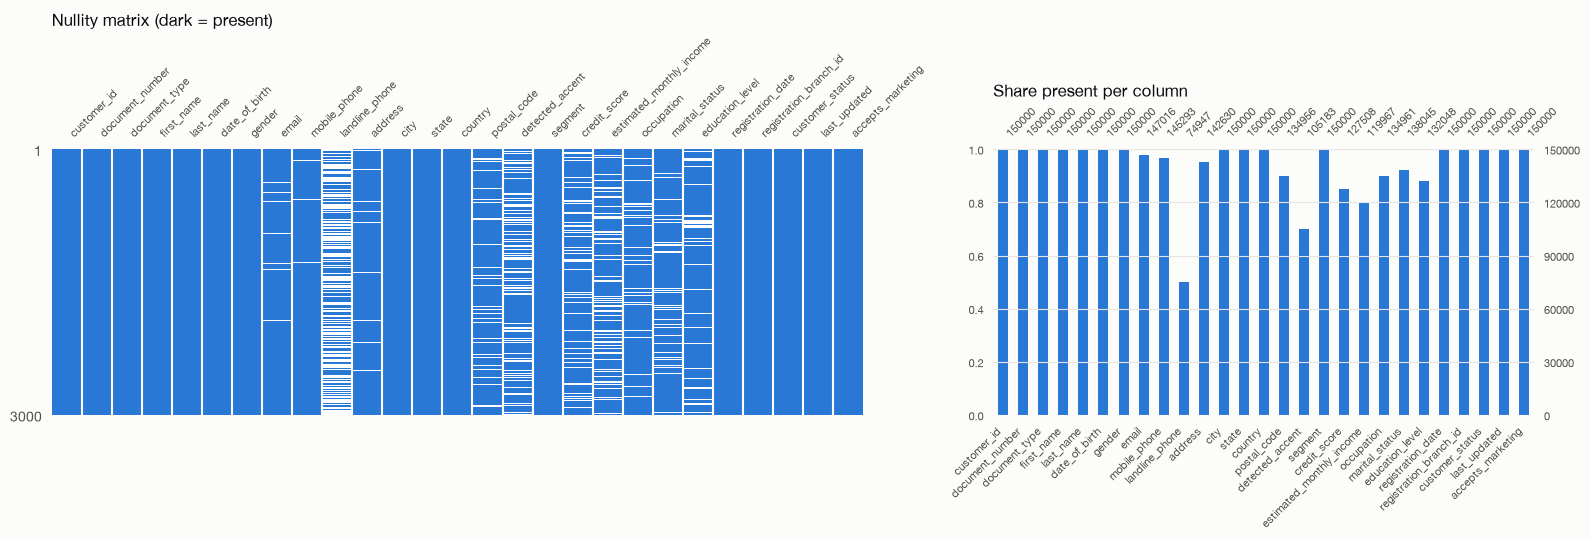

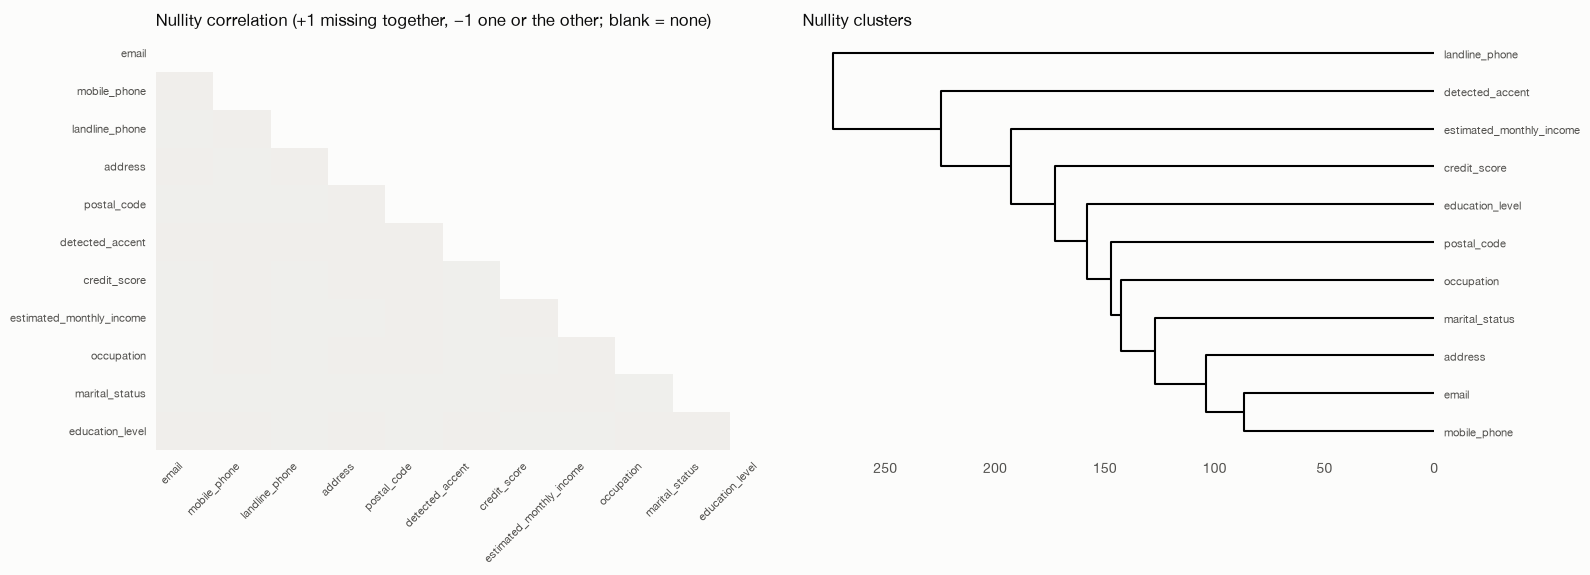

In [7]:
show_missing(t)

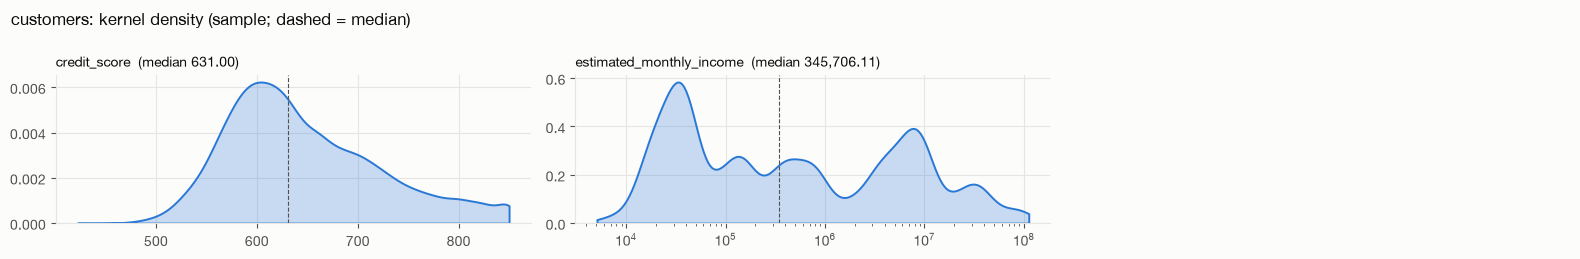

In [8]:
show_distributions(t)
show_categories(t)

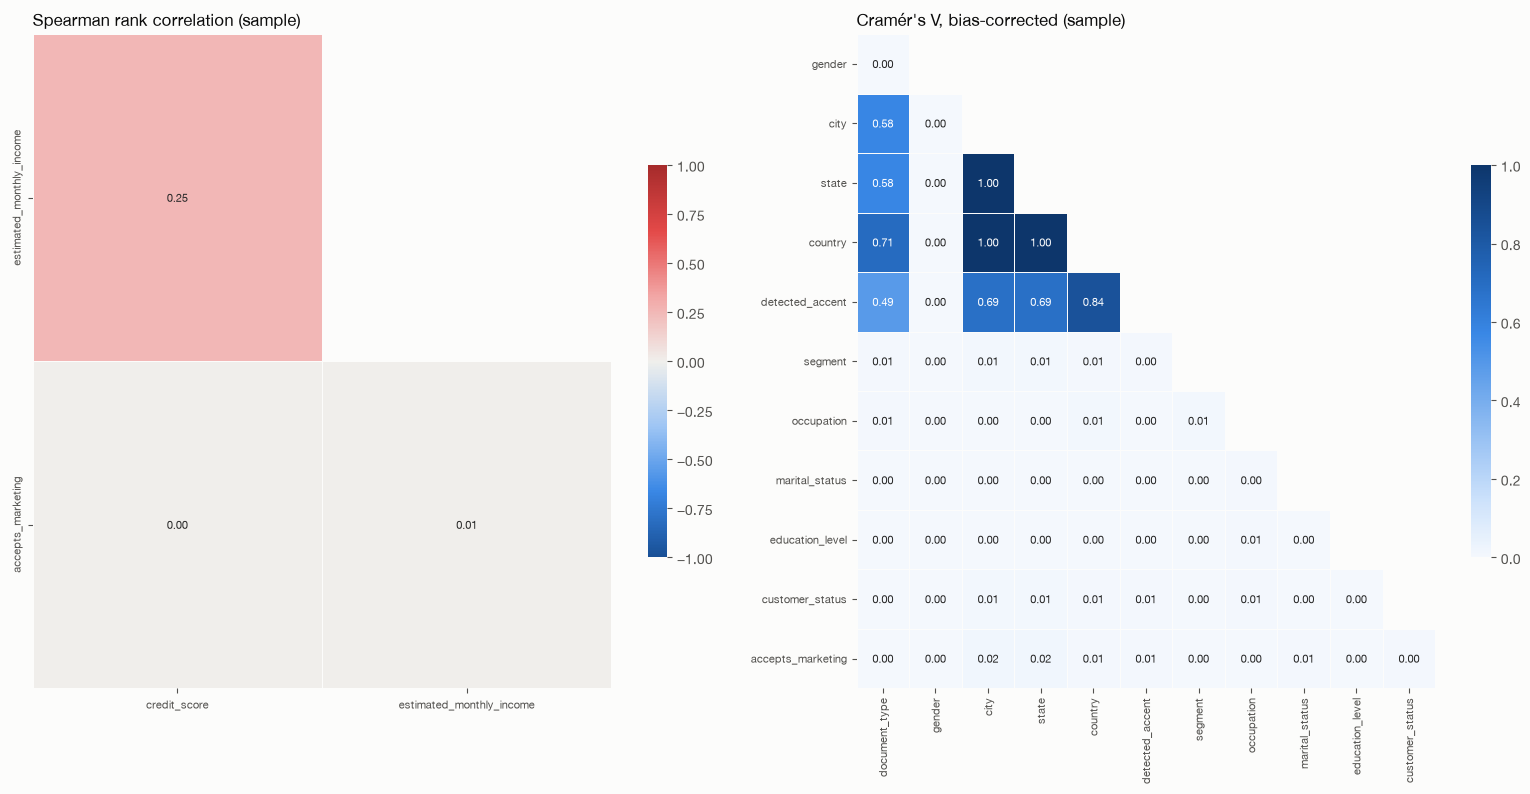

In [9]:
show_associations(t)

**PII formats (shape only, no values).** A clean document or phone column has one or two dominant shapes;
many shapes mean mixed formats that silver must standardise before matching or masking.

In [10]:
for c in ["document_number", "email", "mobile_phone", "landline_phone", "postal_code"]:
    pat = p.pattern_profile(con, rel(t), c, top=5)
    pat["share_pct"] = 100 * pat["n"] / OV[t].attrs["rows"]
    h(f"`{c}`")
    display(
        pat.style.format({"n": "{:,}", "avg_len": "{:.1f}", "share_pct": "{:.1f}%"}).hide(
            axis="index"
        )
    )

`document_number`

pattern,n,avg_len,share_pct
9,"134,938",8.1,90.0%
A9,"15,062",8.0,10.0%


`email`

pattern,n,avg_len,share_pct
A@A.A,"73,567",21.3,49.0%
A.A9@A.A,"36,947",27.8,24.6%
A.A@A.A,"36,502",24.9,24.3%
(null),"2,984",nan,2.0%


`mobile_phone`

pattern,n,avg_len,share_pct
+9 9 9 9 9,"101,445",18.0,67.6%
+9 9 9 9,"43,848",16.0,29.2%
(null),"4,707",nan,3.1%


`landline_phone`

pattern,n,avg_len,share_pct
(null),"75,053",nan,50.0%
+9 9 9 9,"74,947",15.4,50.0%


`postal_code`

pattern,n,avg_len,share_pct
9,"108,088",5.2,72.1%
A9,"26,868",5.0,17.9%
(null),"15,044",nan,10.0%


In [11]:
age = con.sql(
    """select gender, (floor(date_diff('year', date_of_birth, current_date) / 5) * 5)::int as band, count(*) n
       from m_customers where date_of_birth is not null group by 1, 2 order by 2"""
).df()
age["signed"] = np.where(age["gender"] == age["gender"].mode()[0], -age["n"], age["n"])
fig = px.bar(
    age,
    x="signed",
    y="band",
    color="gender",
    orientation="h",
    barmode="relative",
    color_discrete_sequence=[theme.BLUE, theme.ORANGE, theme.AQUA, theme.VIOLET],
    custom_data=["n"],
)
fig.update_traces(hovertemplate="%{y}–%{y}+4 years: %{customdata[0]:,}<extra></extra>")
fig.update_layout(
    title="Age pyramid (5-year bands, from date_of_birth; exact)",
    height=480,
    xaxis_title="customers",
    yaxis_title="age band",
    bargap=0.08,
)
fig.update_xaxes(
    tickvals=[-20000, -10000, 0, 10000, 20000], ticktext=["20k", "10k", "0", "10k", "20k"]
)
fig.show()

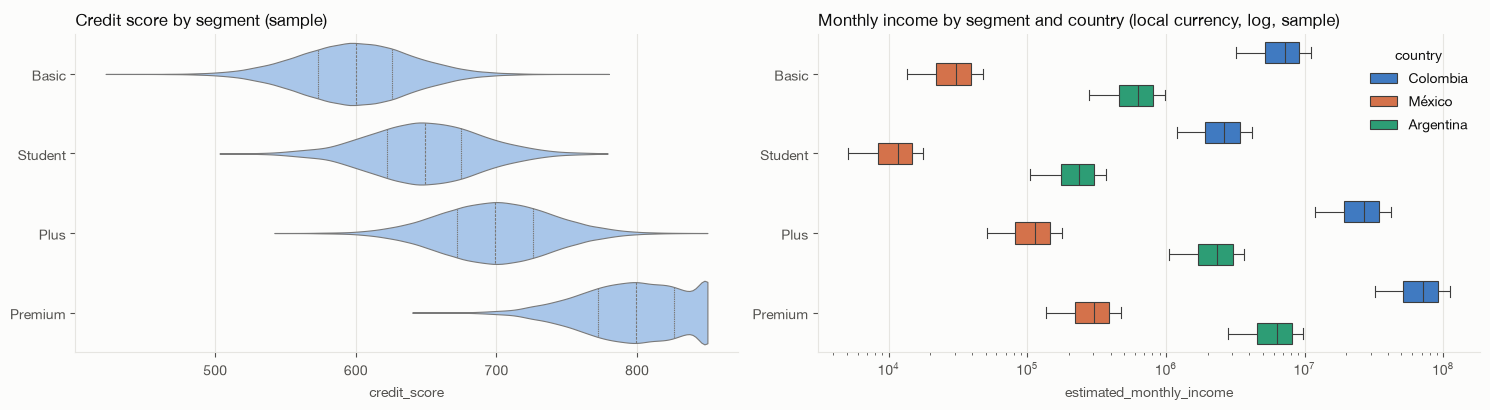

In [12]:
s = smp(t)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
order = s.groupby("segment")["credit_score"].median().sort_values().index
sns.violinplot(
    data=s,
    x="credit_score",
    y="segment",
    order=order,
    ax=axes[0],
    color=theme.SEQ_BLUE[1],
    inner="quartile",
    cut=0,
    linewidth=0.8,
)
axes[0].set_title("Credit score by segment (sample)")
sns.boxplot(
    data=s,
    x="estimated_monthly_income",
    y="segment",
    hue="country",
    order=order,
    ax=axes[1],
    palette=theme.CATEGORICAL[: s["country"].nunique()],
    log_scale=True,
    fliersize=1,
    linewidth=0.8,
)
axes[1].set_title("Monthly income by segment and country (local currency, log, sample)")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()
heat(
    p.crosstab(con, rel(t), "segment", "country", normalize="column"),
    "Segment mix within each country (% of the country's customers, exact)",
)
heat(
    p.crosstab(con, rel(t), "customer_status", "segment", normalize="column"),
    "Customer status within each segment (% of the segment, exact)",
)
reg = p.time_profile(con, rel(t), "registration_date", "month")
fig = px.area(reg, x="period", y="value", color_discrete_sequence=[theme.BLUE])
fig.update_layout(
    title="New customers per month (registration_date, exact)", height=300, yaxis_title="customers"
)
fig.show()

### 3.2 `products` (dimension / account snapshot)
**Grain:** one row per product held by a customer (account, card, loan, investment, insurance).
**Key:** `product_id`. It carries the balances, limits, interest rates and **days past due (DPD)**
that drive credit-risk and collections views.

In [13]:
t = "products"
show_overview(t)
show_describe(t)

**Shape** 400,000 rows × 17 columns · **est. pandas memory (full table)** 86 MB · **PK** `product_id` unique (0 duplicated, 0 null)

`info()` on the sample (200,000 rows):

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   product_id             200000 non-null  str           
 1   customer_id            200000 non-null  str           
 2   product_type           200000 non-null  str           
 3   product_number         200000 non-null  str           
 4   currency               200000 non-null  str           
 5   current_balance        200000 non-null  float64       
 6   credit_limit           62664 non-null   float64       
 7   interest_rate          179902 non-null  float64       
 8   opening_date           200000 non-null  datetime64[us]
 9   expiration_date        66394 non-null   datetime64[us]
 10  opening_branch_id      200000 non-null  str           
 11  product_status         200000 non-null  str           
 12  opening_channel        200000 non-null  str           


,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
product_id,VARCHAR,identifier,"400,000",0,0,0.0%,0.0%,"400,000",100.0%
customer_id,VARCHAR,identifier,"400,000",0,0,0.0%,0.0%,"172,609",43.2%
product_type,VARCHAR,categorical,"400,000",0,0,0.0%,0.0%,7,0.0%
product_number,VARCHAR,identifier,"400,000",0,0,0.0%,0.0%,"400,000",100.0%
currency,VARCHAR,categorical,"400,000",0,0,0.0%,0.0%,3,0.0%
current_balance,DOUBLE,numeric,"400,000",0,0,0.0%,0.0%,"301,378",75.3%
credit_limit,DOUBLE,numeric,"125,317","274,683",0,68.7%,68.7%,"109,646",87.5%
interest_rate,DOUBLE,numeric,"359,934","40,066",0,10.0%,10.0%,"3,314",0.9%
opening_date,DATE,temporal,"400,000",0,0,0.0%,0.0%,"2,917",0.7%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
current_balance,"400,000.00","6,398,475.93","32,924,812.50",0.00,0.00,"2,068.59","7,511.25","3,054,066.99","61,849,301.85","881,511,545.61",12.58,183.60,2.7%,0.0%,16.8%
credit_limit,"125,317.00","43,180,976.18","94,636,695.88","1,000.33","2,170.44","27,968.23","93,046.09","34,605,471.84","510,290,697.43","599,984,205.95",3.27,12.07,0.0%,0.0%,17.6%
interest_rate,"359,934.00",9.98,13.78,0.00,0.00,0.33,2.20,20.56,43.92,45.00,1.18,-0.13,10.5%,0.0%,0.0%
days_past_due,"125,350.00",12.34,36.48,0.00,0.00,0.00,0.00,0.00,180.00,180.00,3.31,10.53,85.0%,0.0%,15.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
product_id,200000,200000,PRD-1CAT5NL7BZ99,1
customer_id,200000,110481,CLI-HG04TO0P3AF3,8
product_type,200000,8,Cuenta Ahorro,60119
product_number,200000,199998,LOAN-64525937,2
currency,200000,3,USD,110330
opening_date,200000,2922,2024-04-16,97
expiration_date,66394,3652,2026-06-21,38
opening_branch_id,200000,350,SUC-WH83BE50,650
product_status,200000,4,Active,169759
opening_channel,200000,4,Branch,100162


**Missing data (nulls + placeholders), sample.** 5 of 17 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

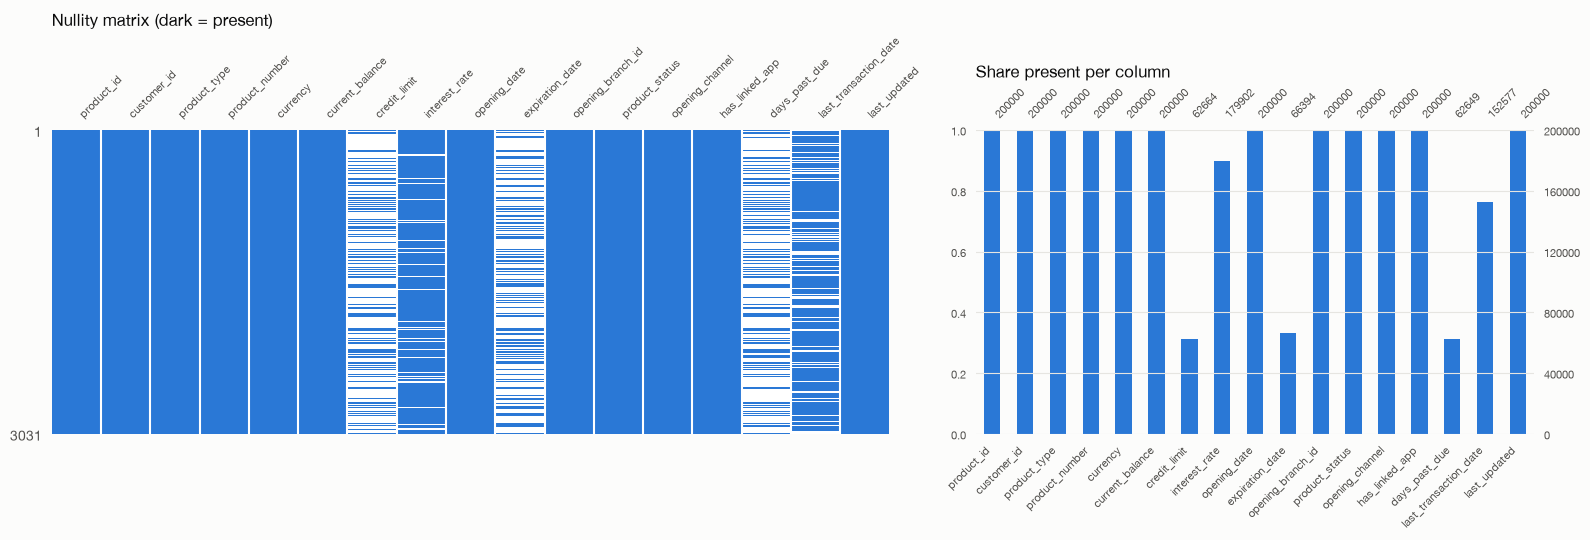

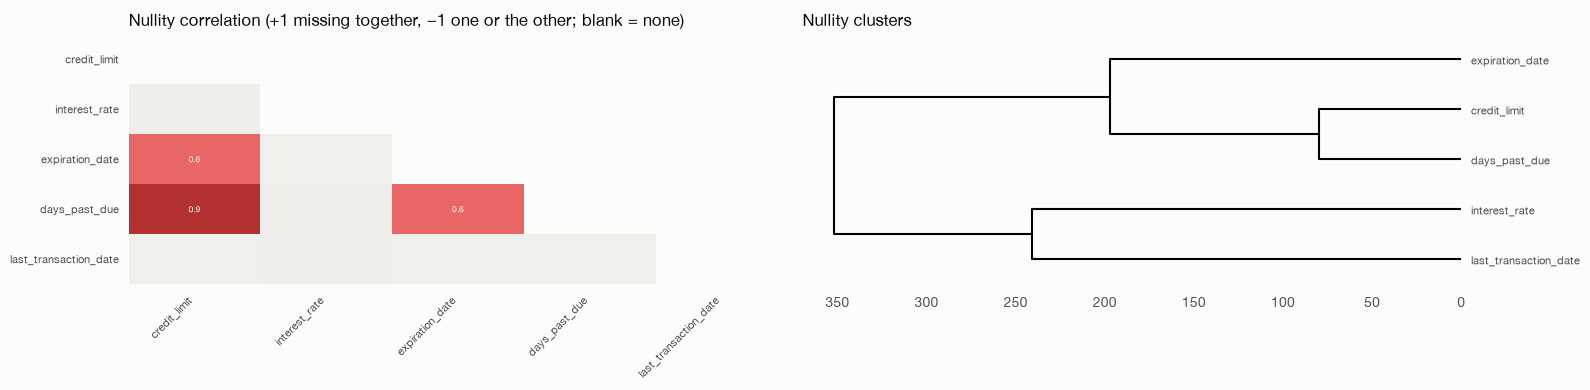

In [14]:
show_missing(t)

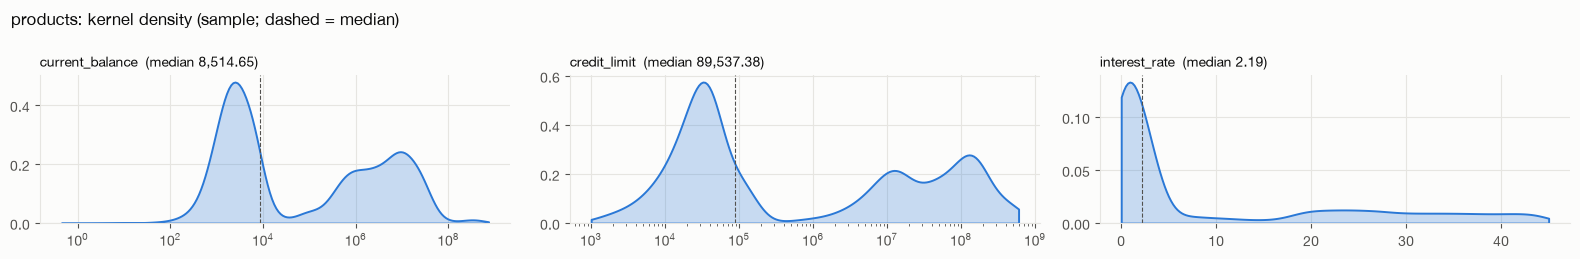

In [15]:
show_distributions(t)
show_categories(t)

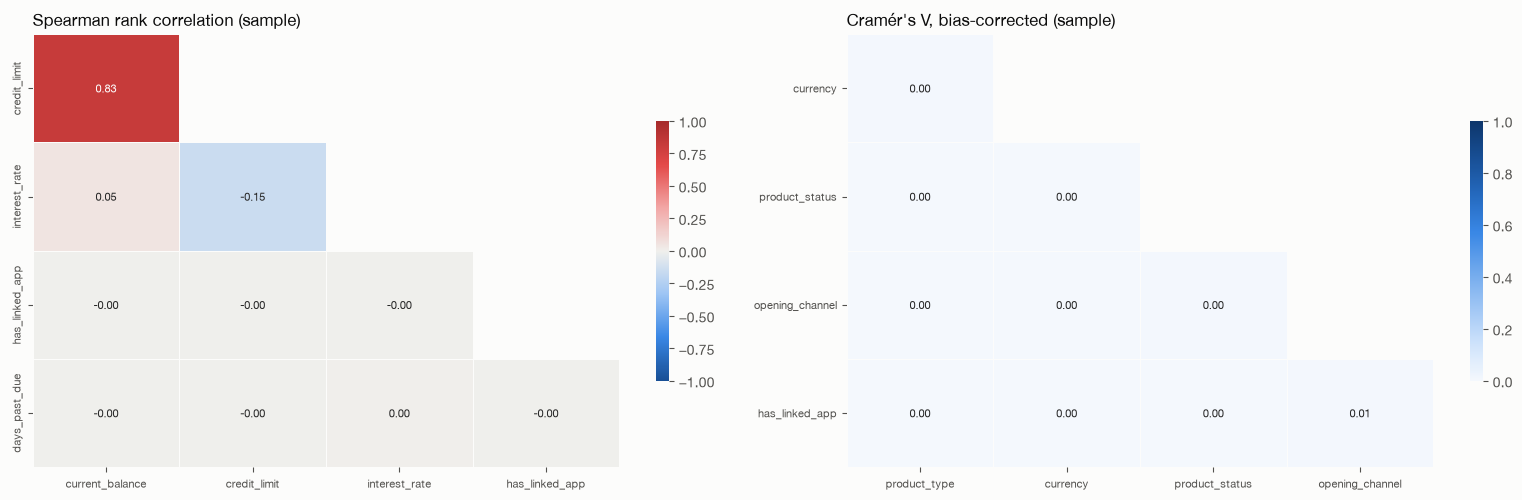

In [16]:
show_associations(t)

**Portfolio views.** Balances and limits by product type, card utilisation, and the DPD ladder used in
collections (0 · 1–30 · 31–60 · 61–90 · 90+ days). DPD exists only for credit products (credit cards and loans);
for accounts, investments and insurance it is null by design and shows as "no data".

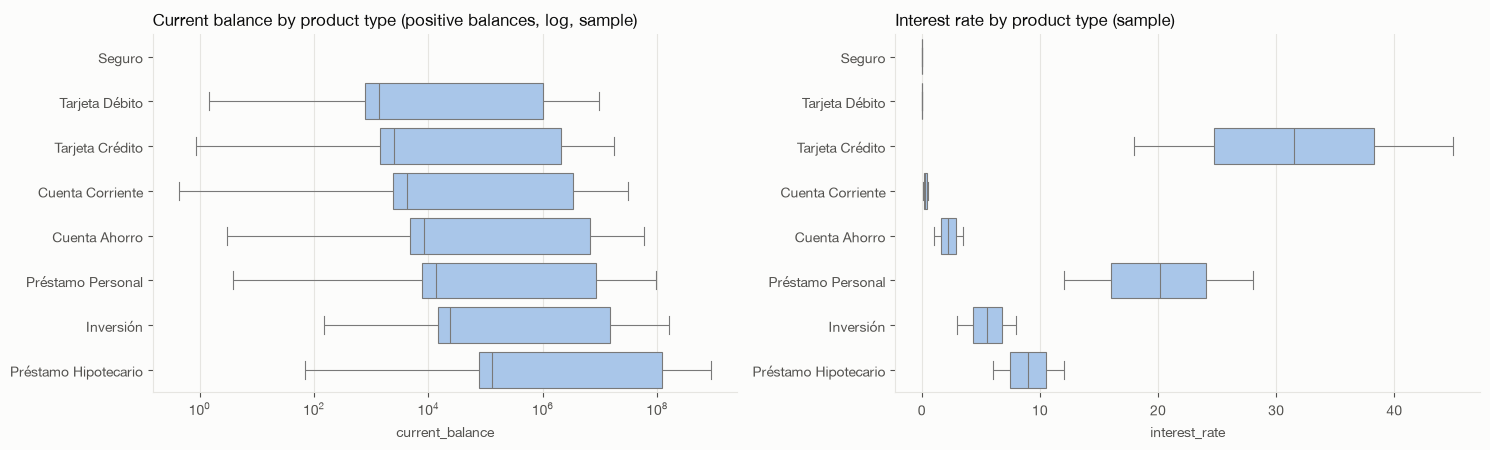

Utilisation (balance ÷ limit) is defined for 125,317 products with a credit limit; 6.0% are over their limit.

In [17]:
s = smp(t)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
order = s.groupby("product_type")["current_balance"].median().sort_values().index
sns.boxplot(
    data=s[s["current_balance"] > 0],
    x="current_balance",
    y="product_type",
    order=order,
    ax=axes[0],
    color=theme.SEQ_BLUE[1],
    log_scale=True,
    fliersize=1,
    linewidth=0.8,
)
axes[0].set_title("Current balance by product type (positive balances, log, sample)")
sns.boxplot(
    data=s,
    x="interest_rate",
    y="product_type",
    order=order,
    ax=axes[1],
    color=theme.SEQ_BLUE[1],
    fliersize=1,
    linewidth=0.8,
)
axes[1].set_title("Interest rate by product type (sample)")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

dpd = con.sql(
    """select product_type,
              case when days_past_due is null then 'no data' when days_past_due = 0 then '0 current'
                   when days_past_due <= 30 then '1–30' when days_past_due <= 60 then '31–60'
                   when days_past_due <= 90 then '61–90' else '90+' end as bucket,
              count(*) n
       from m_products group by 1, 2"""
).df()
dpd["pct"] = 100 * dpd["n"] / dpd.groupby("product_type")["n"].transform("sum")
fig = px.bar(
    dpd,
    y="product_type",
    x="pct",
    color="bucket",
    orientation="h",
    category_orders={"bucket": ["0 current", "1–30", "31–60", "61–90", "90+", "no data"]},
    color_discrete_map={
        "0 current": theme.STATUS["good"],
        "1–30": theme.STATUS["warning"],
        "31–60": theme.STATUS["serious"],
        "61–90": theme.STATUS["critical"],
        "90+": "#8a1f1f",
        "no data": theme.GRID,
    },
    custom_data=["n"],
)
fig.update_traces(
    hovertemplate="%{y} · %{fullData.name}: %{x:.1f}% (%{customdata[0]:,})<extra></extra>"
)
fig.update_layout(
    title="Days-past-due ladder by product type (% of products, exact)",
    height=380,
    xaxis_title="% of products",
    yaxis_title="",
    legend_title_text="DPD",
)
fig.show()

util = con.sql(
    """select current_balance / credit_limit as utilisation from m_products
       where credit_limit > 0 and current_balance is not null"""
).df()
h(
    f"Utilisation (balance ÷ limit) is defined for {len(util):,} products with a credit limit; "
    f"{(util['utilisation'] > 1).mean():.1%} are over their limit."
)
# bin before plotting so the figure carries 60 bars, not every product
counts, edges = np.histogram(util["utilisation"].clip(upper=1.5), bins=60)
fig = px.bar(x=(edges[:-1] + edges[1:]) / 2, y=counts, color_discrete_sequence=[theme.BLUE])
fig.update_layout(bargap=0.02, xaxis_title="utilisation")
fig.add_vline(x=1, line_dash="dash", line_color=theme.RED, annotation_text="limit")
fig.update_layout(
    title="Credit utilisation (capped at 150%, exact)", height=300, yaxis_title="products"
)
fig.show()
heat(
    p.crosstab(con, rel(t), "product_status", "product_type", normalize="column"),
    "Product status within each product type (% of the type, exact)",
)
heat(
    p.crosstab(con, rel(t), "currency", "product_type", normalize="column"),
    "Currency of each product type (% of the type, exact)",
)

### 3.3 `transactions` (fact)
**Grain:** one row per monetary movement on a product. **Key:** `transaction_id`. **Partition:** `process_date`.
The largest financial fact: it feeds fraud, AML, spend analytics and balances. Two things deserve care:
`amount` is in the transaction `currency` (USD, COP, ARS mixed) while `amount_usd` is the converted value,
and `is_fraud` is a **rare** label, so rates come with confidence intervals.

In [18]:
t = "transactions"
show_overview(t)
show_describe(t)

**Shape** 4,425,008 rows × 22 columns · **est. pandas memory (full table)** 1,228 MB · **PK** `transaction_id` unique (0 duplicated, 0 null)

`info()` on the sample (200,000 rows):

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        200000 non-null  str           
 1   transaction_date      200000 non-null  datetime64[us]
 2   process_date          200000 non-null  datetime64[us]
 3   product_id            200000 non-null  str           
 4   customer_id           200000 non-null  str           
 5   transaction_type      200000 non-null  str           
 6   transaction_category  78334 non-null   str           
 7   amount                200000 non-null  float64       
 8   currency              200000 non-null  str           
 9   amount_usd            85410 non-null   float64       
 10  channel               200000 non-null  str           
 11  branch_id             62538 non-null   str           
 12  merchant_name         46464 non-null   str           
 13  merchant_c

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
transaction_id,VARCHAR,identifier,"4,425,008",0,0,0.0%,0.0%,"4,394,559",99.3%
transaction_date,TIMESTAMP,temporal,"4,425,008",0,0,0.0%,0.0%,"3,855,236",87.1%
process_date,DATE,temporal,"4,425,008",0,0,0.0%,0.0%,954,0.0%
product_id,VARCHAR,identifier,"4,425,008",0,0,0.0%,0.0%,"405,731",9.2%
customer_id,VARCHAR,identifier,"4,425,008",0,0,0.0%,0.0%,"167,822",3.8%
transaction_type,VARCHAR,categorical,"4,425,008",0,0,0.0%,0.0%,6,0.0%
transaction_category,VARCHAR,categorical,"1,731,488","2,693,520",0,60.9%,60.9%,6,0.0%
amount,DOUBLE,numeric,"4,425,008",0,0,0.0%,0.0%,"3,608,253",81.5%
currency,VARCHAR,categorical,"4,425,008",0,0,0.0%,0.0%,3,0.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
amount,"4,425,008.00","1,913,670.90","5,668,217.36",5.00,30.68,425.43,"5,398.23","868,640.73","32,729,366.87","39,999,828.48",4.24,19.10,0.0%,0.0%,13.7%
amount_usd,"1,887,552.00","1,675.07","2,333.76",5.00,22.26,242.06,466.69,"1,979.74","9,506.71","9,999.96",1.87,2.66,0.0%,0.0%,12.2%
fraud_score,"3,539,851.00",15.03,8.77,0.00,0.30,7.50,15.01,22.51,29.72,99.99,0.17,0.14,0.0%,0.0%,0.1%
latitude,"857,328.00",-5.48,14.68,-35.60,-35.50,-0.80,0.20,4.04,5.64,5.71,-1.43,0.17,0.0%,45.0%,19.9%
longitude,"857,293.00",-33.88,34.35,-75.07,-75.01,-73.41,-1.00,-0.00,0.96,1.00,-0.07,-1.91,0.0%,75.0%,0.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
transaction_id,200000,200000,TRX-OM9NDIWBPO13QC7SQVDY,1
transaction_date,200000,199773,2023-11-06 01:41:45,2
process_date,200000,1097,2024-09-04,283
product_id,200000,151143,PRD-L3LQKNM49NZP,7
customer_id,200000,95255,CLI-U0VX1ZSFVXDY,15
transaction_type,200000,6,Purchase,48958
transaction_category,78334,6,Food,19807
currency,200000,3,USD,110118
channel,200000,6,POS,70314
branch_id,62538,350,SUC-A1FLMPEF,216


**Missing data (nulls + placeholders), sample.** 10 of 22 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

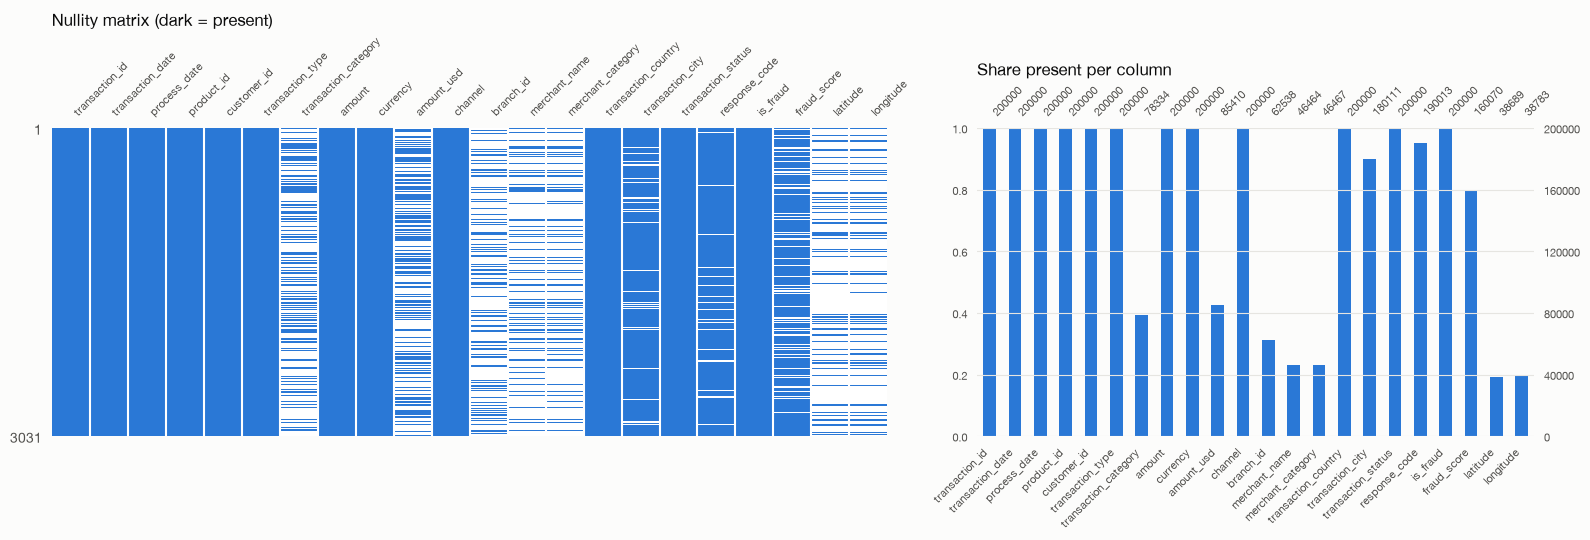

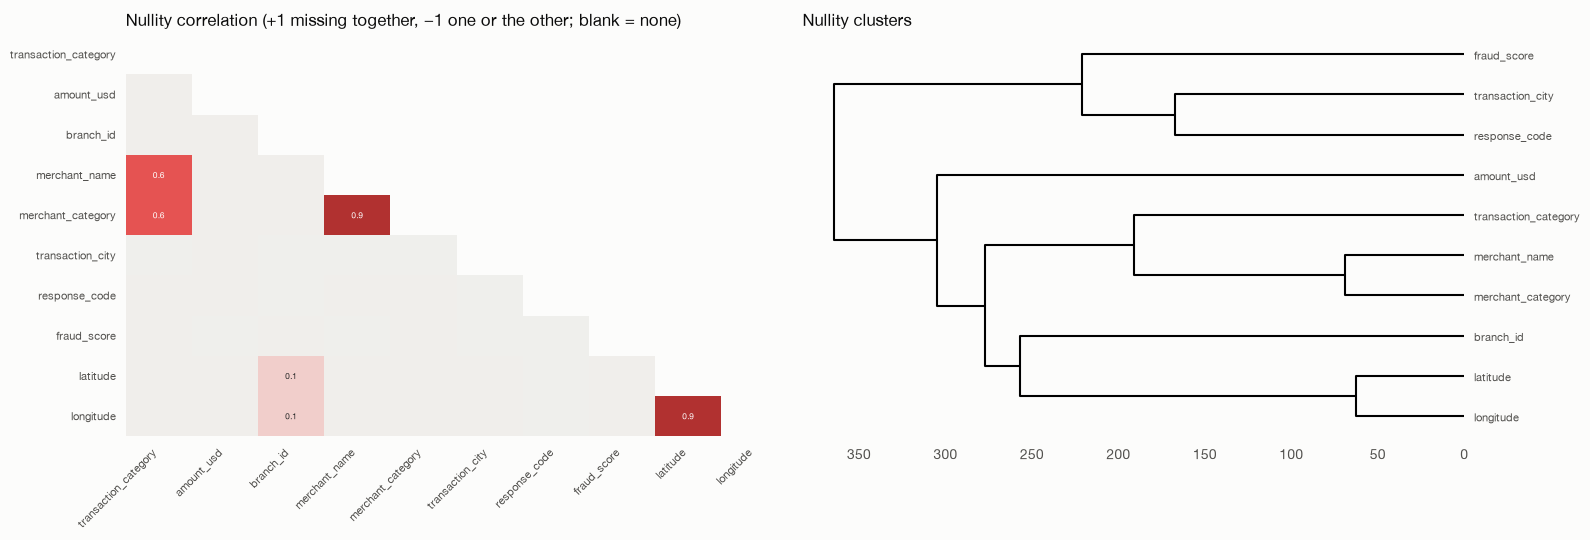

In [19]:
show_missing(t)

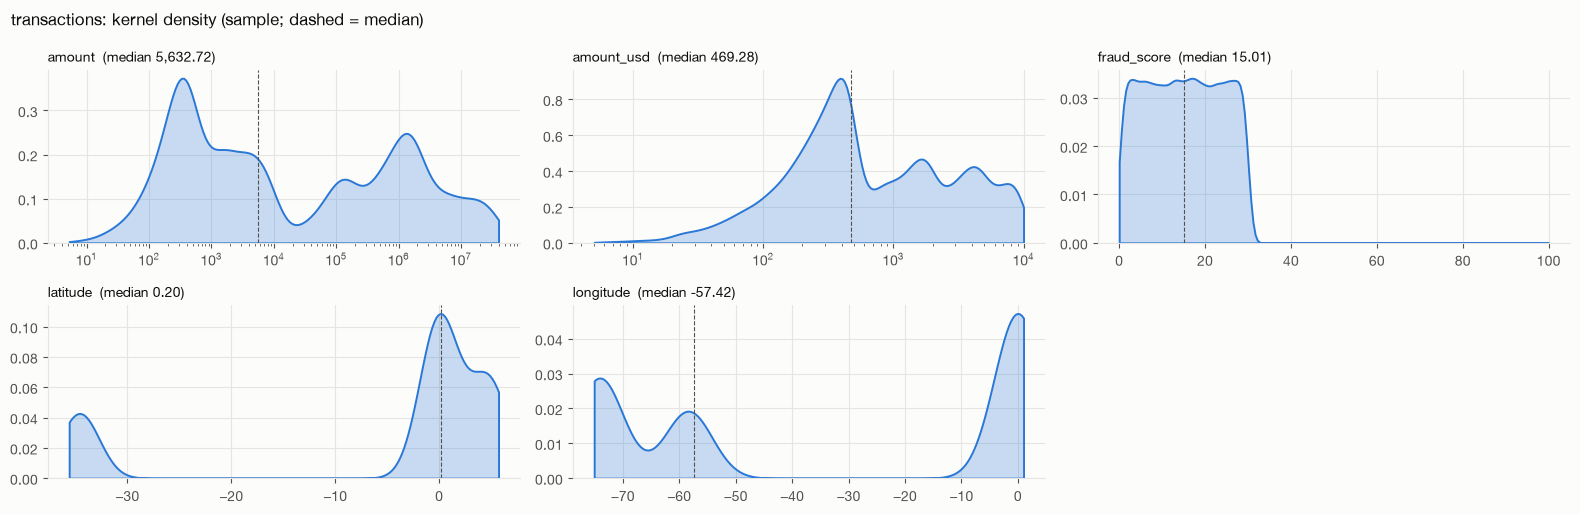

In [20]:
show_distributions(t)
show_categories(t)

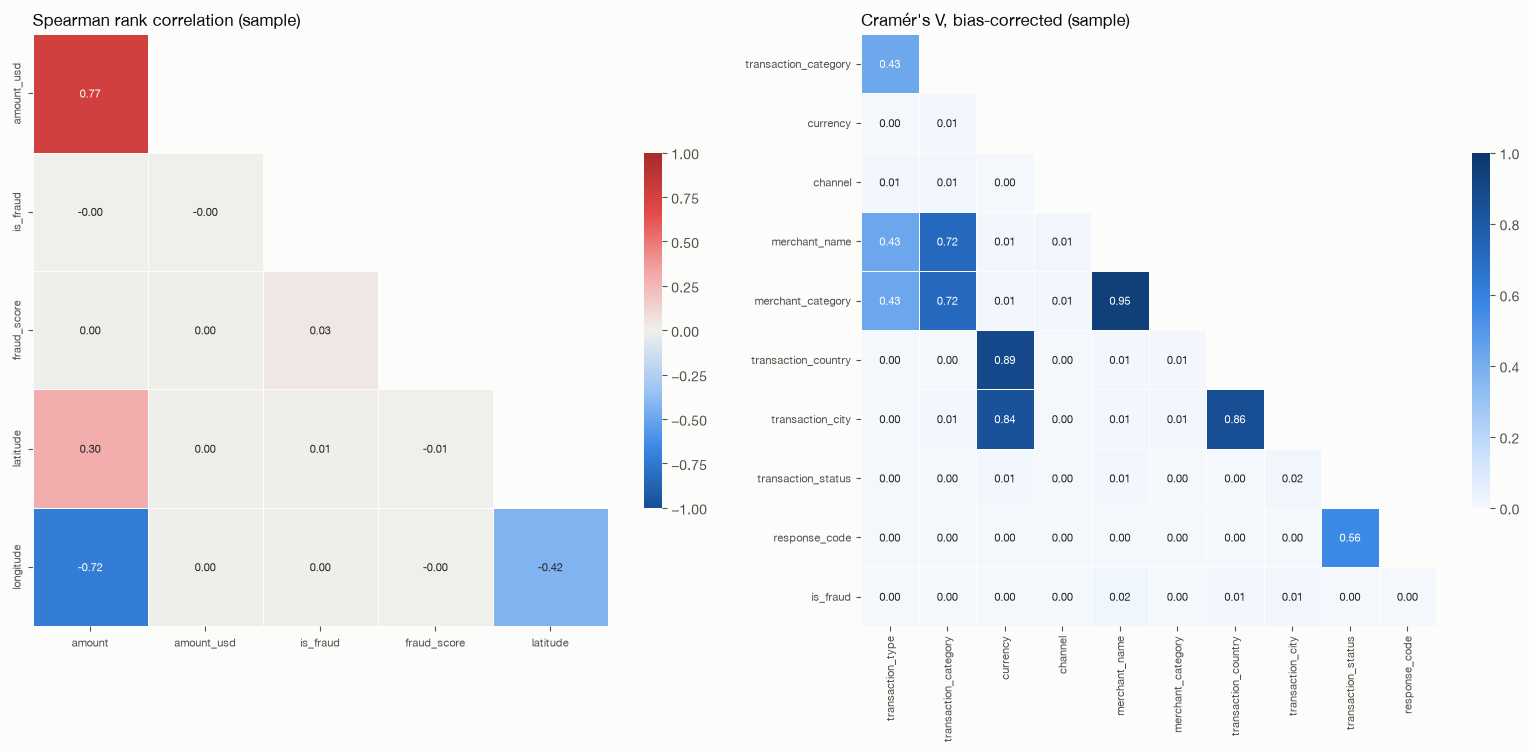

In [21]:
show_associations(t)
show_time(t)

**Currencies.** `amount` mixes three currencies, so its raw distribution is multi-modal and must never be
summed across currencies. The table shows where `amount_usd` is filled.

currency,n,usd_null_share,median_amount,median_amount_usd,implied_rate
USD,"2,437,979",100.0%,467.08,nan,nan
COP,"1,194,444",5.0%,"1,867,136.48",466.86,"4,000.00"
ARS,"792,585",5.1%,"163,284.79",466.39,350.00


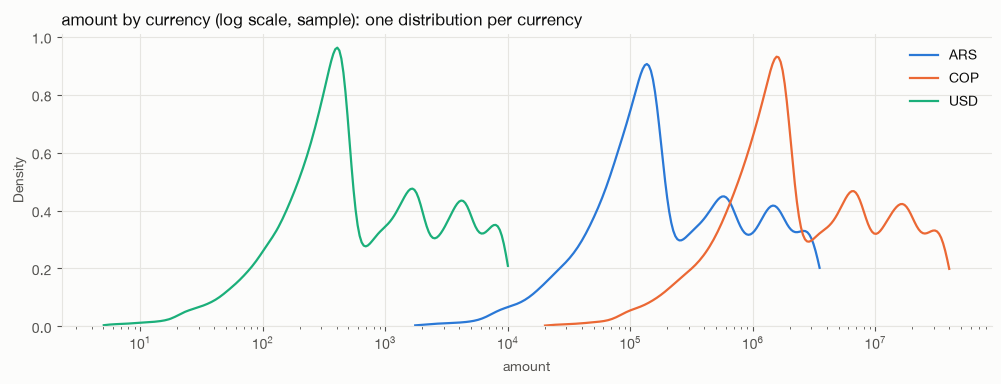

In [22]:
cur = con.sql(
    """select currency, count(*) n, avg((amount_usd is null)::int) usd_null_share,
              median(amount) median_amount, median(amount_usd) median_amount_usd,
              median(amount / nullif(amount_usd, 0)) implied_rate
       from m_transactions group by 1 order by n desc"""
).df()
display(
    cur.style.format(
        {
            "n": "{:,}",
            "usd_null_share": "{:.1%}",
            "median_amount": "{:,.2f}",
            "median_amount_usd": "{:,.2f}",
            "implied_rate": "{:,.2f}",
        }
    ).hide(axis="index")
)
s = smp(t)
fig, ax = plt.subplots(figsize=(12, 3.8))
for i, (c, g) in enumerate(s.groupby("currency")):
    sns.kdeplot(
        x=g["amount"],
        ax=ax,
        log_scale=True,
        label=c,
        color=theme.CATEGORICAL[i],
        linewidth=1.6,
        cut=0,
    )
ax.set_title("amount by currency (log scale, sample): one distribution per currency")
ax.legend()
plt.show()
heat(
    p.crosstab(con, rel(t), "transaction_country", "currency", normalize="row"),
    "Currency used per transaction country (% of the country's rows, exact)",
)

**Fraud.** Overall rate, then the rate by type, channel, country and merchant category with 95% Wilson
intervals. Wide intervals mean too few cases to conclude anything.

**4,316 fraudulent of 4,425,008 transactions = 0.098%** (95% CI 0.095%–0.100%); about 1 in 1,025. Any classifier must be judged on precision/recall, not accuracy.

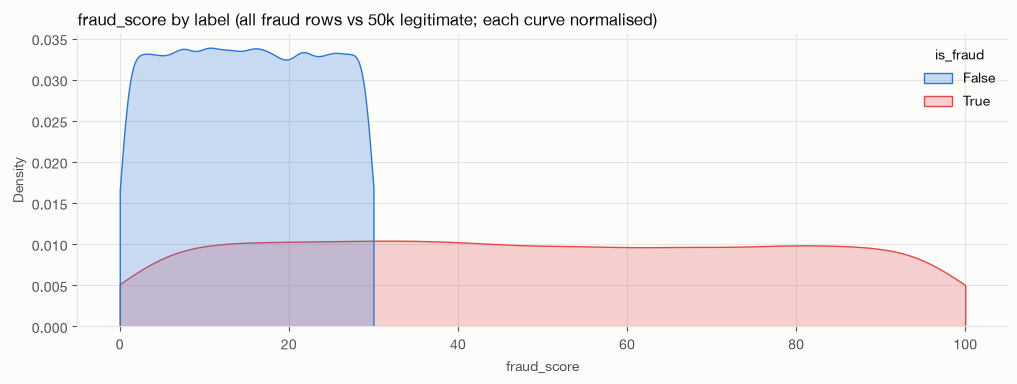

**Label leakage check:** the highest score of a legitimate transaction is **30.00**; `fraud_score > 30` flags 2,373 rows, 100% of them fraud (precision), and catches 55% of all fraud (recall).

In [23]:
k, n = con.sql("select sum(is_fraud::int), count(*) from m_transactions").fetchone()
lo, hi = wilson(k, n)
h(
    f"**{k:,} fraudulent of {n:,} transactions = {k / n:.3%}** (95% CI {lo:.3%}–{hi:.3%}); "
    f"about 1 in {n // max(k, 1):,}. Any classifier must be judged on precision/recall, not accuracy."
)
rate_bars(
    {
        f"by {c}": rate_by(t, c, "is_fraud", min_n=500)
        for c in ["transaction_type", "channel", "transaction_country", "merchant_category"]
    },
    "Fraud rate (%, exact, 95% Wilson CI)",
)
fr = con.sql(
    """(select fraud_score, is_fraud from m_transactions where is_fraud and fraud_score is not null)
       union all
       (select fraud_score, is_fraud from m_transactions where not is_fraud and fraud_score is not null
        order by hash(transaction_id, 42) limit 50000)"""
).df()
fig, ax = plt.subplots(figsize=(12, 3.8))
sns.kdeplot(
    data=fr,
    x="fraud_score",
    hue="is_fraud",
    common_norm=False,
    fill=True,
    alpha=0.25,
    cut=0,
    palette={False: theme.BLUE, True: theme.RED},
    ax=ax,
)
ax.set_title("fraud_score by label (all fraud rows vs 50k legitimate; each curve normalised)")
plt.show()
leak = con.sql(
    """select max(fraud_score) filter (where not is_fraud) as legit_max,
              count(*) filter (where fraud_score > 30 and is_fraud) as tp,
              count(*) filter (where fraud_score > 30) as flagged,
              count(*) filter (where is_fraud) as frauds
       from m_transactions"""
).fetchone()
h(
    f"**Label leakage check:** the highest score of a legitimate transaction is **{leak[0]:.2f}**; "
    f"`fraud_score > 30` flags {leak[2]:,} rows, {leak[1] / leak[2]:.0%} of them fraud (precision), "
    f"and catches {leak[1] / leak[3]:.0%} of all fraud (recall)."
)
heat(
    p.crosstab(con, rel(t), "channel", "transaction_status", normalize="row"),
    "Transaction status by channel (% of the channel's rows, exact)",
)

**Geography.** Coordinates are filled for a minority of rows; plotting them shows whether they are
plausible for the stated country.

In [24]:
geo = con.sql(
    """select latitude, longitude, transaction_country from m_transactions
       where latitude is not null order by hash(transaction_id, 7) limit 8000"""
).df()
fig = px.scatter(
    geo,
    x="longitude",
    y="latitude",
    color="transaction_country",
    opacity=0.5,
    color_discrete_sequence=theme.CATEGORICAL,
    render_mode="svg",
)
fig.update_traces(marker_size=4)
fig.update_layout(title="Transaction coordinates (8k rows with coordinates)", height=480)
fig.show()
nk, nn = con.sql(
    """select count(*) filter (where abs(latitude) <= 1.5 and abs(longitude) <= 1.5), count(latitude)
       from m_transactions"""
).fetchone()
h(
    f"**{nk:,} of {nn:,} rows with coordinates ({nk / nn:.1%}) sit within 1.5° of (0, 0)**, the "
    "'null island' in the Gulf of Guinea, nowhere near the stated countries: placeholder coordinates "
    "with jitter, to be treated as missing downstream."
)

**407,656 of 857,328 rows with coordinates (47.5%) sit within 1.5° of (0, 0)**, the 'null island' in the Gulf of Guinea, nowhere near the stated countries: placeholder coordinates with jitter, to be treated as missing downstream.

### 3.4 `daily_exchange_rates` (reference)
**Grain:** one row per date × currency pair. No surrogate key: `(date, source_currency, target_currency)`
should be unique. These rates are what silver should use to rebuild `amount_usd`.

In [25]:
t = "daily_exchange_rates"
show_overview(t)
show_describe(t)
dup = con.sql("""select count(*) - count(distinct (date, source_currency, target_currency))
                 from m_daily_exchange_rates""").fetchone()[0]
h(f"Duplicated `(date, source_currency, target_currency)` rows: **{dup:,}**")

**Shape** 13,164 rows × 7 columns · **est. pandas memory (full table)** 1 MB · no single-column primary key

`info()` on the sample (13,164 rows):

<class 'pandas.DataFrame'>
RangeIndex: 13164 entries, 0 to 13163
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             13164 non-null  datetime64[us]
 1   source_currency  13164 non-null  str           
 2   target_currency  13164 non-null  str           
 3   exchange_rate    13164 non-null  float64       
 4   buy_rate         13164 non-null  float64       
 5   sell_rate        13164 non-null  float64       
 6   source           13164 non-null  str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 912.8 KB


,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
date,DATE,temporal,"13,164",0,0,0.0%,0.0%,954,7.2%
source_currency,VARCHAR,categorical,"13,164",0,0,0.0%,0.0%,4,0.0%
target_currency,VARCHAR,categorical,"13,164",0,0,0.0%,0.0%,4,0.0%
exchange_rate,DOUBLE,numeric,"13,164",0,0,0.0%,0.0%,"8,255",62.7%
buy_rate,DOUBLE,numeric,"13,164",0,0,0.0%,0.0%,"8,889",67.5%
sell_rate,DOUBLE,numeric,"13,164",0,0,0.0%,0.0%,"8,945",68.0%
source,VARCHAR,categorical,"13,164",0,0,0.0%,0.0%,4,0.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
exchange_rate,"13,164.00",385.94,"1,094.24",0.00,0.00,0.04,5.65,73.40,"4,059.88","4,079.94",2.96,6.91,0.0%,0.0%,25.0%
buy_rate,"13,164.00",382.04,"1,083.21",0.00,0.00,0.04,5.57,72.48,"4,018.24","4,057.98",2.96,6.91,0.0%,0.0%,25.0%
sell_rate,"13,164.00",389.83,"1,105.29",0.00,0.00,0.04,5.67,73.92,"4,100.73","4,138.59",2.96,6.91,0.0%,0.0%,25.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
date,13164,1097,2023-06-17,12
source_currency,13164,4,MXN,3291
target_currency,13164,4,USD,3291
source,13164,4,Bloomberg,3303


Duplicated `(date, source_currency, target_currency)` rows: **0**

No nulls or placeholders in this table.

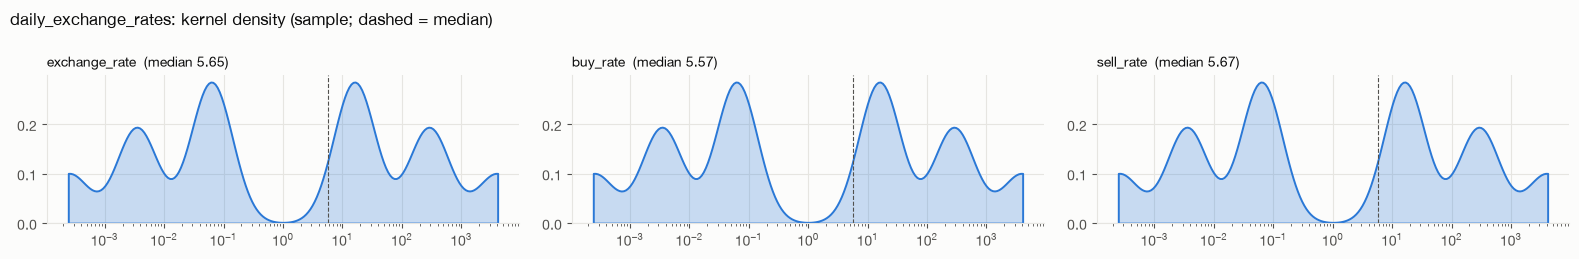

In [26]:
show_missing(t)
show_distributions(t)
show_categories(t)
show_time(t)

In [27]:
fx = con.sql("""select date, source_currency || '→' || target_currency pair, exchange_rate, buy_rate, sell_rate
                from m_daily_exchange_rates order by date""").df()
fx["index_100"] = 100 * fx["exchange_rate"] / fx.groupby("pair")["exchange_rate"].transform("first")
fx[["source", "target"]] = fx["pair"].str.split("→", expand=True)
# weekly means keep the shape and send 7x fewer points to the browser
weekly = (
    fx.assign(week=pd.to_datetime(fx["date"]).dt.to_period("W").dt.start_time)
    .groupby(["source", "target", "week"], as_index=False)["index_100"]
    .mean()
)
fig = px.line(
    weekly,
    x="week",
    y="index_100",
    color="target",
    facet_col="source",
    color_discrete_sequence=theme.CATEGORICAL,
    labels={"week": "", "index_100": "index", "target": "to", "source": "from"},
    render_mode="svg",  # WebGL does not render everywhere (headless browsers, some exports)
)
fig.update_layout(
    title="Exchange rate per pair, indexed to 100 at the first date (weekly mean, exact)",
    height=360,
    hovermode="x unified",
)
fig.show()
fx["spread_bp"] = 1e4 * (fx["sell_rate"] - fx["buy_rate"]) / fx["exchange_rate"]
q = fx.groupby("pair")["spread_bp"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()
fig = go.Figure(
    go.Box(
        y=q.index,
        q1=q[0.25],
        median=q[0.5],
        q3=q[0.75],
        lowerfence=q[0.05],
        upperfence=q[0.95],
        orientation="h",
        marker_color=theme.BLUE,
        fillcolor=theme.SEQ_BLUE[0],
    )
)
fig.update_layout(
    title="Buy/sell spread per pair (bp of the mid rate; box = quartiles, whiskers = 5th–95th pct)",
    height=420,
    yaxis_title="",
)
fig.show()

## 4 · Network and people
### 4.1 `branches` (dimension)
**Grain:** one row per branch. **Key:** `branch_id`. Small and descriptive: location, format, ATMs, hours.

**Shape** 350 rows × 22 columns · **est. pandas memory (full table)** 0 MB · **PK** `branch_id` unique (0 duplicated, 0 null)

`info()` on the sample (350 rows):

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   branch_id            350 non-null    str           
 1   branch_code          350 non-null    str           
 2   branch_name          350 non-null    str           
 3   branch_type          350 non-null    str           
 4   address              350 non-null    str           
 5   city                 350 non-null    str           
 6   state                350 non-null    str           
 7   country              350 non-null    str           
 8   postal_code          350 non-null    str           
 9   geographic_zone      350 non-null    str           
 10  phone                350 non-null    str           
 11  email                350 non-null    str           
 12  opening_time         350 non-null    object        
 13  closing_time         350 non-null    object   

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
branch_id,VARCHAR,identifier,350,0,0,0.0%,0.0%,350,100.0%
branch_code,VARCHAR,identifier,350,0,0,0.0%,0.0%,342,97.7%
branch_name,VARCHAR,categorical,350,0,0,0.0%,0.0%,171,48.9%
branch_type,VARCHAR,categorical,350,0,0,0.0%,0.0%,4,1.1%
address,VARCHAR,pii,350,0,0,0.0%,0.0%,318,90.9%
city,VARCHAR,categorical,350,0,0,0.0%,0.0%,16,4.6%
state,VARCHAR,categorical,350,0,0,0.0%,0.0%,18,5.1%
country,VARCHAR,categorical,350,0,0,0.0%,0.0%,3,0.9%
postal_code,VARCHAR,categorical,350,0,0,0.0%,0.0%,107,30.6%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
atm_count,350.00,5.07,2.00,2.00,2.00,3.00,5.00,7.00,8.00,8.00,-0.02,-1.27,0.0%,0.0%,0.0%
teller_window_count,350.00,7.84,2.86,3.00,3.00,6.00,8.00,10.00,12.00,12.00,-0.11,-1.16,0.0%,0.0%,0.0%
latitude,350.00,2.66,15.29,-34.69,-34.61,-0.04,0.05,6.33,25.77,25.78,-0.83,0.86,0.0%,36.0%,35.7%
longitude,350.00,-44.30,43.99,-103.45,-103.42,-76.63,-58.40,-0.01,0.09,0.10,-0.11,-1.78,0.0%,76.3%,0.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
branch_id,350,350,SUC-98QOW3F1,1
branch_code,350,350,S0001,1
branch_name,350,175,Banco LATAM Ciudad de México Plaza,11
branch_type,350,4,Express,130
city,350,16,Puebla,33
state,350,16,Puebla,33
country,350,3,México,175
postal_code,350,105,72000,33
geographic_zone,350,1,Urbana,350
opening_time,350,4,09:30:00,104


No nulls or placeholders in this table.

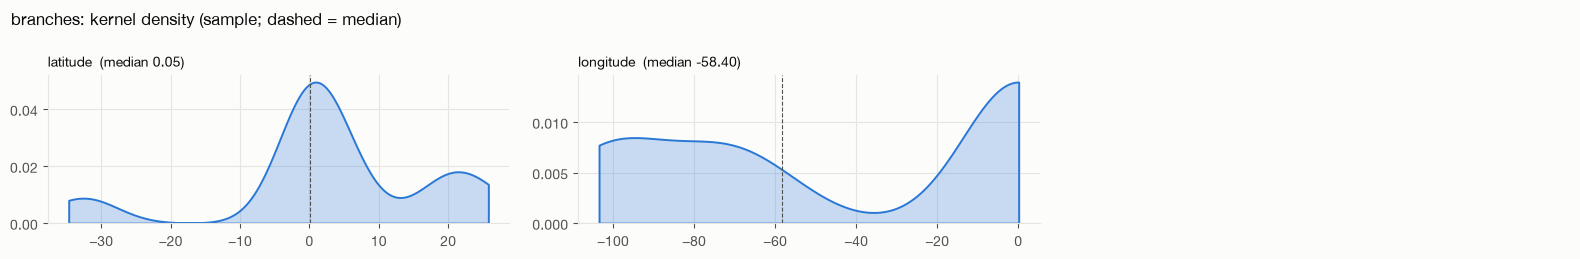

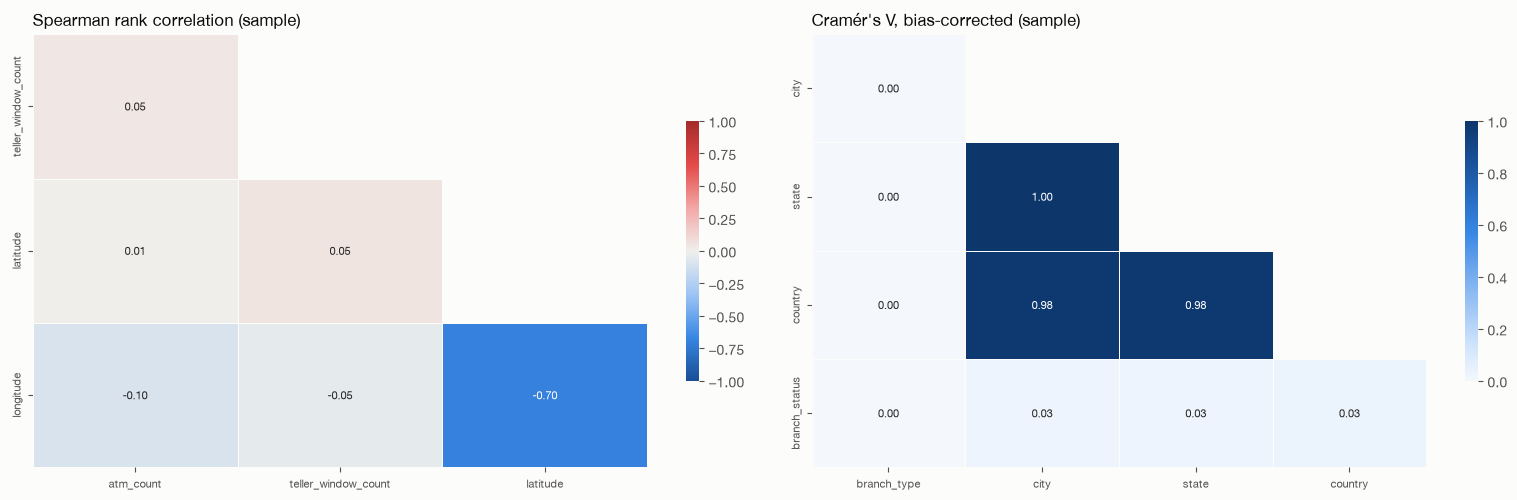

In [28]:
t = "branches"
core(t)

In [29]:
b = con.sql("select * from m_branches").df()
fig = px.scatter(
    b,
    x="longitude",
    y="latitude",
    color="branch_type",
    size="atm_count",
    size_max=14,
    hover_name="branch_name",
    hover_data=["city", "country", "branch_status"],
    color_discrete_sequence=theme.CATEGORICAL,
)
fig.update_layout(title="Branch locations (size = ATMs)", height=480)
fig.show()
heat(
    p.crosstab(con, rel(t), "branch_type", "country"),
    "Branches by type and country (count)",
    fmt="d",
)

### 4.2 `service_agents` (dimension)
**Grain:** one row per agent. **Key:** `agent_id`. Experience, specialty, languages and accent drive the
routing questions of the AI customer-service system.

**Shape** 1,200 rows × 18 columns · **est. pandas memory (full table)** 0 MB · **PK** `agent_id` unique (0 duplicated, 0 null)

`info()` on the sample (1,200 rows):

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   agent_id                    1200 non-null   str           
 1   employee_code               1200 non-null   str           
 2   first_name                  1200 non-null   str           
 3   last_name                   1200 non-null   str           
 4   email                       1200 non-null   str           
 5   phone                       1131 non-null   str           
 6   native_accent               1200 non-null   str           
 7   country_of_origin           1200 non-null   str           
 8   assigned_branch_id          833 non-null    str           
 9   agent_type                  1200 non-null   str           
 10  experience_level            1200 non-null   str           
 11  languages                   1200 non-null   str           
 12  spe

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
agent_id,VARCHAR,identifier,"1,200",0,0,0.0%,0.0%,"1,094",91.2%
employee_code,VARCHAR,identifier,"1,200",0,0,0.0%,0.0%,"1,200",100.0%
first_name,VARCHAR,pii,"1,200",0,0,0.0%,0.0%,401,33.4%
last_name,VARCHAR,pii,"1,200",0,0,0.0%,0.0%,"1,107",92.2%
email,VARCHAR,pii,"1,200",0,0,0.0%,0.0%,"1,200",100.0%
phone,VARCHAR,pii,"1,131",69,0,5.8%,5.8%,"1,131",100.0%
native_accent,VARCHAR,categorical,"1,200",0,0,0.0%,0.0%,3,0.2%
country_of_origin,VARCHAR,categorical,"1,200",0,0,0.0%,0.0%,3,0.2%
assigned_branch_id,VARCHAR,identifier,833,367,0,30.6%,30.6%,765,91.8%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
avg_csat,"1,066.00",4.27,0.43,3.50,3.52,3.91,4.27,4.62,4.99,5.00,-0.03,-1.16,0.0%,0.0%,0.0%
total_monthly_interactions,"1,089.00",453.03,202.31,100.00,104.88,280.00,452.00,632.00,795.00,800.00,-0.01,-1.19,0.0%,0.0%,0.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
agent_id,1200,1200,AGT-FGAVR5FA7R,1
employee_code,1200,1187,E53456,2
native_accent,1200,3,mexican,600
country_of_origin,1200,3,Mexico,600
assigned_branch_id,833,833,SUC-L138LKPP,1
agent_type,1200,4,Phone,588
experience_level,1200,4,Specialist,761
languages,1200,4,español,649
specialty,724,8,Fraudes,105
hire_date,1200,1055,2015-12-14,3


**Missing data (nulls + placeholders), sample.** 5 of 18 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

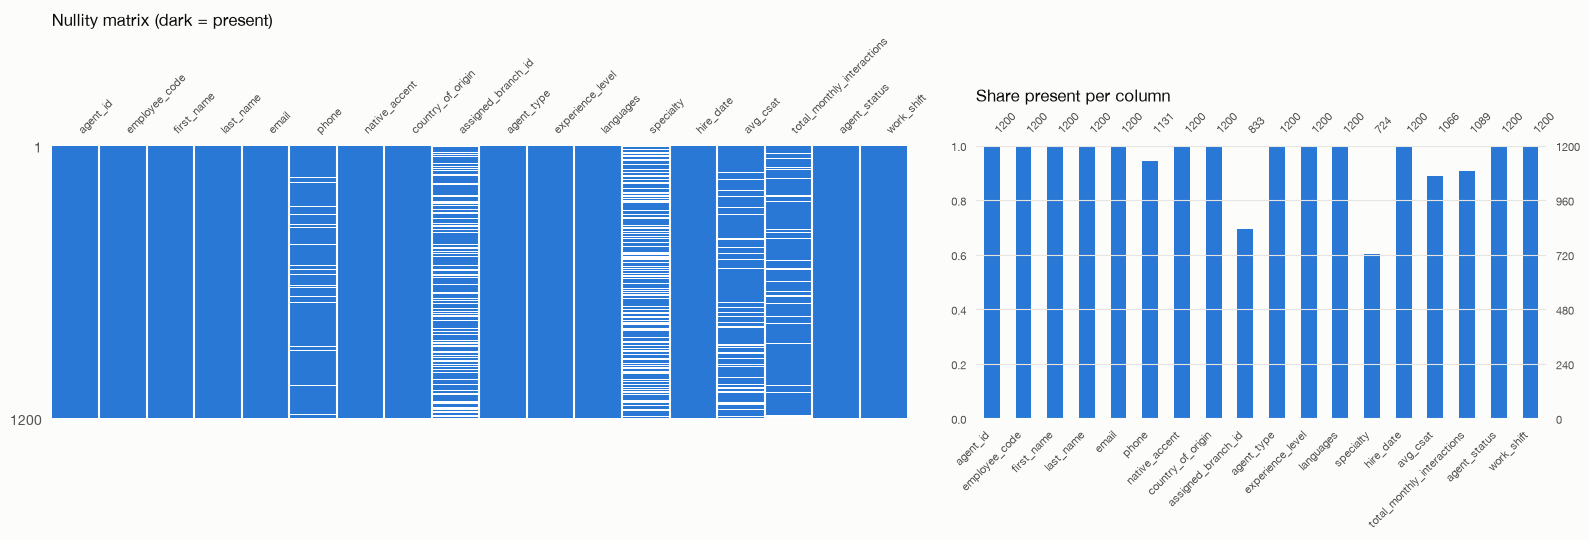

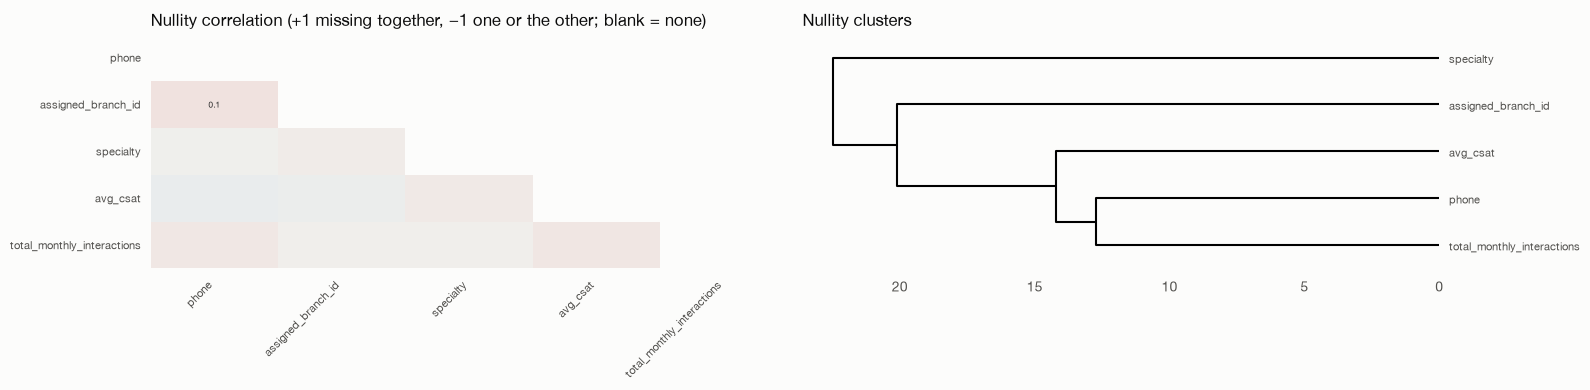

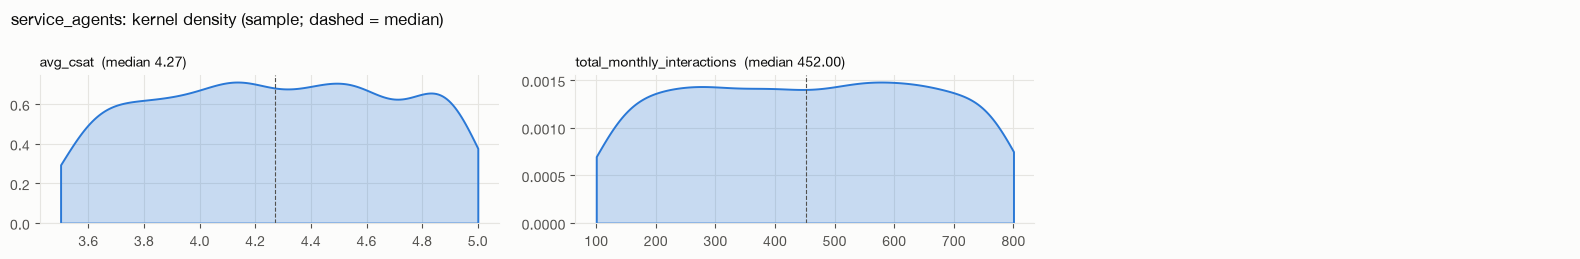

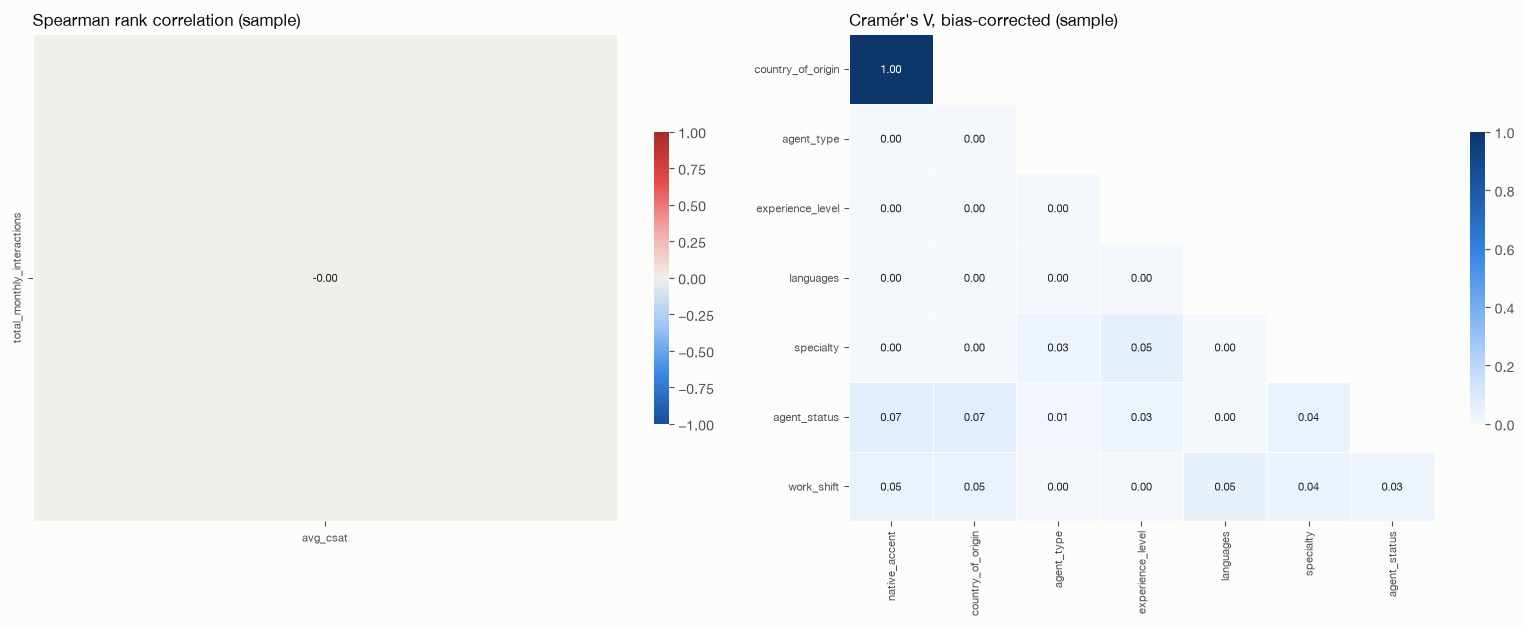

In [30]:
t = "service_agents"
core(t)

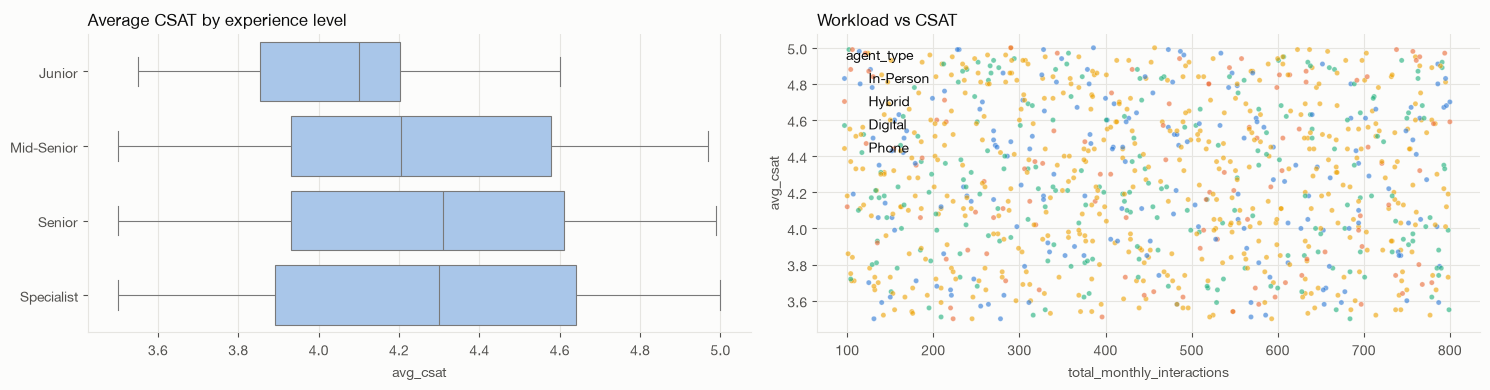

In [31]:
s = smp(t)
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
order = ["Junior", "Mid-Senior", "Senior", "Specialist"]
order = [o for o in order if o in set(s["experience_level"])] or None
sns.boxplot(
    data=s,
    x="avg_csat",
    y="experience_level",
    order=order,
    ax=axes[0],
    color=theme.SEQ_BLUE[1],
    fliersize=2,
    linewidth=0.8,
)
axes[0].set_title("Average CSAT by experience level")
sns.scatterplot(
    data=s,
    x="total_monthly_interactions",
    y="avg_csat",
    hue="agent_type",
    ax=axes[1],
    s=14,
    alpha=0.6,
    palette=theme.CATEGORICAL[: s["agent_type"].nunique()],
)
axes[1].set_title("Workload vs CSAT")
for ax in axes:
    ax.set_ylabel(ax.get_ylabel() if ax is axes[1] else "")
plt.tight_layout()
plt.show()
heat(
    p.crosstab(con, rel(t), "specialty", "agent_type"),
    "Agents by specialty and type (count)",
    fmt="d",
)

## 5 · Customer service
### 5.1 `call_center_interactions` (fact)
**Grain:** one row per contact (phone, chat, e-mail...). **Key:** `interaction_id`. Wait time, handle time,
resolution, escalation and sentiment: the operational KPIs the AI agents are meant to improve.

In [32]:
t = "call_center_interactions"
show_overview(t)
show_describe(t)

**Shape** 686,296 rows × 21 columns · **est. pandas memory (full table)** 172 MB · **PK** `interaction_id` unique (0 duplicated, 0 null)

`info()` on the sample (200,000 rows):

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   interaction_id            200000 non-null  str           
 1   interaction_date          200000 non-null  datetime64[us]
 2   process_date              200000 non-null  datetime64[us]
 3   customer_id               200000 non-null  str           
 4   agent_id                  200000 non-null  str           
 5   interaction_type          200000 non-null  str           
 6   channel                   200000 non-null  str           
 7   contact_reason            200000 non-null  str           
 8   reason_category           200000 non-null  str           
 9   duration_seconds          172158 non-null  float64       
 10  wait_time_seconds         140247 non-null  float64       
 11  was_resolved              200000 non-null  bool          
 12  requires_foll

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
interaction_id,VARCHAR,identifier,"686,296",0,0,0.0%,0.0%,"686,296",100.0%
interaction_date,TIMESTAMP,temporal,"686,296",0,0,0.0%,0.0%,"686,296",100.0%
process_date,DATE,temporal,"686,296",0,0,0.0%,0.0%,954,0.1%
customer_id,VARCHAR,identifier,"686,296",0,0,0.0%,0.0%,"164,963",24.0%
agent_id,VARCHAR,identifier,"686,296",0,0,0.0%,0.0%,"1,052",0.2%
interaction_type,VARCHAR,categorical,"686,296",0,0,0.0%,0.0%,5,0.0%
channel,VARCHAR,categorical,"686,296",0,0,0.0%,0.0%,6,0.0%
contact_reason,VARCHAR,categorical,"686,296",0,0,0.0%,0.0%,6,0.0%
reason_category,VARCHAR,categorical,"686,296",0,0,0.0%,0.0%,6,0.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
duration_seconds,"590,062.00",321.45,153.97,30.00,74.00,205.00,291.00,415.00,762.00,"1,204.00",0.85,0.55,0.0%,0.0%,1.5%
wait_time_seconds,"480,678.00",119.94,58.66,0.00,0.00,79.00,119.00,160.00,259.00,424.00,0.13,-0.24,2.4%,0.0%,0.3%
sentiment_score,"686,296.00",-0.04,0.38,-1.00,-0.94,-0.25,-0.02,0.20,0.89,1.00,-0.09,0.15,1.1%,52.2%,2.5%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
interaction_id,200000,200000,INT-6DAY2DJ3BTOWJQ0C,1
interaction_date,200000,199759,2024-11-12 05:02:32,3
process_date,200000,1097,2024-05-10,277
customer_id,200000,110483,CLI-JWLC7ODDOYKG,8
agent_id,200000,1090,AGT-DBGB5MKK8K,221
interaction_type,200000,5,Inbound Call,140247
channel,200000,6,Phone,170169
contact_reason,200000,6,Transaccional,70160
reason_category,200000,6,Transaccional,70160
was_resolved,200000,2,True,153385


**Missing data (nulls + placeholders), sample.** 5 of 21 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

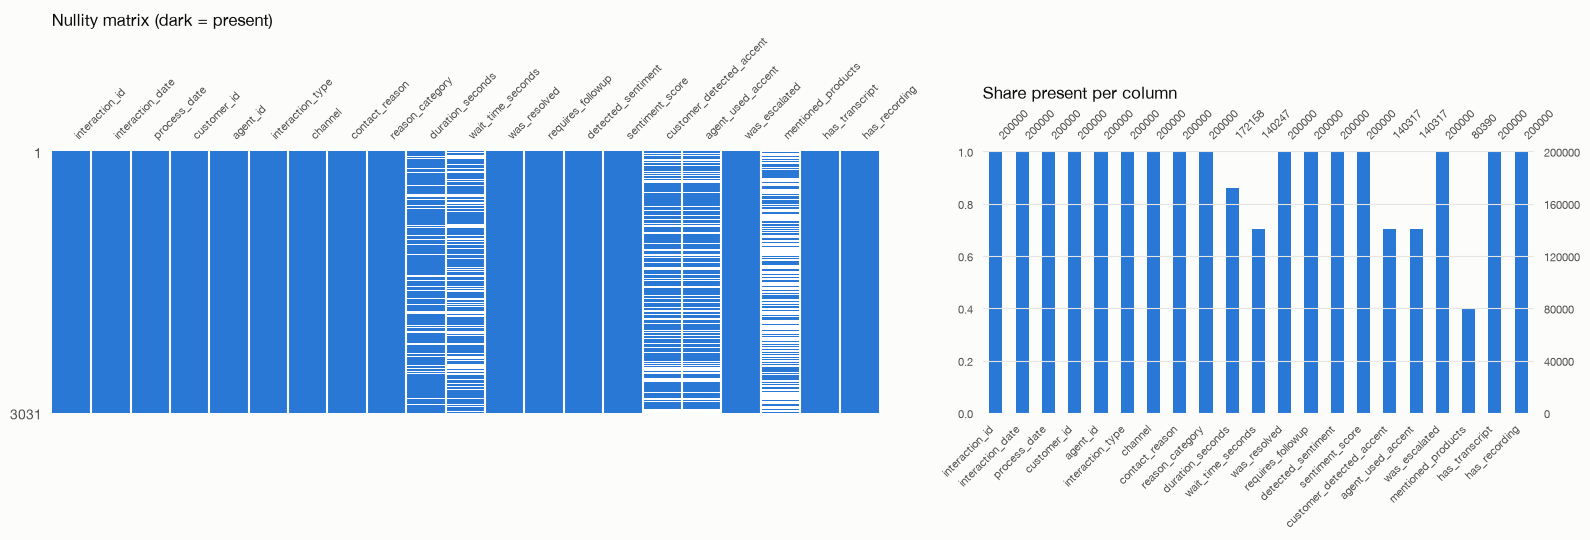

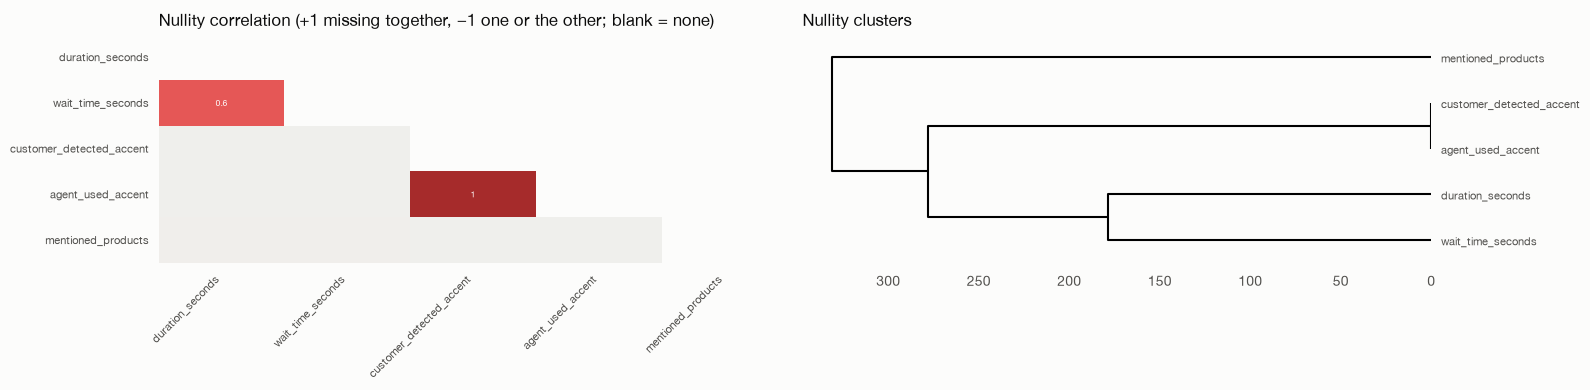

In [33]:
show_missing(t)

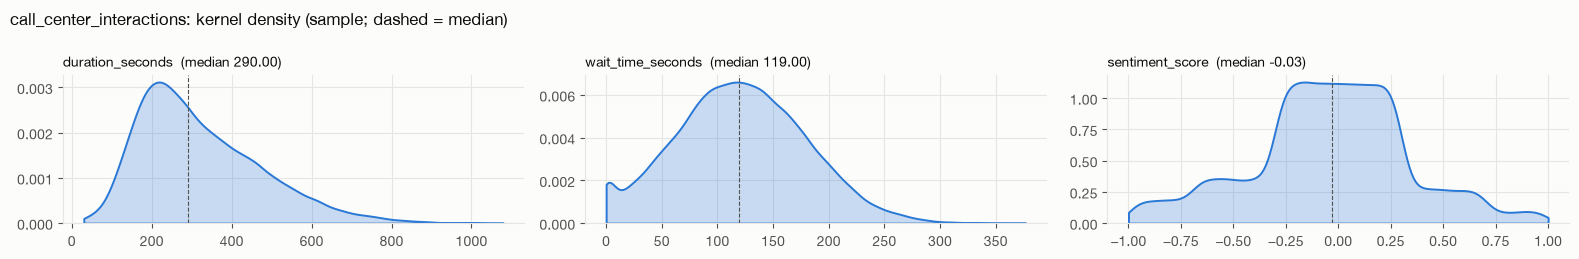

In [34]:
show_distributions(t)
show_categories(t)

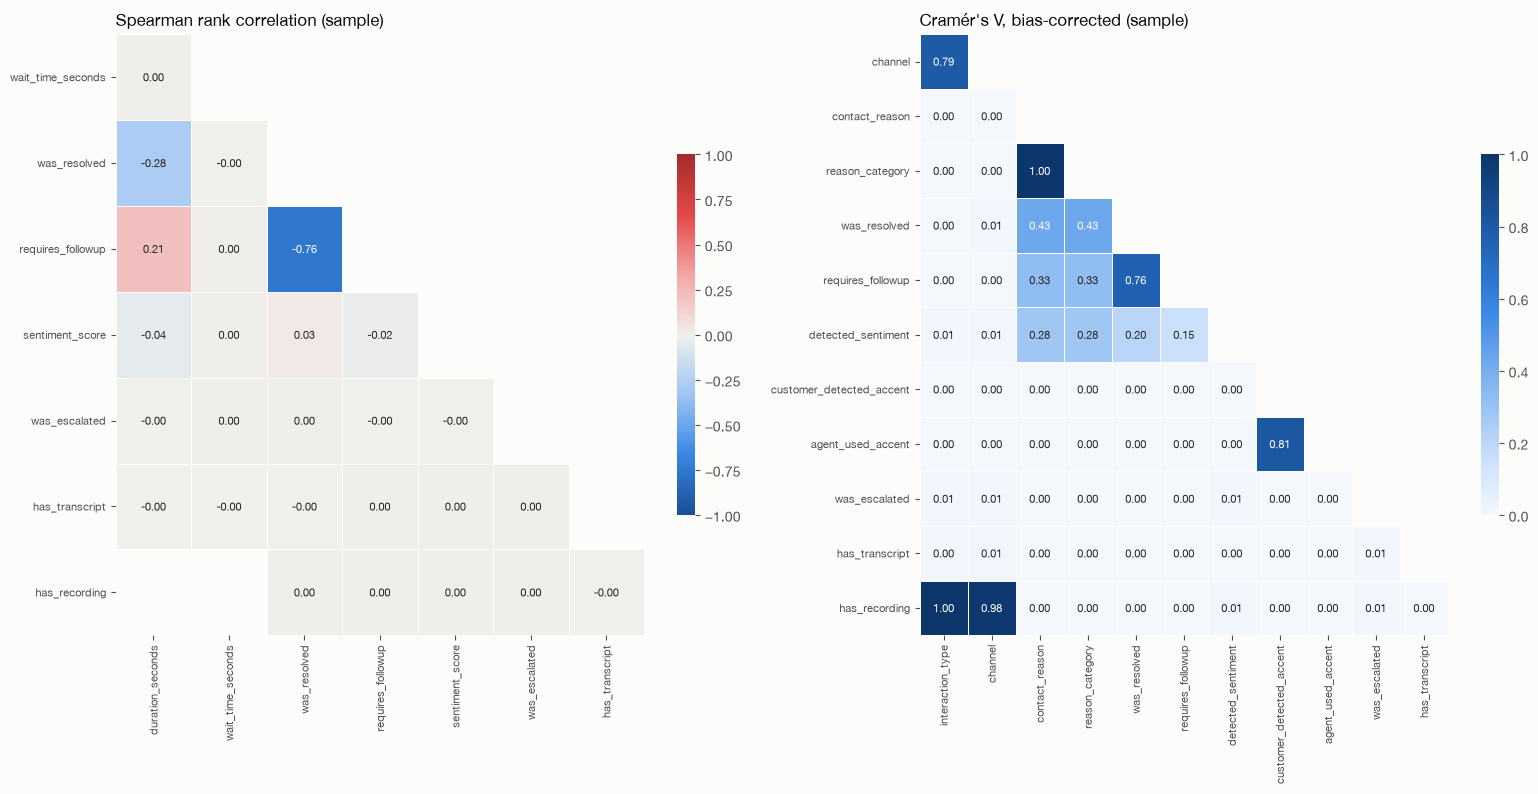

In [35]:
show_associations(t)
show_time(t)

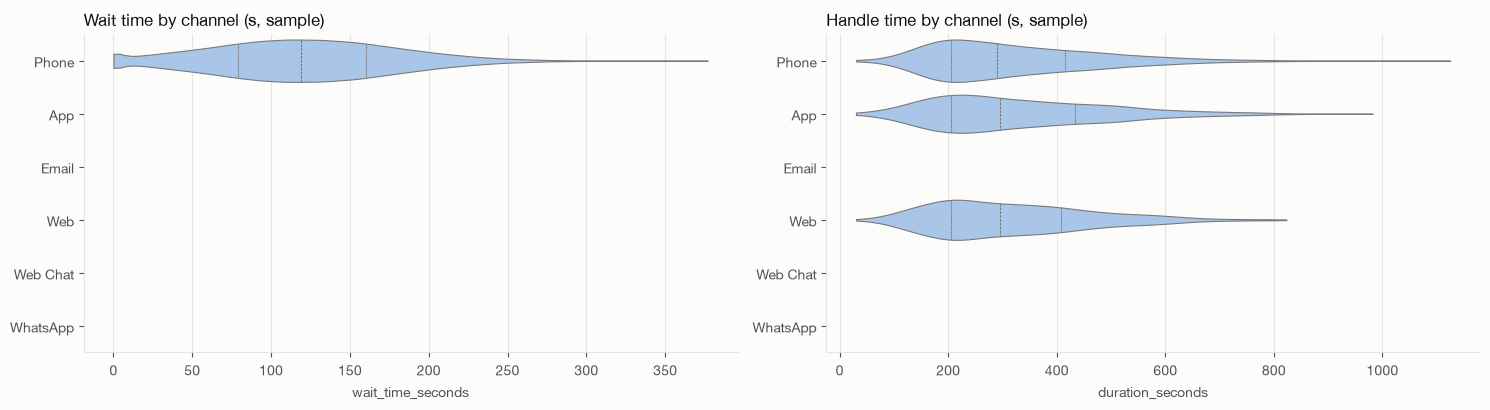

In [36]:
rate_bars(
    {
        "resolved, by reason_category": rate_by(t, "reason_category", "was_resolved"),
        "escalated, by reason_category": rate_by(t, "reason_category", "was_escalated"),
        "resolved, by channel": rate_by(t, "channel", "was_resolved"),
        "follow-up needed, by channel": rate_by(t, "channel", "requires_followup"),
    },
    "Service outcomes (%, exact, 95% Wilson CI)",
)
s = smp(t)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
order = s.groupby("channel")["wait_time_seconds"].median().sort_values().index
sns.violinplot(
    data=s,
    x="wait_time_seconds",
    y="channel",
    order=order,
    ax=axes[0],
    color=theme.SEQ_BLUE[1],
    cut=0,
    inner="quartile",
    linewidth=0.8,
)
axes[0].set_title("Wait time by channel (s, sample)")
sns.violinplot(
    data=s,
    x="duration_seconds",
    y="channel",
    order=order,
    ax=axes[1],
    color=theme.SEQ_BLUE[1],
    cut=0,
    inner="quartile",
    linewidth=0.8,
)
axes[1].set_title("Handle time by channel (s, sample)")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.show()
heat(
    p.crosstab(con, rel(t), "reason_category", "detected_sentiment", normalize="row"),
    "Detected sentiment by reason category (% of the reason's contacts, exact)",
)
heat(
    p.crosstab(con, rel(t), "customer_detected_accent", "agent_used_accent", normalize="row"),
    "Accent match: customer accent (rows) vs accent the agent used (% of row, exact)",
)

### 5.2 `call_transcripts` (fact, text)
**Grain:** one row per transcribed call. **Key:** `transcript_id`, linked to `interaction_id`.
Free text is profiled by length and language only; its content belongs to the knowledge-base and NLP work.

In [37]:
t = "call_transcripts"
show_overview(t)
show_describe(t)

**Shape** 171,321 rows × 18 columns · **est. pandas memory (full table)** 152 MB · **PK** `transcript_id` unique (0 duplicated, 0 null)

`info()` on the sample (171,321 rows):

<class 'pandas.DataFrame'>
RangeIndex: 171321 entries, 0 to 171320
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   transcript_id        171321 non-null  str           
 1   interaction_id       171321 non-null  str           
 2   process_date         171321 non-null  datetime64[us]
 3   customer_id          171321 non-null  str           
 4   agent_id             171321 non-null  str           
 5   full_text            171321 non-null  str           
 6   customer_text        171321 non-null  str           
 7   agent_text           171321 non-null  str           
 8   detected_language    171321 non-null  str           
 9   detected_accent      108238 non-null  str           
 10  accent_confidence    154180 non-null  float64       
 11  detected_keywords    162524 non-null  str           
 12  mentioned_entities   154157 non-null  str           
 13  detected_intents     1628

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
transcript_id,VARCHAR,identifier,"171,321",0,0,0.0%,0.0%,"171,321",100.0%
interaction_id,VARCHAR,identifier,"171,321",0,0,0.0%,0.0%,"171,321",100.0%
process_date,DATE,temporal,"171,321",0,0,0.0%,0.0%,954,0.6%
customer_id,VARCHAR,identifier,"171,321",0,0,0.0%,0.0%,"103,670",60.5%
agent_id,VARCHAR,identifier,"171,321",0,0,0.0%,0.0%,"1,052",0.6%
full_text,VARCHAR,text,"171,321",0,0,0.0%,0.0%,561,0.3%
customer_text,VARCHAR,text,"171,321",0,0,0.0%,0.0%,50,0.0%
agent_text,VARCHAR,text,"171,321",0,0,0.0%,0.0%,35,0.0%
detected_language,VARCHAR,categorical,"171,321",0,0,0.0%,0.0%,1,0.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
accent_confidence,"154,180.00",0.87,0.07,0.75,0.75,0.81,0.87,0.93,0.99,0.99,-0.00,-1.19,0.0%,0.0%,0.0%
duration_seconds,"147,292.00",321.46,153.97,30.00,75.00,205.00,290.00,415.00,764.00,"1,151.00",0.86,0.54,0.0%,0.0%,1.5%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
transcript_id,171321,171321,TRS-PPFGAVR5FA7R3DCC91G4,1
interaction_id,171321,171321,INT-R2TSE2WKP7HVN55Q,1
process_date,171321,1097,2024-12-24,239
customer_id,171321,101951,CLI-X0XITE68B632,9
agent_id,171321,1090,AGT-1HI8LTU9QQ,203
detected_language,171321,1,es,171321
detected_accent,108238,3,mexican,54152
detected_keywords,162524,12,"banco, servicio, cuenta",18173
mentioned_entities,154157,54,"{""account_numbers"": 2, ""dates"": 1, ""amounts"": ...",2971
detected_intents,162864,1,consulta_general,162864


**Missing data (nulls + placeholders), sample.** 7 of 18 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

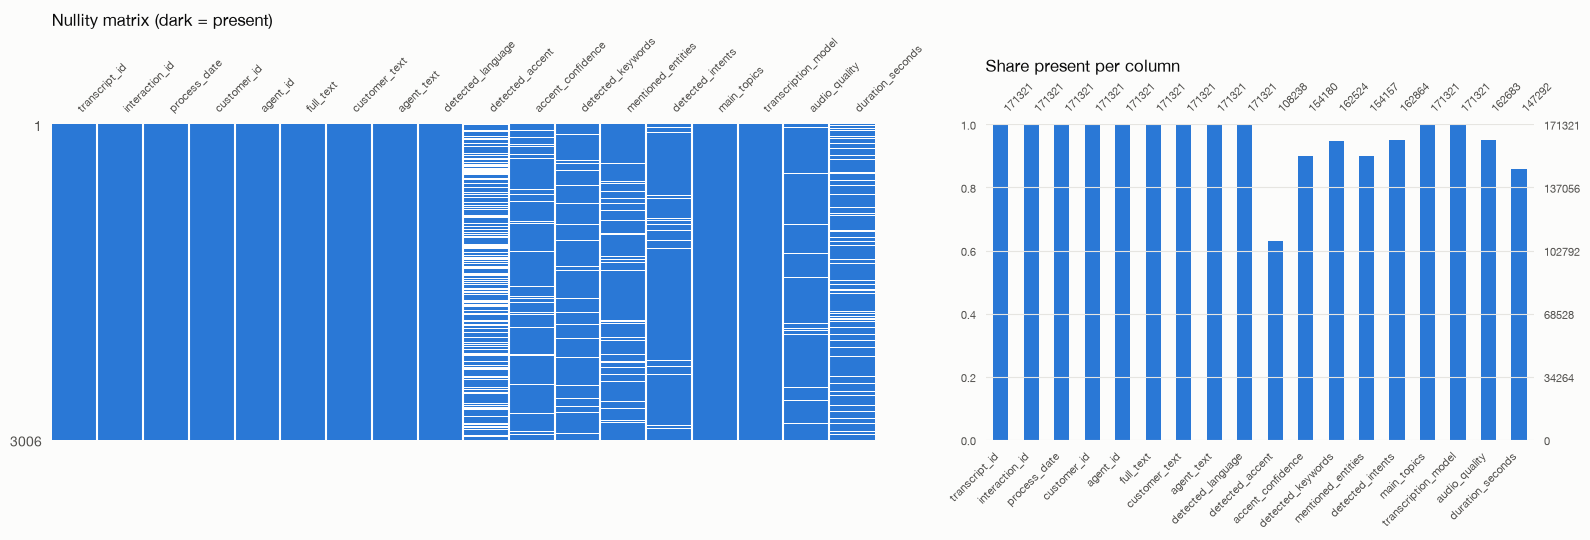

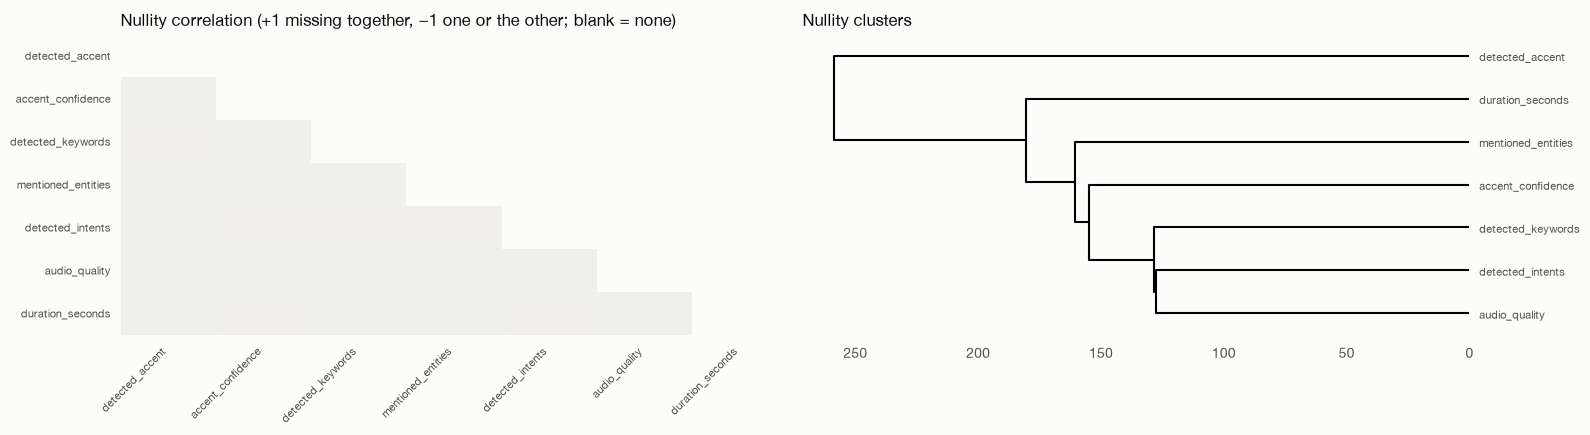

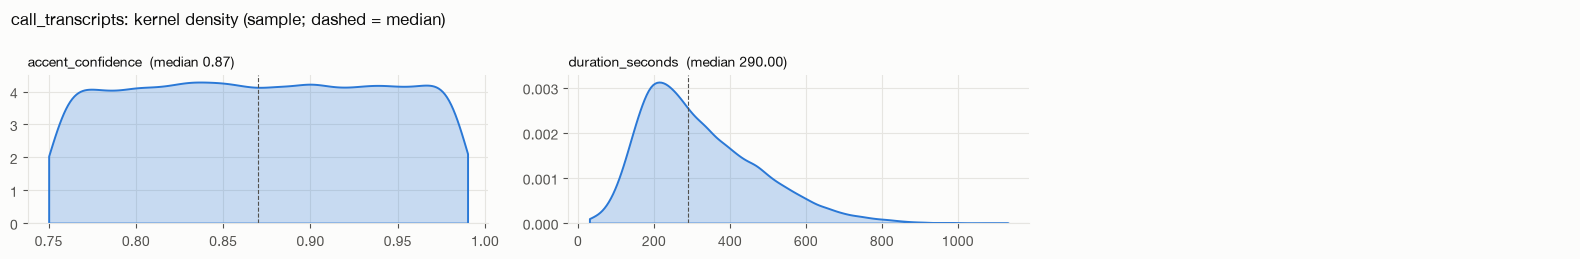

In [38]:
show_missing(t)
show_distributions(t)
show_categories(t)

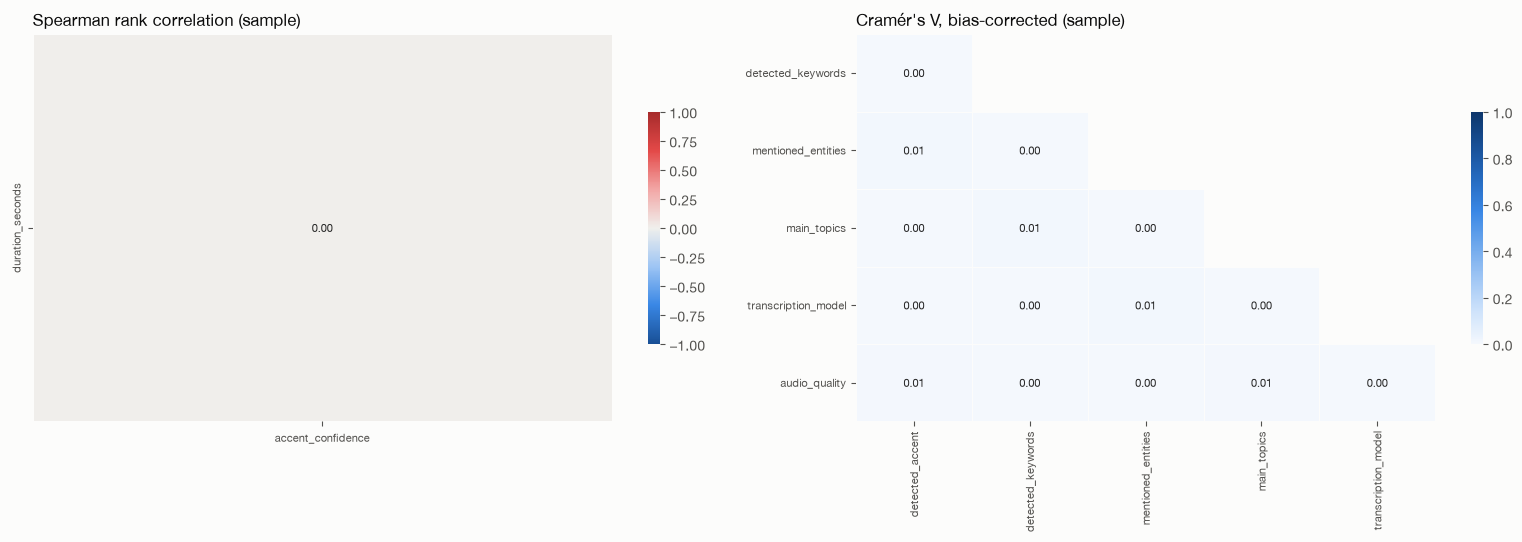

In [39]:
show_associations(t)
show_time(t)

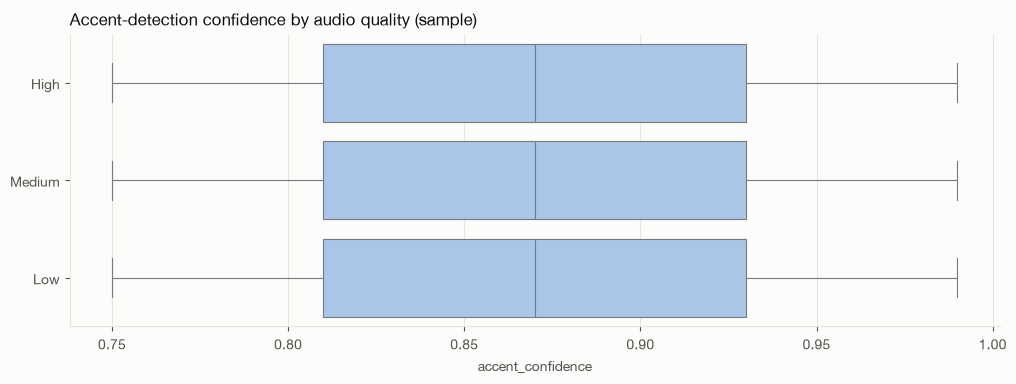

In [40]:
tl = pd.concat(
    {c: p.text_lengths(con, rel(t), c) for c in ["full_text", "customer_text", "agent_text"]},
    names=["field"],
).reset_index(level=0)
# bin before plotting so the figure carries 80 bars per field, not every transcript
edges = np.linspace(0, tl["words"].max(), 81)
binned = pd.concat(
    pd.DataFrame(
        {"field": f, "words": (edges[:-1] + edges[1:]) / 2, "n": np.histogram(g["words"], edges)[0]}
    )
    for f, g in tl.groupby("field")
)
fig = px.bar(
    binned,
    x="words",
    y="n",
    color="field",
    barmode="overlay",
    opacity=0.6,
    color_discrete_sequence=theme.CATEGORICAL,
)
fig.update_layout(bargap=0)
fig.update_layout(
    title="Transcript length in words (exact, every transcript)",
    height=340,
    yaxis_title="transcripts",
)
fig.show()
s = smp(t)
fig, ax = plt.subplots(figsize=(12, 3.8))
sns.boxplot(
    data=s,
    x="accent_confidence",
    y="audio_quality",
    ax=ax,
    color=theme.SEQ_BLUE[1],
    fliersize=1,
    linewidth=0.8,
)
ax.set_title("Accent-detection confidence by audio quality (sample)")
ax.set_ylabel("")
plt.show()

### 5.3 `satisfaction_surveys` (fact)
**Grain:** one survey response. **Key:** `survey_id`. Three instruments share one table (CSAT, NPS, CES),
so `main_score` means something different per `survey_type` and must be read per type.

In [41]:
t = "satisfaction_surveys"
show_overview(t)
show_describe(t)

**Shape** 212,759 rows × 20 columns · **est. pandas memory (full table)** 67 MB · **PK** `survey_id` unique (0 duplicated, 0 null)

`info()` on the sample (200,000 rows):

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   survey_id               200000 non-null  str           
 1   survey_date             200000 non-null  datetime64[us]
 2   process_date            200000 non-null  datetime64[us]
 3   interaction_id          200000 non-null  str           
 4   customer_id             200000 non-null  str           
 5   agent_id                200000 non-null  str           
 6   survey_type             200000 non-null  str           
 7   send_channel            200000 non-null  str           
 8   main_score              200000 non-null  int64         
 9   nps_category            56749 non-null   str           
 10  question_1_text         114017 non-null  str           
 11  question_1_response     114117 non-null  float64       
 12  question_2_text         76492 non-null   

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
survey_id,VARCHAR,identifier,"212,759",0,0,0.0%,0.0%,"202,151",95.0%
survey_date,TIMESTAMP,temporal,"212,759",0,0,0.0%,0.0%,"212,759",100.0%
process_date,DATE,temporal,"212,759",0,0,0.0%,0.0%,954,0.4%
interaction_id,VARCHAR,identifier,"212,759",0,0,0.0%,0.0%,"212,759",100.0%
customer_id,VARCHAR,identifier,"212,759",0,0,0.0%,0.0%,"140,954",66.3%
agent_id,VARCHAR,identifier,"212,759",0,0,0.0%,0.0%,"1,052",0.5%
survey_type,VARCHAR,categorical,"212,759",0,0,0.0%,0.0%,3,0.0%
send_channel,VARCHAR,categorical,"212,759",0,0,0.0%,0.0%,5,0.0%
main_score,BIGINT,numeric,"212,759",0,0,0.0%,0.0%,7,0.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
main_score,"212,759.00",3.53,1.54,1.00,1.00,3.00,3.00,4.00,7.00,7.00,0.93,-0.03,0.0%,0.0%,17.7%
question_1_response,"121,370.00",3.01,1.41,1.00,1.00,2.00,3.00,4.00,5.00,5.00,-0.01,-1.30,0.0%,0.0%,0.0%
question_2_response,"81,496.00",3.01,1.41,1.00,1.00,2.00,3.00,4.00,5.00,5.00,-0.01,-1.29,0.0%,0.0%,0.0%
question_3_response,"40,103.00",2.99,1.41,1.00,1.00,2.00,3.00,4.00,5.00,5.00,0.01,-1.30,0.0%,0.0%,0.0%
response_time_hours,"212,759.00",18.47,7.49,1.01,3.36,12.73,18.46,24.23,33.63,35.97,0.01,-0.80,0.0%,0.0%,0.0%
campaign_response_rate,"180,722.00",29.96,8.66,15.00,15.29,22.45,29.95,37.46,44.70,45.00,0.00,-1.20,0.0%,0.0%,0.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
survey_id,200000,200000,SRV-F9413FACD3ICD7PPER13,1
survey_date,200000,199781,2025-12-23 15:10:46,2
process_date,200000,1097,2023-06-28,260
interaction_id,200000,200000,INT-TQRIB3N2E70DRBKV,1
customer_id,200000,110376,CLI-835C17OV2KKM,10
agent_id,200000,1090,AGT-R5961LOEMU,228
survey_type,200000,3,CSAT,120234
send_channel,200000,5,Email,79753
nps_category,56749,2,Detractor,42303
question_1_text,114017,3,¿Cómo calificaría la atención brindada?,38227


**Missing data (nulls + placeholders), sample.** 10 of 20 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

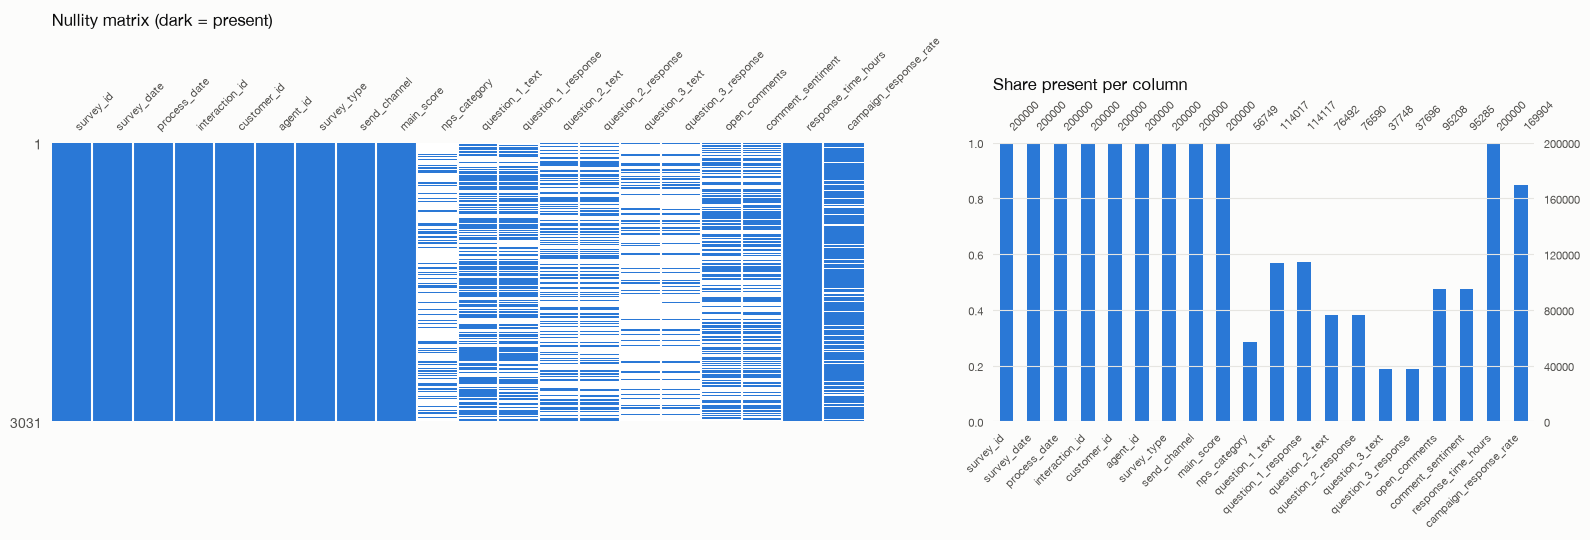

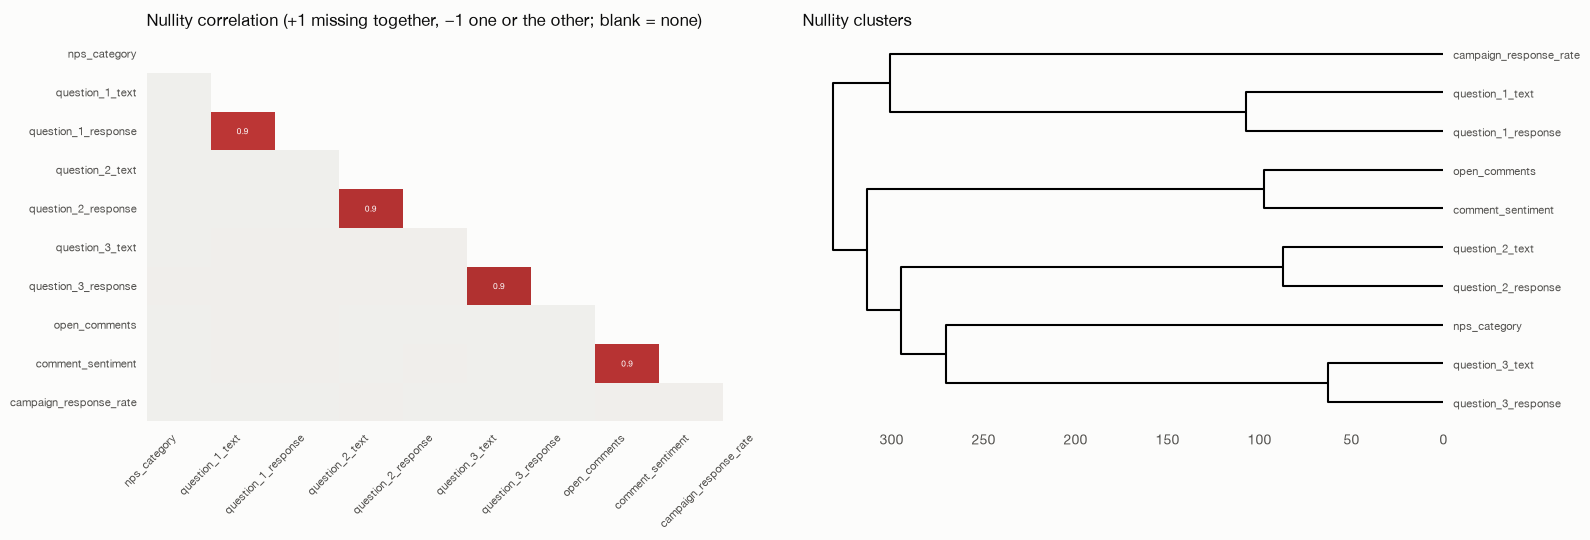

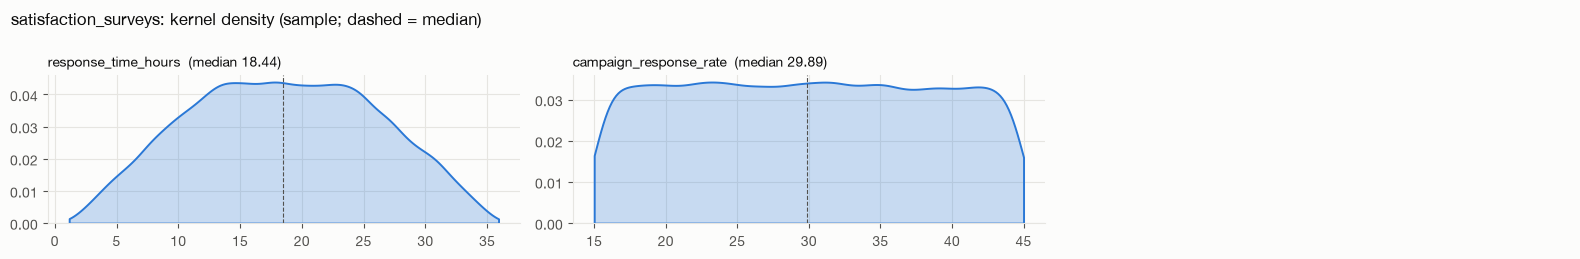

In [42]:
show_missing(t)
show_distributions(t)
show_categories(t)

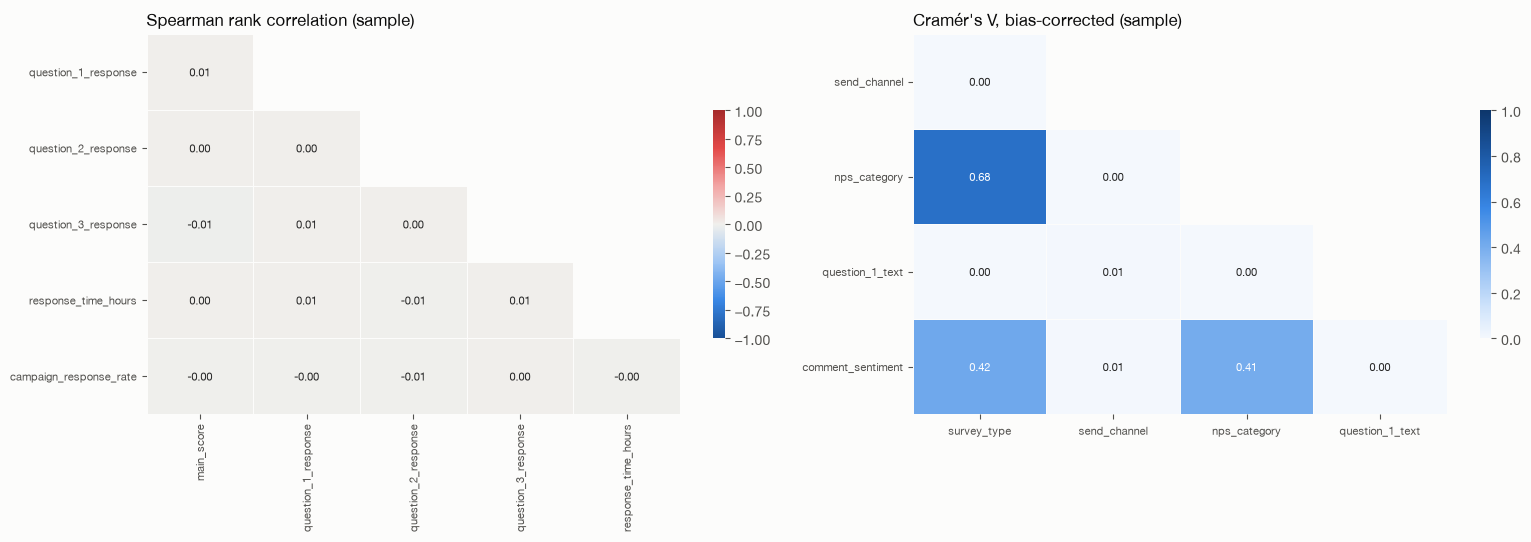

In [43]:
show_associations(t)
show_time(t)

In [44]:
sc = con.sql(
    "select survey_type, main_score, count(*) n from m_satisfaction_surveys group by 1, 2"
).df()
fig = px.bar(
    sc, x="main_score", y="n", facet_col="survey_type", color_discrete_sequence=[theme.BLUE]
)
fig.update_yaxes(matches=None, showticklabels=True)
fig.update_layout(title="main_score distribution per survey type (exact)", height=330)
fig.show()
ct = p.crosstab(con, rel(t), "main_score", "nps_category", top=20)
heat(
    ct.sort_index(key=lambda i: i.astype(int)),
    "main_score vs nps_category label (count, exact)",
    fmt="d",
)
nps = con.sql(
    """select 100 * avg((main_score >= 9)::int) - 100 * avg((main_score <= 6)::int)
       from m_satisfaction_surveys where survey_type = 'NPS'"""
).fetchone()[0]
h(
    f"**NPS recomputed from `main_score` (0–10 scale) = {nps:,.1f}** "
    "(promoters 9–10 minus detractors 0–6). Compare with the `nps_category` labels above."
)

**NPS recomputed from `main_score` (0–10 scale) = -74.5** (promoters 9–10 minus detractors 0–6). Compare with the `nps_category` labels above.

### 5.4 `complaints` (fact)
**Grain:** one complaint case. **Key:** `complaint_id`. Lifecycle dates (creation → assignment →
first response → resolution → closing), SLA and compensation: a regulatory-sensitive table.

In [45]:
t = "complaints"
show_overview(t)
show_describe(t)

**Shape** 67,095 rows × 27 columns · **est. pandas memory (full table)** 26 MB · **PK** `complaint_id` unique (0 duplicated, 0 null)

`info()` on the sample (67,095 rows):

<class 'pandas.DataFrame'>
RangeIndex: 67095 entries, 0 to 67094
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   complaint_id             67095 non-null  str           
 1   creation_date            67095 non-null  datetime64[us]
 2   process_date             67095 non-null  datetime64[us]
 3   customer_id              67095 non-null  str           
 4   case_type                67095 non-null  str           
 5   category                 67095 non-null  str           
 6   subcategory              60397 non-null  str           
 7   reception_channel        67095 non-null  str           
 8   affected_product_id      44570 non-null  str           
 9   related_branch_id        19178 non-null  str           
 10  origin_interaction_id    0 non-null      object        
 11  description              67095 non-null  str           
 12  claimed_amount           21751 non-null  fl

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
complaint_id,VARCHAR,identifier,"67,095",0,0,0.0%,0.0%,"66,008",98.4%
creation_date,TIMESTAMP,temporal,"67,095",0,0,0.0%,0.0%,"67,095",100.0%
process_date,DATE,temporal,"67,095",0,0,0.0%,0.0%,954,1.4%
customer_id,VARCHAR,identifier,"67,095",0,0,0.0%,0.0%,"59,121",88.1%
case_type,VARCHAR,categorical,"67,095",0,0,0.0%,0.0%,4,0.0%
category,VARCHAR,categorical,"67,095",0,0,0.0%,0.0%,5,0.0%
subcategory,VARCHAR,categorical,"60,397","6,698",0,10.0%,10.0%,5,0.0%
reception_channel,VARCHAR,categorical,"67,095",0,0,0.0%,0.0%,5,0.0%
affected_product_id,VARCHAR,identifier,"44,570","22,525",0,33.6%,33.6%,"44,570",100.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
claimed_amount,"21,751.00","2,535.52","1,429.72",50.27,101.51,"1,290.84","2,533.08","3,771.19","4,949.88","4,999.93",-0.01,-1.20,0.0%,0.0%,0.0%
resolution_days,"15,363.00",15.60,8.71,1.00,1.00,8.00,16.00,23.00,30.00,30.00,-0.01,-1.22,0.0%,0.0%,0.0%
compensation_granted,"4,641.00",253.14,142.65,10.15,14.96,127.74,252.59,374.13,494.69,499.98,0.00,-1.20,0.0%,0.0%,0.0%
resolution_satisfaction,"2,484.00",3.02,1.43,1.00,1.00,2.00,3.00,4.00,5.00,5.00,-0.02,-1.31,0.0%,0.0%,0.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
complaint_id,67095,67095,CMP-J7LT0TPC5YC33ULTQJZD,1
creation_date,67095,67074,2023-07-01 07:19:27,2
process_date,67095,1097,2023-07-25,86
customer_id,67095,54145,CLI-3KGTW0RAXP05,6
case_type,67095,4,Complaint,40452
category,67095,5,Transactions,13580
subcategory,60397,5,Cargo no reconocido,12297
reception_channel,67095,6,Call Center,33761
affected_product_id,44570,42184,PRD-MHELT805RST3,5
related_branch_id,19178,350,SUC-FQBLIDK9,76


**Missing data (nulls + placeholders), sample.** 15 of 27 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

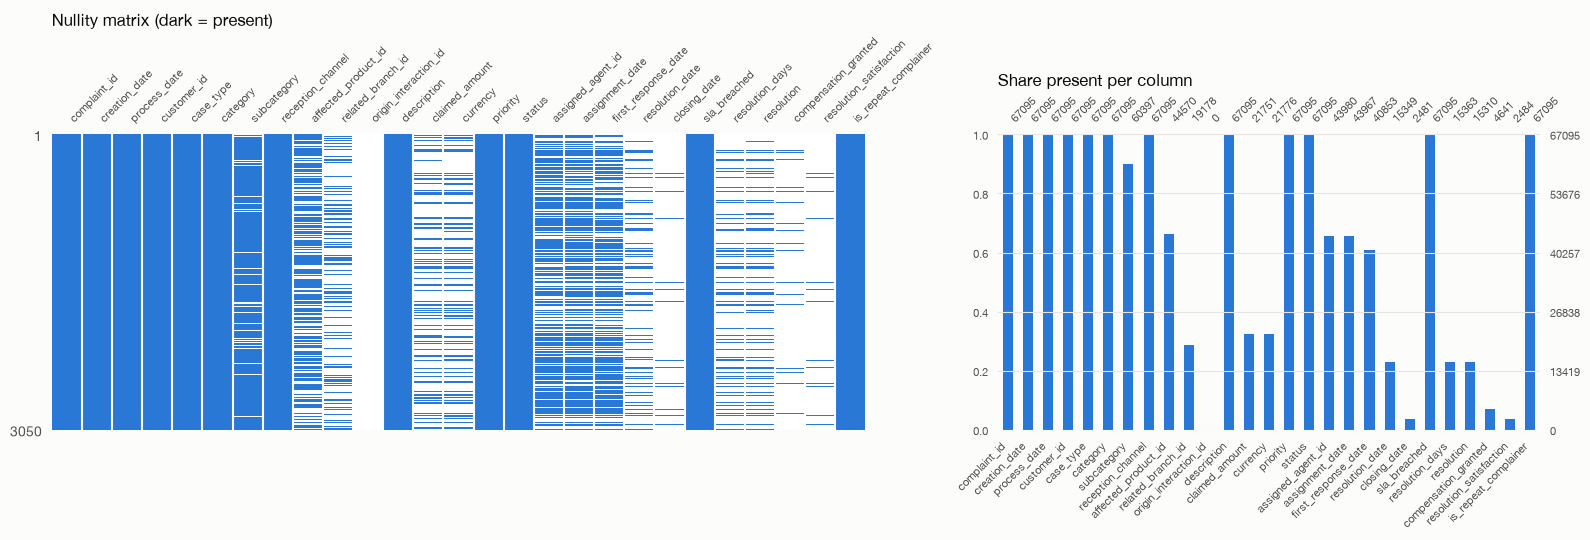

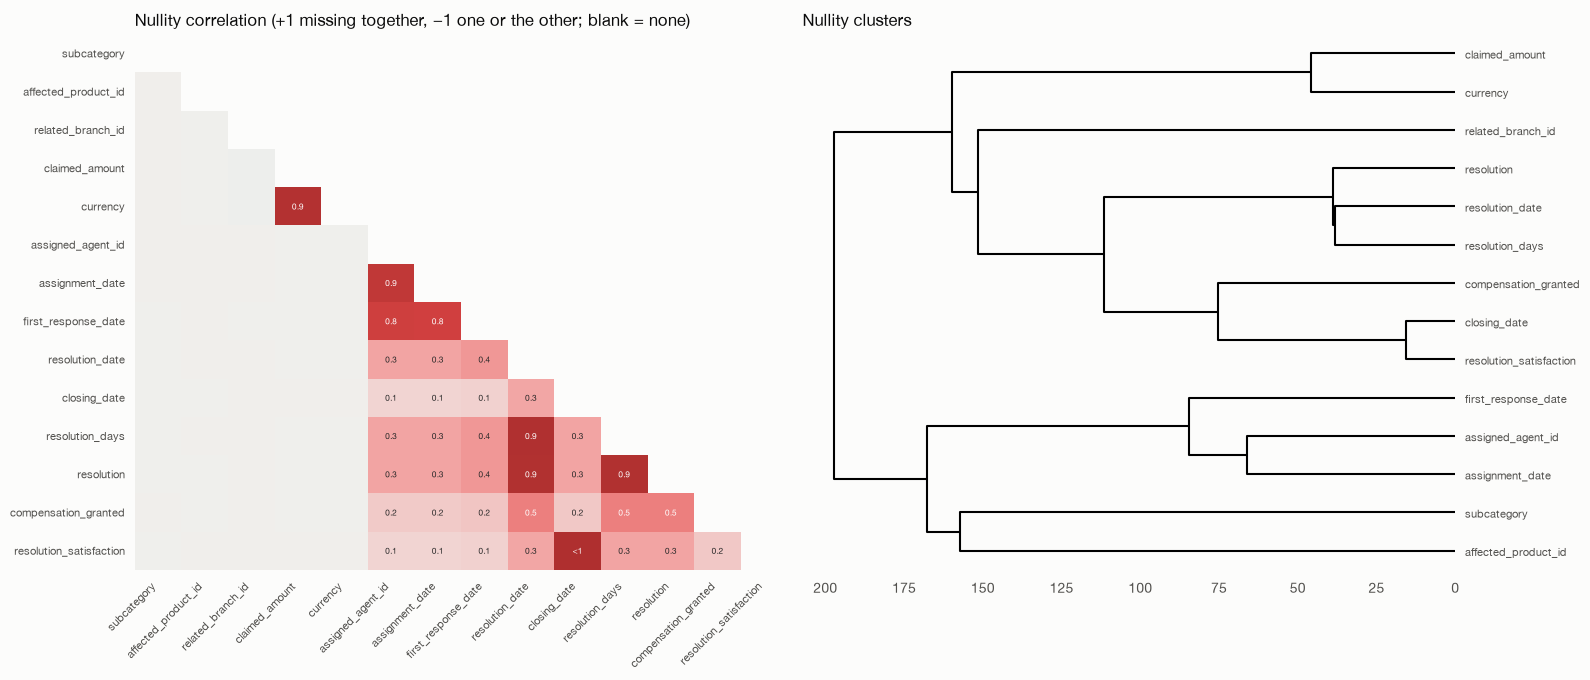

In [46]:
show_missing(t)

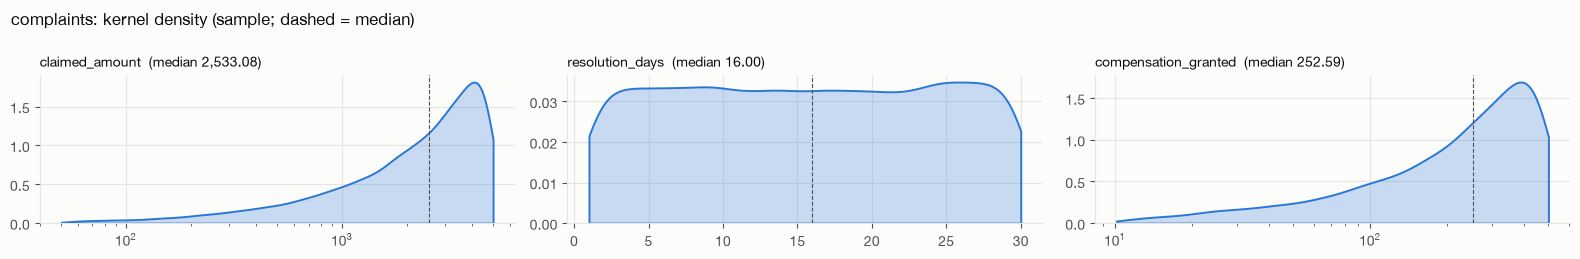

In [47]:
show_distributions(t)
show_categories(t)

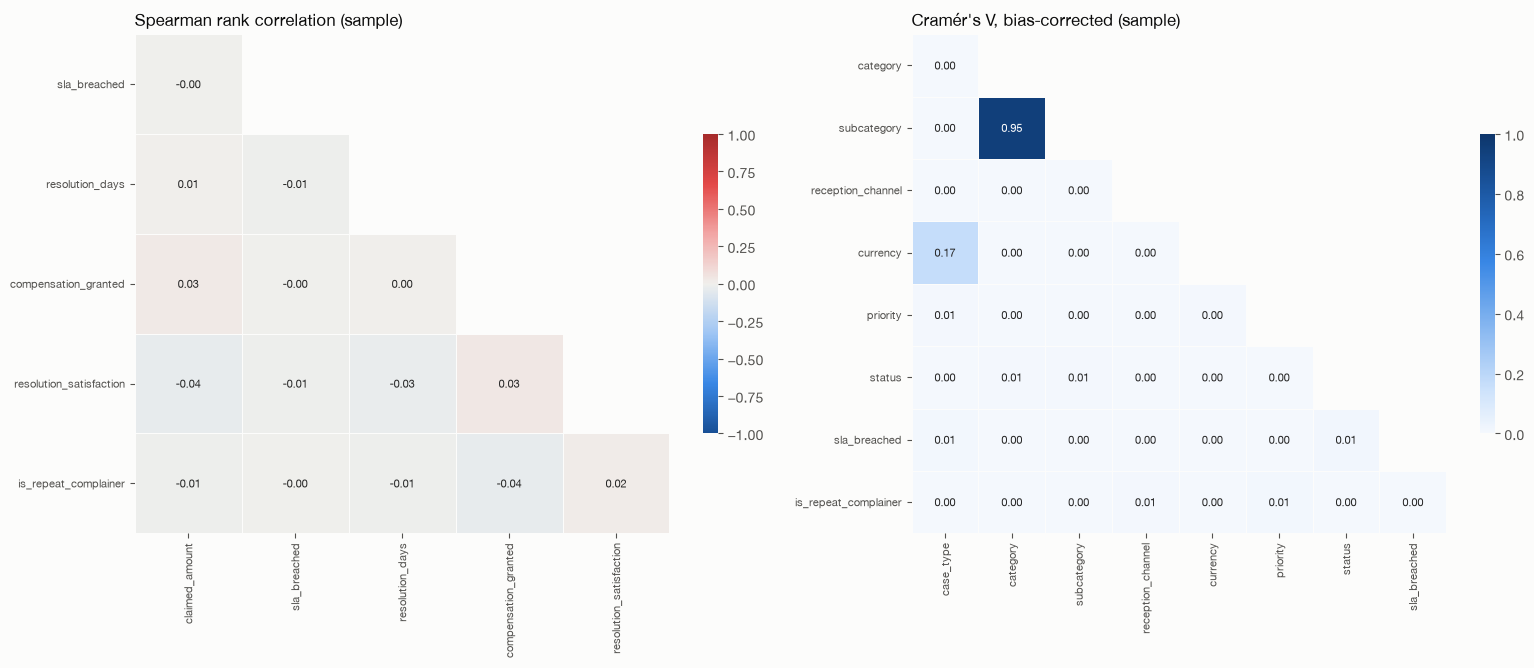

In [48]:
show_associations(t)
show_time(t)

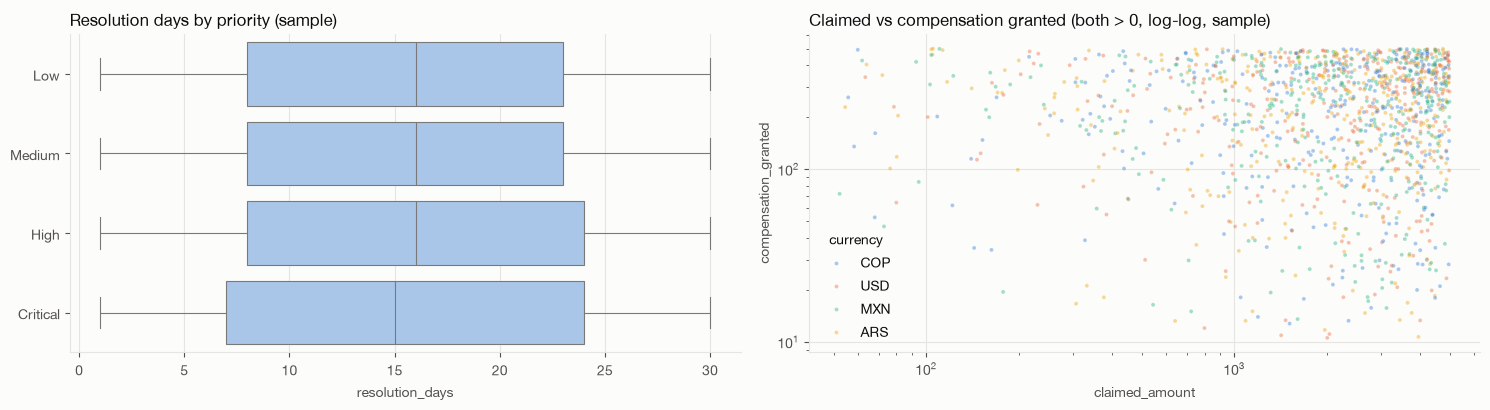

**Lifecycle consistency (exact).** Mean durations from the date columns, and the share of impossible orders:

,value
assign_days,0.519
first_response_days,1.563
resolution_days_from_dates,15.581
resolution_days_column,15.601
resolved_before_created_share,0.000
closed_before_resolved_share,0.000


In [49]:
sla = con.sql(
    "select category, priority, 100 * avg(sla_breached::int) r from m_complaints group by 1, 2"
).df()
sla = sla.pivot(index="category", columns="priority", values="r")
heat(
    sla[[c for c in ["Low", "Medium", "High", "Critical"] if c in sla.columns]],
    "SLA breach rate by category × priority (%, exact)",
)
s = smp(t)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
pri = [x for x in ["Low", "Medium", "High", "Critical"] if x in set(s["priority"])]
sns.boxplot(
    data=s,
    x="resolution_days",
    y="priority",
    order=pri,
    ax=axes[0],
    color=theme.SEQ_BLUE[1],
    fliersize=1,
    linewidth=0.8,
)
axes[0].set_title("Resolution days by priority (sample)")
comp = s[(s["claimed_amount"] > 0) & (s["compensation_granted"] > 0)]
sns.scatterplot(
    data=comp,
    x="claimed_amount",
    y="compensation_granted",
    hue="currency",
    s=8,
    alpha=0.4,
    ax=axes[1],
    palette=theme.CATEGORICAL[: comp["currency"].nunique()],
)
axes[1].set(
    xscale="log", yscale="log", title="Claimed vs compensation granted (both > 0, log-log, sample)"
)
axes[0].set_ylabel("")
plt.tight_layout()
plt.show()
lc = (
    con.sql(
        """select avg(date_diff('hour', creation_date, assignment_date)) / 24 assign_days,
              avg(date_diff('hour', creation_date, first_response_date)) / 24 first_response_days,
              avg(date_diff('hour', creation_date, resolution_date)) / 24 resolution_days_from_dates,
              avg(resolution_days) resolution_days_column,
              avg((resolution_date < creation_date)::int) resolved_before_created_share,
              avg((closing_date < resolution_date)::int) closed_before_resolved_share
       from m_complaints"""
    )
    .df()
    .T.rename(columns={0: "value"})
)
h(
    "**Lifecycle consistency (exact).** Mean durations from the date columns, and the share of impossible orders:"
)
display(lc.style.format("{:,.3f}"))

## 6 · Marketing
### 6.1 `marketing_campaigns` (dimension)
**Grain:** one campaign. **Key:** `campaign_id`. Budget, objective, target segment and expected conversion.

**Shape** 200 rows × 13 columns · **est. pandas memory (full table)** 0 MB · **PK** `campaign_id` unique (0 duplicated, 0 null)

`info()` on the sample (200 rows):

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   campaign_id               200 non-null    str           
 1   campaign_name             200 non-null    str           
 2   description               161 non-null    str           
 3   campaign_type             200 non-null    str           
 4   campaign_objective        200 non-null    str           
 5   promoted_product          178 non-null    str           
 6   target_segment            121 non-null    str           
 7   target_country            89 non-null     str           
 8   start_date                200 non-null    datetime64[us]
 9   end_date                  200 non-null    datetime64[us]
 10  budget                    169 non-null    float64       
 11  campaign_status           200 non-null    str           
 12  expected_conversion_rate  186 non

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
campaign_id,VARCHAR,identifier,200,0,0,0.0%,0.0%,200,100.0%
campaign_name,VARCHAR,categorical,200,0,0,0.0%,0.0%,188,94.0%
description,VARCHAR,text,161,39,0,19.5%,19.5%,35,21.7%
campaign_type,VARCHAR,categorical,200,0,0,0.0%,0.0%,6,3.0%
campaign_objective,VARCHAR,categorical,200,0,0,0.0%,0.0%,5,2.5%
promoted_product,VARCHAR,categorical,178,22,0,11.0%,11.0%,6,3.4%
target_segment,VARCHAR,categorical,121,79,0,39.5%,39.5%,4,3.3%
target_country,VARCHAR,categorical,89,111,0,55.5%,55.5%,3,3.4%
start_date,DATE,temporal,200,0,0,0.0%,0.0%,192,96.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
budget,169.00,"263,990.23","140,396.66","6,355.31","9,742.59","150,646.61","272,363.71","381,929.43","495,295.16","499,954.38",-0.10,-1.14,0.0%,0.0%,0.0%
expected_conversion_rate,186.00,7.66,4.05,0.55,0.89,4.07,7.53,11.01,14.54,14.69,0.08,-1.23,0.0%,0.0%,0.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
campaign_id,200,200,CMP-8LKPPFGAVR5F,1
campaign_name,200,200,CMP_ACQ_CC_Jan2024_0001,1
campaign_type,200,6,Email,67
campaign_objective,200,5,Retention,62
promoted_product,178,7,Tarjeta Crédito,52
target_segment,121,4,Plus,32
target_country,89,3,Colombia,33
start_date,200,186,2024-11-06,3
end_date,200,180,2024-09-22,4
campaign_status,200,3,Completed,172


**Missing data (nulls + placeholders), sample.** 6 of 13 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

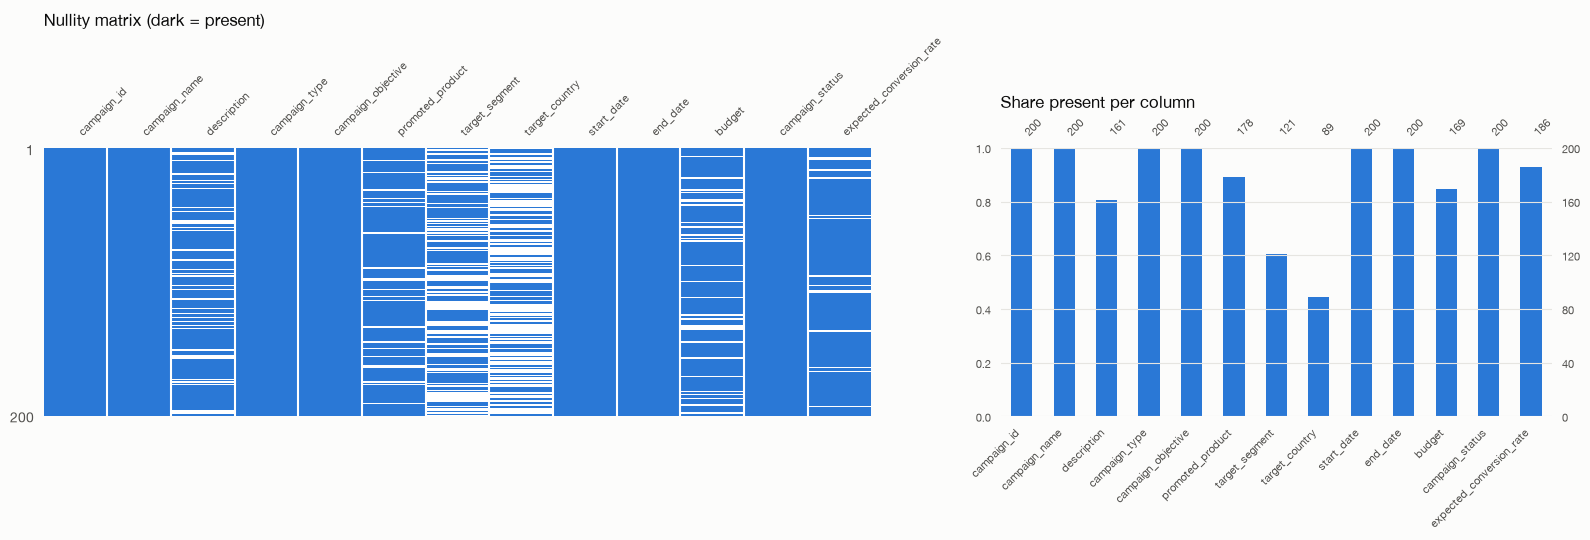

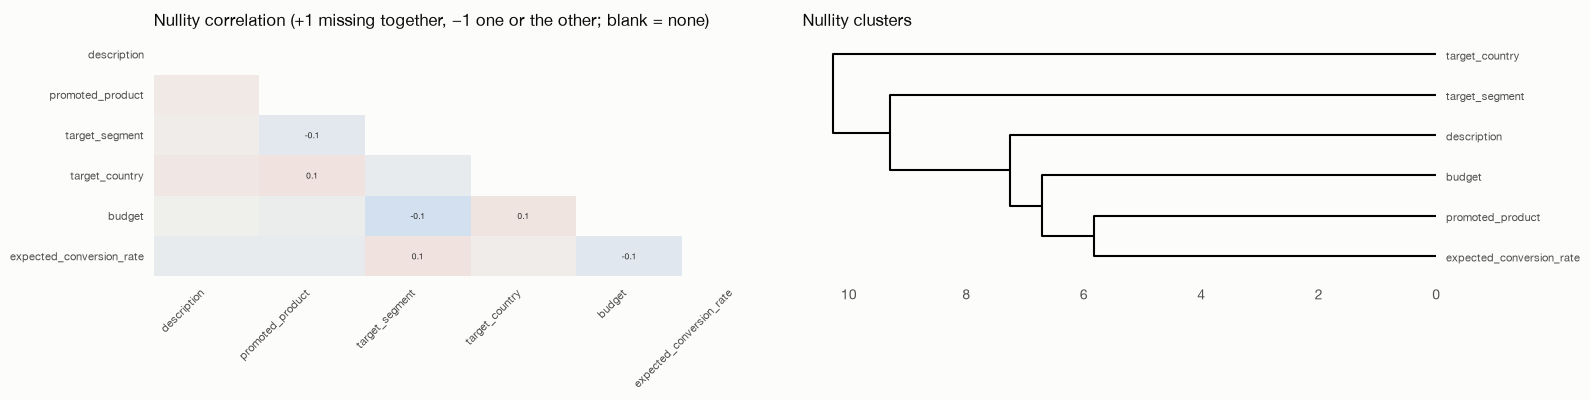

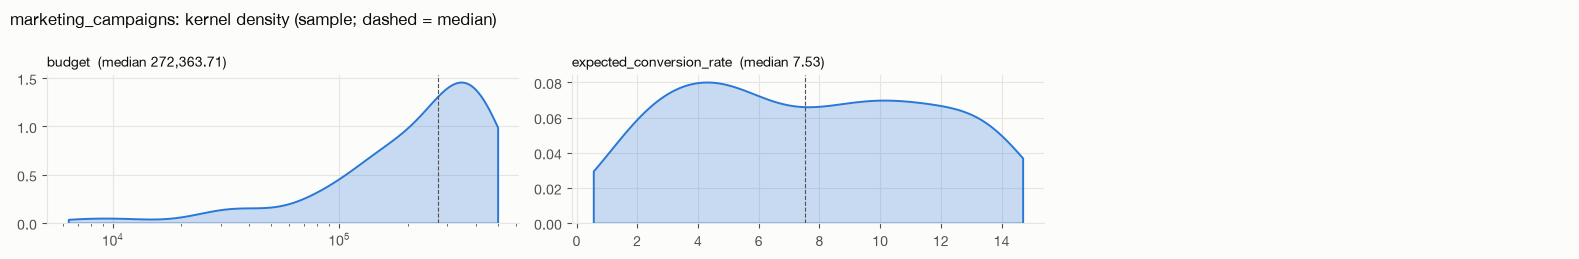

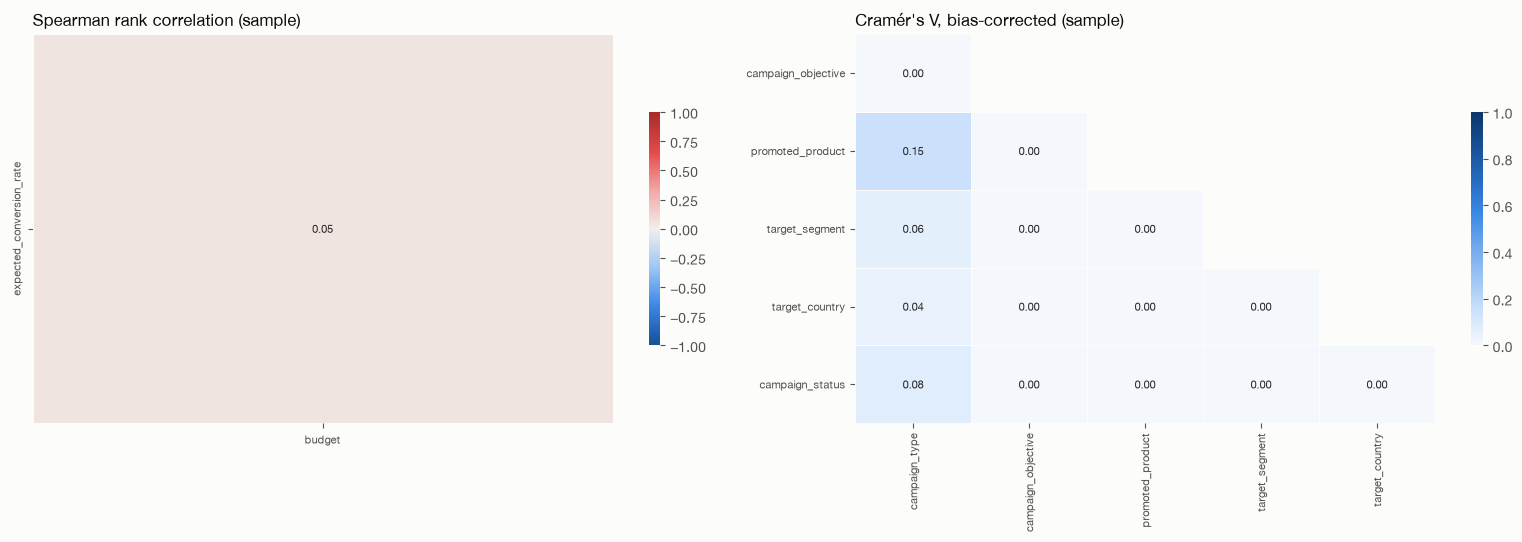

In [50]:
t = "marketing_campaigns"
core(t)

In [51]:
mc = con.sql("select * from m_marketing_campaigns order by start_date").df()
fig = px.timeline(
    mc,
    x_start="start_date",
    x_end="end_date",
    y="campaign_type",
    color="campaign_objective",
    hover_name="campaign_name",
    hover_data=["budget", "target_segment", "campaign_status"],
    color_discrete_sequence=theme.CATEGORICAL,
)
fig.update_traces(opacity=0.55)
fig.update_layout(
    title="Campaign calendar by type (colour = objective)", height=420, yaxis_title=""
)
fig.show()

### 6.2 `campaign_sends` (fact)
**Grain:** one message sent to one customer. **Key:** `send_id`. The marketing funnel: sent → delivered →
opened → clicked → converted, with cost and conversion value.

In [52]:
t = "campaign_sends"
show_overview(t)
show_describe(t)

**Shape** 1,746,801 rows × 22 columns · **est. pandas memory (full table)** 445 MB · **PK** `send_id` unique (0 duplicated, 0 null)

`info()` on the sample (200,000 rows):

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   send_id           200000 non-null  str           
 1   send_date         200000 non-null  datetime64[us]
 2   process_date      200000 non-null  datetime64[us]
 3   campaign_id       200000 non-null  str           
 4   customer_id       200000 non-null  str           
 5   send_channel      200000 non-null  str           
 6   template_used     179850 non-null  str           
 7   subject           63630 non-null   str           
 8   send_status       200000 non-null  str           
 9   was_delivered     200000 non-null  bool          
 10  was_opened        144491 non-null  boolean       
 11  open_date         55825 non-null   datetime64[us]
 12  was_clicked       200000 non-null  bool          
 13  click_date        11276 non-null   datetime64[us]
 14  click_count    

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
send_id,VARCHAR,identifier,"1,746,801",0,0,0.0%,0.0%,"1,746,801",100.0%
send_date,TIMESTAMP,temporal,"1,746,801",0,0,0.0%,0.0%,"1,746,801",100.0%
process_date,DATE,temporal,"1,746,801",0,0,0.0%,0.0%,954,0.1%
campaign_id,VARCHAR,identifier,"1,746,801",0,0,0.0%,0.0%,164,0.0%
customer_id,VARCHAR,identifier,"1,746,801",0,0,0.0%,0.0%,"173,849",10.0%
send_channel,VARCHAR,categorical,"1,746,801",0,0,0.0%,0.0%,5,0.0%
template_used,VARCHAR,categorical,"1,571,583","175,218",0,10.0%,10.0%,858,0.1%
subject,VARCHAR,text,"558,459","1,188,342",0,68.0%,68.0%,9,0.0%
send_status,VARCHAR,categorical,"1,746,801",0,0,0.0%,0.0%,4,0.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
click_count,"97,793.00",3.00,1.41,1.00,1.00,2.00,3.00,4.00,5.00,5.00,-0.00,-1.30,0.0%,0.0%,0.0%
conversion_value,"9,799.00","2,547.09","1,430.59",100.88,145.68,"1,291.70","2,533.36","3,777.64","4,958.80","4,999.75",0.01,-1.20,0.0%,0.0%,0.0%
send_cost,"1,484,718.00",0.04,0.05,0.00,0.00,0.00,0.01,0.07,0.24,0.30,1.52,2.69,0.0%,0.0%,1.9%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
send_id,200000,200000,SND-SD6KB9IH8VBDGYNLB56V,1
send_date,200000,199757,2024-12-28 02:33:34,3
process_date,200000,1083,2023-10-04,290
campaign_id,200000,175,CMP-KJQXW6V6XZEH,3940
customer_id,200000,110598,CLI-NGLD22GWUPWX,9
send_channel,200000,5,Email,70608
template_used,179850,875,template_CMP-KJQXW6V6XZEH_5,776
send_status,200000,4,Sent,188045
was_delivered,200000,2,True,188045
was_opened,144491,2,False,88666


**Missing data (nulls + placeholders), sample.** 12 of 22 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

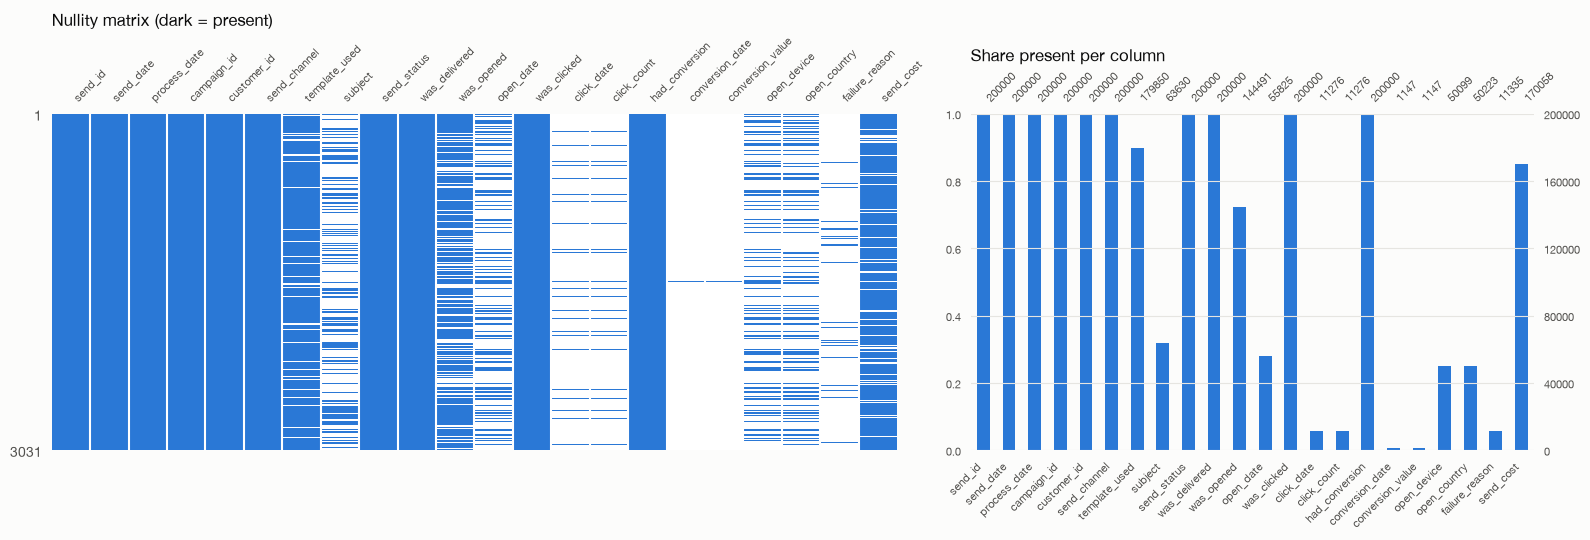

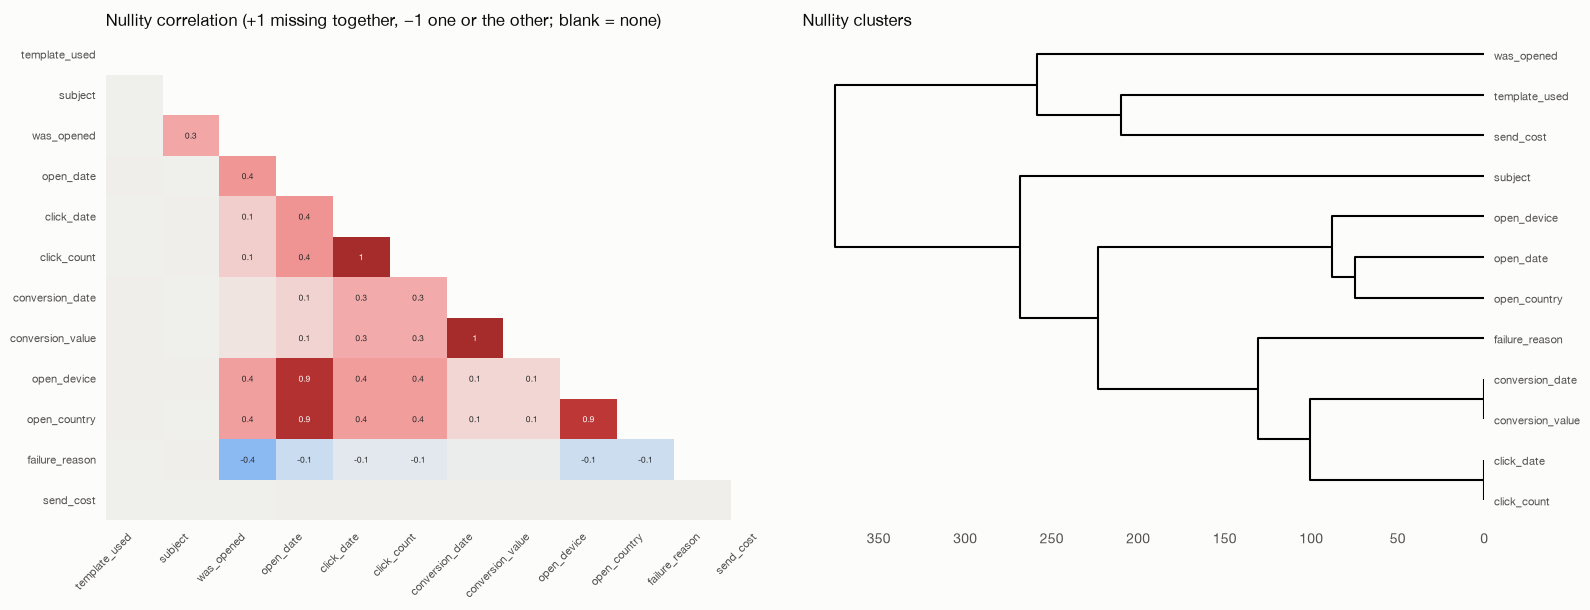

In [53]:
show_missing(t)

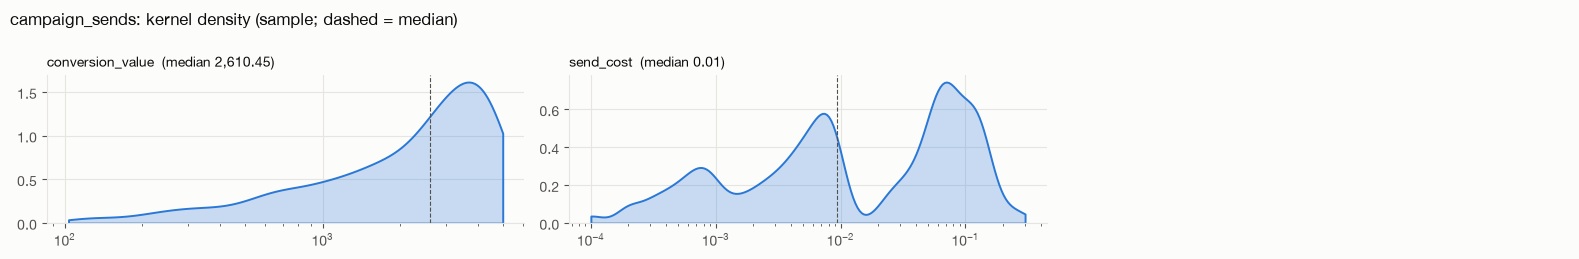

In [54]:
show_distributions(t)
show_categories(t)

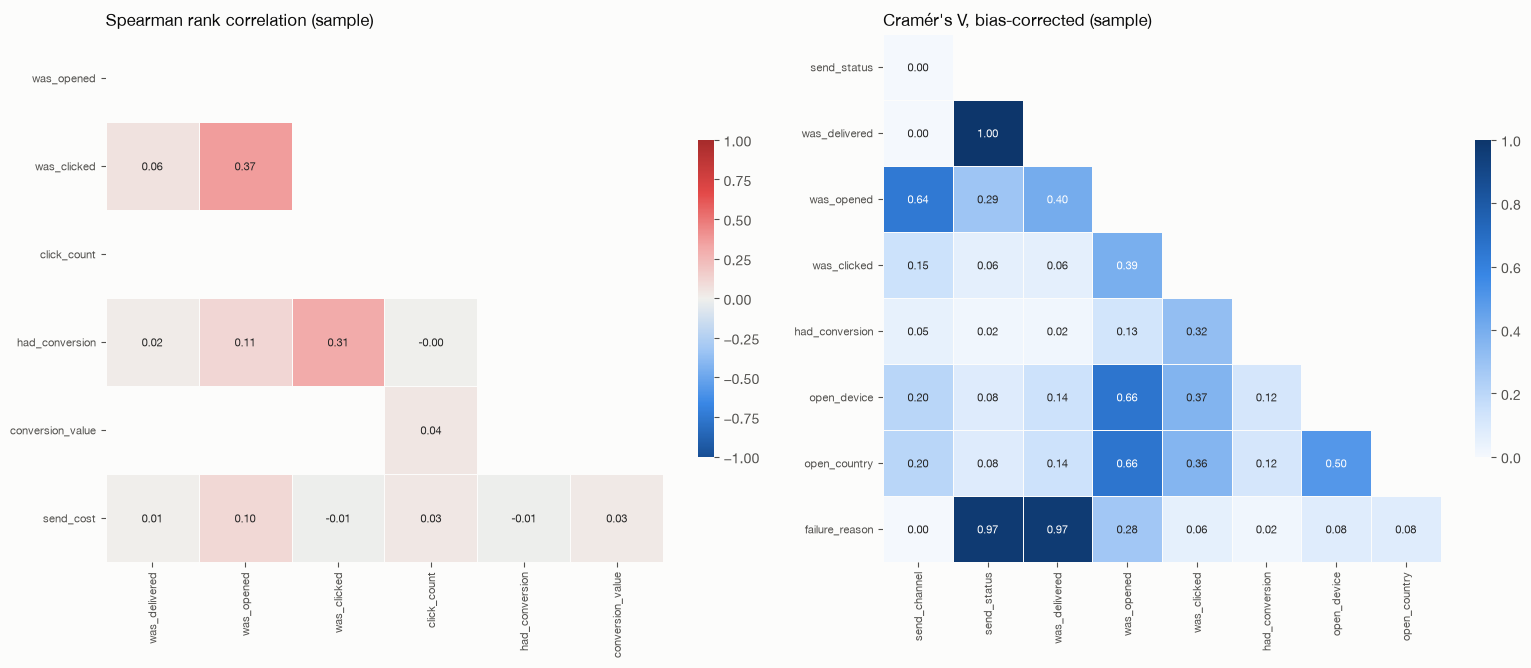

In [55]:
show_associations(t)
show_time(t)

In [56]:
fun = con.sql(
    """select send_channel, count(*) sent, sum(was_delivered::int) delivered, sum(was_opened::int) opened,
              sum(was_clicked::int) clicked, sum(had_conversion::int) converted,
              sum(send_cost) as cost, sum(conversion_value) as value
       from m_campaign_sends group by 1 order by sent desc"""
).df()
stages = ["sent", "delivered", "opened", "clicked", "converted"]
fig = go.Figure()
for i, r in fun.iterrows():
    fig.add_scatter(
        x=stages,
        y=[100 * r[s_] / r["sent"] for s_ in stages],
        mode="lines+markers",
        name=r["send_channel"],
        line=dict(color=theme.CATEGORICAL[i % 8], width=2),
    )
fig.update_layout(
    title="Funnel by channel (% of sent, exact)",
    height=380,
    yaxis_title="% of sent",
    yaxis_type="log",
    hovermode="x unified",
)
fig.show()
fun["cost_per_conversion"] = fun["cost"] / fun["converted"].replace(0, np.nan)
fun["value_per_cost"] = fun["value"] / fun["cost"]
display(
    fun.style.format(
        dict.fromkeys(stages + ["cost", "value"], "{:,.0f}")
        | {"cost_per_conversion": "{:,.2f}", "value_per_cost": "{:,.2f}"},
        na_rep="not tracked",
    ).hide(axis="index")
)

send_channel,sent,delivered,opened,clicked,converted,cost,value,cost_per_conversion,value_per_cost
Email,"620,195","582,810","174,893","35,183","3,497","2,903","8,905,809",0.83,"3,068.29"
SMS,"432,283","406,464","202,910","40,609","4,050","36,704","10,306,586",9.06,280.80
WhatsApp,"349,144","328,329",not tracked,0,0,"14,825",not tracked,not tracked,not tracked
Push,"290,650","273,298","109,506","22,001","2,252",136,"5,746,505",0.06,"42,311.83"
Voice,"54,529","51,143",not tracked,0,0,"9,277",not tracked,not tracked,not tracked


In [57]:
camp = con.sql(
    """select c.campaign_id, c.campaign_type, c.expected_conversion_rate, c.budget,
              count(*) sends, avg(s.had_conversion::int) actual_conversion_rate
       from m_campaign_sends s join m_marketing_campaigns c using (campaign_id)
       group by 1, 2, 3, 4"""
).df()
fig = px.scatter(
    camp,
    x="expected_conversion_rate",
    y="actual_conversion_rate",
    size="sends",
    color="campaign_type",
    hover_name="campaign_id",
    color_discrete_sequence=theme.CATEGORICAL,
    size_max=18,
)
lim = [0, float(max(camp["expected_conversion_rate"].max(), camp["actual_conversion_rate"].max()))]
fig.add_scatter(
    x=lim, y=lim, mode="lines", line=dict(dash="dash", color=theme.INK2), name="actual = expected"
)
fig.update_layout(title="Expected vs actual conversion per campaign (size = sends)", height=440)
fig.show()

## 7 · Digital
### 7.1 `digital_events` (fact, clickstream)
**Grain:** one event in a web or app session. **Key:** `event_id`. 15.6 M rows: every statistic here is a
DuckDB aggregate; only `info()`, missingno, KDEs and the association matrices use the 200k sample.

In [58]:
t = "digital_events"
show_overview(t)
show_describe(t)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Shape** 15,620,994 rows × 26 columns · **est. pandas memory (full table)** 5,954 MB · **PK** `event_id` unique (0 duplicated, 0 null)

`info()` on the sample (200,000 rows):

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   event_id          200000 non-null  str           
 1   event_date        200000 non-null  datetime64[us]
 2   process_date      200000 non-null  datetime64[us]
 3   customer_id       151963 non-null  str           
 4   session_id        200000 non-null  str           
 5   event_type        200000 non-null  str           
 6   event_category    200000 non-null  str           
 7   channel           200000 non-null  str           
 8   platform          190080 non-null  str           
 9   browser           76244 non-null   str           
 10  app_version       113749 non-null  str           
 11  page_url          189873 non-null  str           
 12  page_title        190058 non-null  str           
 13  action            180053 non-null  str           
 14  element_id     

,dtype,kind,non_null,nulls,placeholders,null_pct,missing_pct,distinct,distinct_pct
column,,,,,,,,,
event_id,VARCHAR,identifier,"15,620,994",0,0,0.0%,0.0%,"14,709,111",94.2%
event_date,TIMESTAMP,temporal,"15,620,994",0,0,0.0%,0.0%,"15,208,045",97.4%
process_date,DATE,temporal,"15,620,994",0,0,0.0%,0.0%,954,0.0%
customer_id,VARCHAR,identifier,"11,875,548","3,745,446",0,24.0%,24.0%,"173,849",1.5%
session_id,VARCHAR,identifier,"15,620,994",0,0,0.0%,0.0%,"1,837,582",11.8%
event_type,VARCHAR,categorical,"15,620,994",0,0,0.0%,0.0%,7,0.0%
event_category,VARCHAR,categorical,"15,620,994",0,0,0.0%,0.0%,4,0.0%
channel,VARCHAR,categorical,"15,620,994",0,0,0.0%,0.0%,4,0.0%
platform,VARCHAR,categorical,"14,840,467","780,527",0,5.0%,5.0%,5,0.0%


**Numeric columns, exact (full table)**: describe plus tails, shape and IQR outlier share

,count,mean,std,min,p01,p25,p50,p75,p99,max,skew,kurtosis,zero_share,negative_share,iqr_outlier_share
column,,,,,,,,,,,,,,,
event_value,"794,510.00","2,506.44","1,441.08",10.01,60.15,"1,256.65","2,507.07","3,754.13","4,950.46","4,999.98",-0.00,-1.20,0.0%,0.0%,0.0%
duration_seconds,"5,674,785.00",152.51,85.46,5.00,7.00,79.00,153.00,227.00,298.00,300.00,0.00,-1.20,0.0%,0.0%,0.0%


**Non-numeric columns (sample)**: count, distinct, most frequent value and its frequency

,count,unique,top,freq
event_id,200000,200000,EVT-WSOL7SOMWAQWXF0UOREF,1
event_date,200000,199732,2025-08-07 17:49:10,2
process_date,200000,1097,2025-12-08,428
customer_id,151963,92331,CLI-W7M7I6KE4UJG,9
session_id,200000,188461,SES-99G124GD04VCUZQRXDO1C3SELT2A,4
event_type,200000,7,PageView,76637
event_category,200000,4,Authentication,62438
channel,200000,4,Android App,69896
platform,190080,5,Android,85412
browser,76244,5,Chrome,22250


**Missing data (nulls + placeholders), sample.** 17 of 26 columns have gaps. The matrix rows run in time order, so a block that starts or stops mid-way means the field was added or dropped at some date.

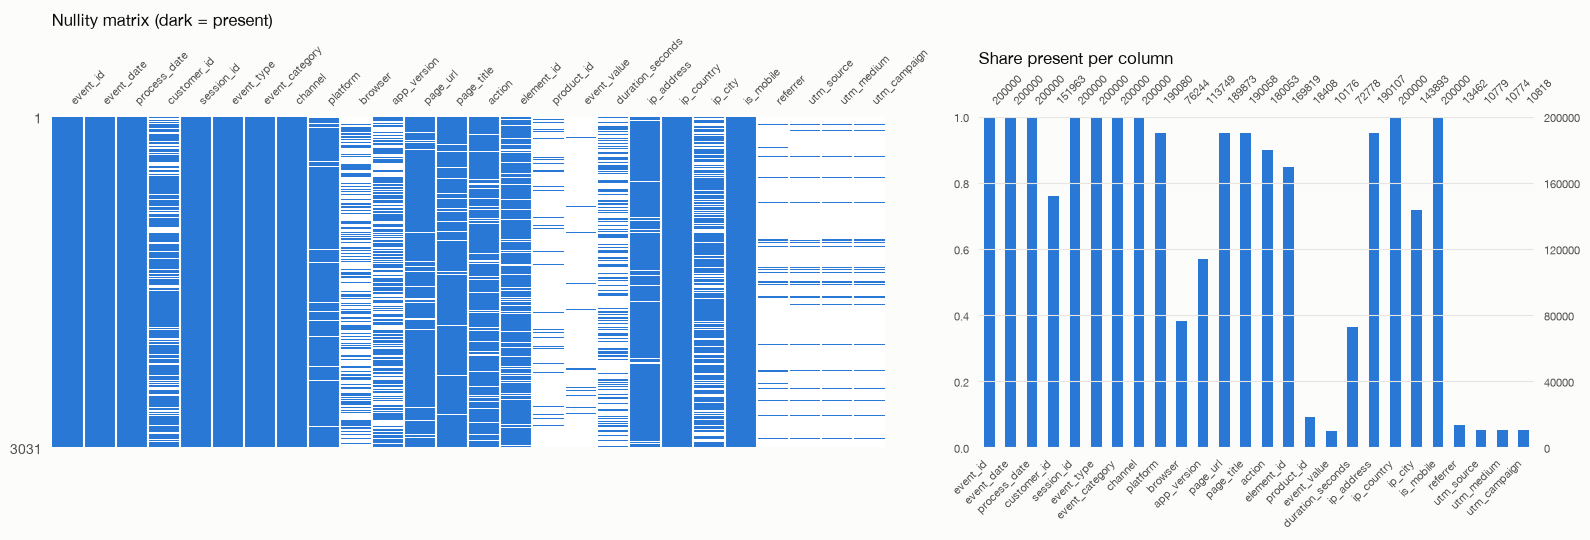

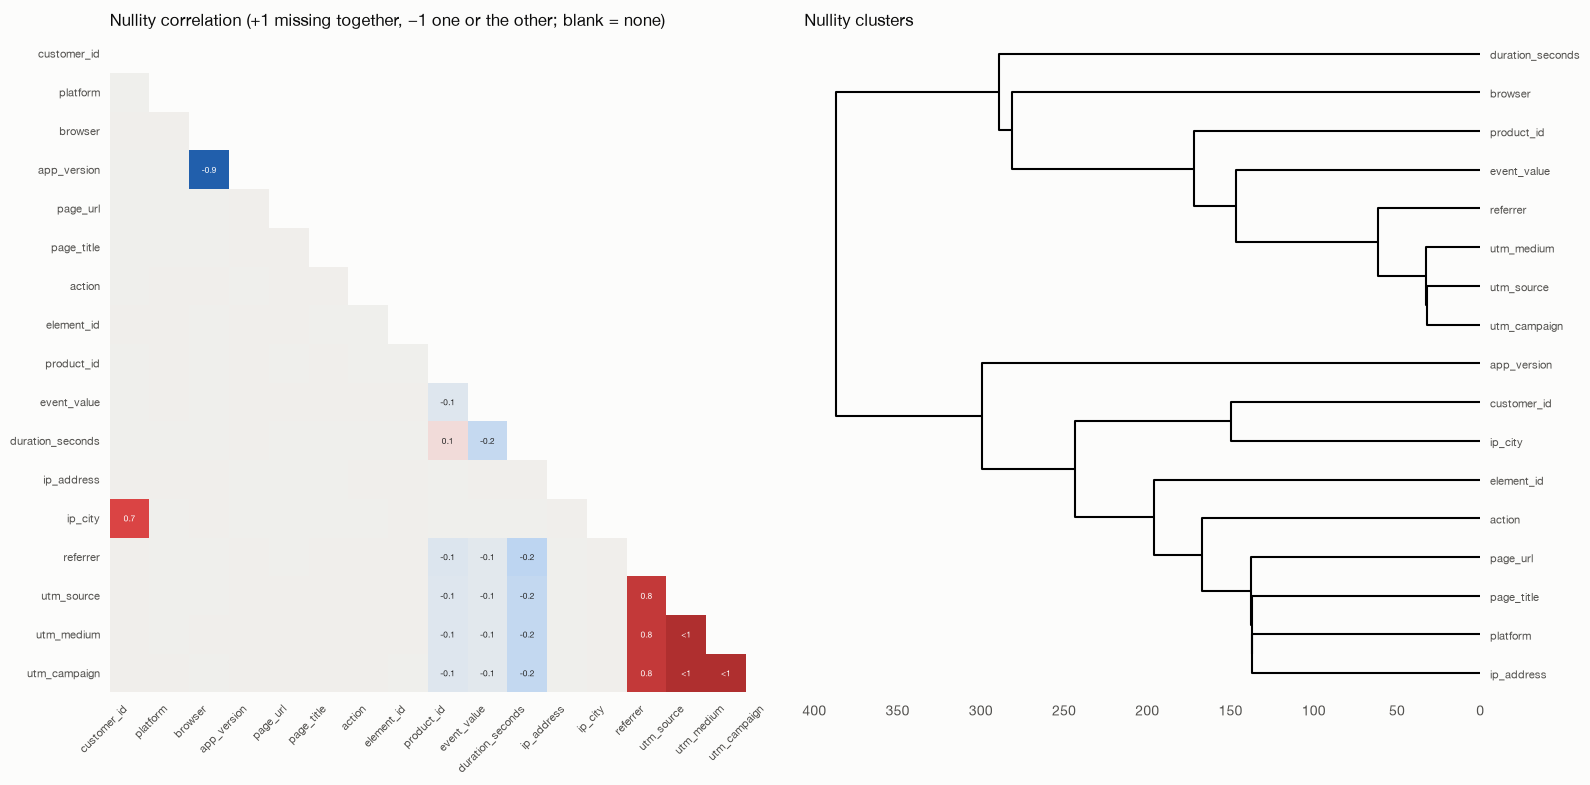

In [59]:
show_missing(t)

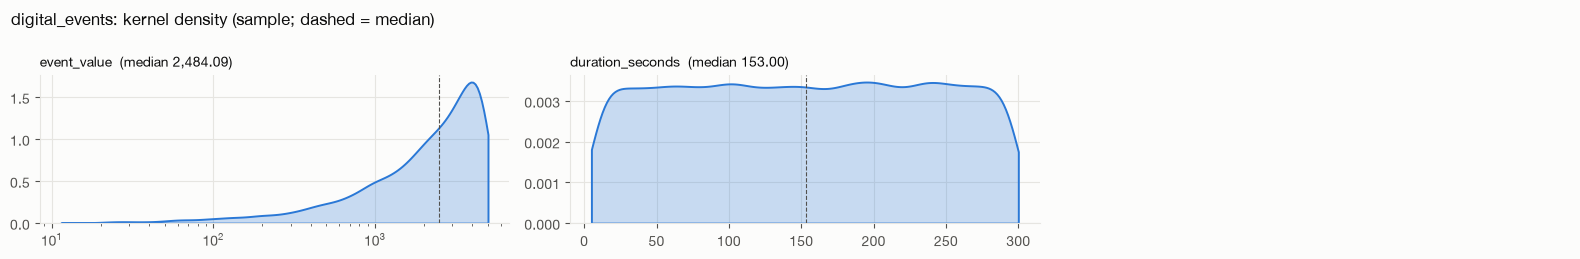

In [60]:
show_distributions(t)
show_categories(t)

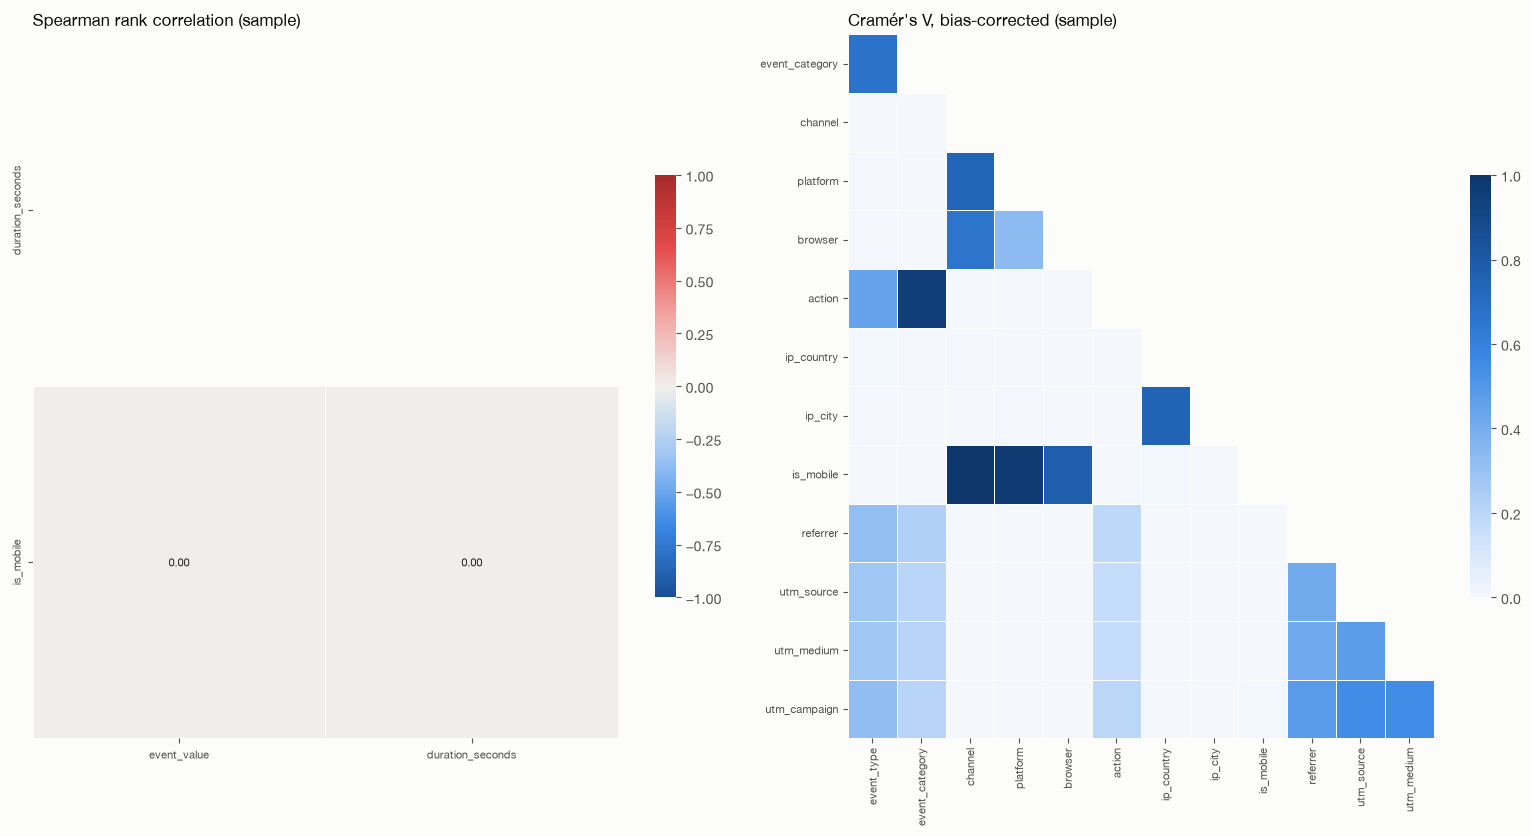

In [61]:
show_associations(t)
show_time(t)

In [62]:
heat(
    p.crosstab(con, rel(t), "event_type", "channel", normalize="column"),
    "Event type mix per channel (% of the channel's events, exact)",
)
depth = con.sql(
    """select least(n, 60) events_per_session, count(*) sessions
       from (select session_id, count(*) n from m_digital_events group by 1) group by 1 order by 1"""
).df()
fig = px.bar(depth, x="events_per_session", y="sessions", color_discrete_sequence=[theme.BLUE])
fig.update_layout(title="Session depth (events per session, 60 = 60 or more; exact)", height=320)
fig.show()
rate_bars(
    {
        "error events, by channel": rate_by(t, "channel", "event_type = 'Error'"),
        "error events, by app_version": rate_by(t, "app_version", "event_type = 'Error'", top=15),
    },
    "Error-event rate (%, exact, 95% Wilson CI)",
)

## 8 · Interactive explorers
Four tools to keep exploring on your own. They query **the full tables live** through DuckDB (the KDE, box
and violin views use the cached sample). **Run the notebook in JupyterLab** to use them; the HTML export
cannot run widgets.

In [63]:
import ipywidgets as widgets

out_col = widgets.Output()
w_t = widgets.Dropdown(options=TABLES, value="transactions", description="table")
w_c = widgets.Dropdown(description="column")
w_k = widgets.ToggleButtons(
    options=["histogram", "KDE", "box", "bar"], value="histogram", description="chart"
)
w_log = widgets.Checkbox(value=False, description="log scale")
w_bins = widgets.IntSlider(value=40, min=10, max=150, step=5, description="bins")


def _cols(*_):
    cols = p.columns(con, rel(w_t.value))
    w_c.options = cols.loc[
        cols["kind"].isin(["numeric", "categorical", "boolean", "temporal"]), "column"
    ].tolist()


def _draw_col(*_):
    t, c = w_t.value, w_c.value
    if c is None:
        return
    out_col.clear_output(wait=True)
    k = p.columns(con, rel(t)).set_index("column").loc[c, "kind"]
    with out_col:
        if w_k.value == "bar" or k in ("categorical", "boolean"):
            vc = p.value_counts(con, rel(t), c, top=25).iloc[::-1]
            fig = px.bar(
                vc,
                x="n",
                y="value",
                orientation="h",
                color_discrete_sequence=[theme.BLUE],
                log_x=w_log.value,
                hover_data={"share_pct": ":.2f"},
            )
            fig.update_yaxes(type="category")
            fig.update_layout(
                title=f"{t}.{c}: value counts (exact, {vc.attrs['cardinality']:,} distinct)",
                height=max(320, 22 * len(vc) + 120),
            )
            fig.show()
        elif k == "temporal":
            d = p.time_profile(con, rel(t), c, "day")
            px.line(
                d, x="period", y="value", title=f"{t}.{c}: rows per day (exact)", render_mode="svg"
            ).show()
        elif w_k.value == "histogram":
            hist = p.binned_hist(con, rel(t), c, bins=w_bins.value, log=w_log.value)
            fig = go.Figure(
                go.Bar(x=(hist["left"] + hist["right"]) / 2, y=hist["n"], marker_color=theme.BLUE)
            )
            fig.update_layout(
                title=f"{t}.{c}: histogram (exact" + (", log10 bins" if w_log.value else "") + ")",
                xaxis_type="log" if w_log.value else None,
                bargap=0.02,
                height=380,
            )
            fig.show()
        else:
            x = smp(t)[c].dropna().astype(float)
            x = x[x > 0] if w_log.value else x
            fig, ax = plt.subplots(figsize=(11, 3.6))
            if w_k.value == "KDE":
                sns.kdeplot(
                    x=x,
                    ax=ax,
                    fill=True,
                    color=theme.BLUE,
                    alpha=0.25,
                    log_scale=w_log.value,
                    cut=0,
                )
            else:
                sns.boxplot(x=x, ax=ax, color=theme.SEQ_BLUE[1], log_scale=w_log.value, fliersize=1)
            ax.set_title(f"{t}.{c}: {w_k.value} (sample of {len(x):,})")
            plt.show()


w_t.observe(_cols, "value")
for w in (w_t, w_c, w_k, w_log, w_bins):
    w.observe(_draw_col, "value")
_cols()
h("### 8.1 Column explorer")
display(widgets.VBox([widgets.HBox([w_t, w_c]), w_k, widgets.HBox([w_log, w_bins]), out_col]))

### 8.1 Column explorer

In [64]:
out_x = widgets.Output()
x_t = widgets.Dropdown(options=TABLES, value="transactions", description="table")
x_r, x_c = widgets.Dropdown(description="rows"), widgets.Dropdown(description="columns")
x_norm = widgets.ToggleButtons(
    options=["count", "row %", "column %", "total %"], value="row %", description="show"
)
x_top = widgets.IntSlider(value=12, min=3, max=40, description="top N")


def _xcols(*_):
    opts = p.cols_of(con, rel(x_t.value), "categorical", "boolean")
    x_r.options, x_c.options = opts, opts
    if len(opts) > 1:
        x_c.value = opts[1]


def _draw_x(*_):
    if not (x_r.value and x_c.value) or x_r.value == x_c.value:
        return
    out_x.clear_output(wait=True)
    norm = {"count": None, "row %": "row", "column %": "column", "total %": "all"}[x_norm.value]
    ct = p.crosstab(con, rel(x_t.value), x_r.value, x_c.value, top=x_top.value, normalize=norm)
    with out_x:
        heat(
            ct,
            f"{x_t.value}: {x_r.value} × {x_c.value} ({x_norm.value}, exact)",
            fmt="d" if norm is None else ".1f",
        )


x_t.observe(_xcols, "value")
for w in (x_t, x_r, x_c, x_norm, x_top):
    w.observe(_draw_x, "value")
_xcols()
h("### 8.2 Cross-matrix explorer")
display(widgets.VBox([widgets.HBox([x_t, x_r, x_c]), x_norm, x_top, out_x]))

### 8.2 Cross-matrix explorer

In [65]:
out_g = widgets.Output()
g_t = widgets.Dropdown(options=TABLES, value="transactions", description="table")
g_y, g_by = widgets.Dropdown(description="number"), widgets.Dropdown(description="split by")
g_k = widgets.ToggleButtons(options=["box", "violin", "KDE"], value="box", description="chart")
g_log = widgets.Checkbox(value=True, description="log scale")


def _gcols(*_):
    g_y.options = p.cols_of(con, rel(g_t.value), "numeric")
    s = smp(g_t.value)
    g_by.options = [
        c for c in p.cols_of(con, rel(g_t.value), "categorical", "boolean") if s[c].nunique() <= 30
    ]


def _draw_g(*_):
    if not (g_y.value and g_by.value):
        return
    out_g.clear_output(wait=True)
    s = smp(g_t.value)[[g_y.value, g_by.value]].dropna()
    if g_log.value:
        s = s[s[g_y.value] > 0]
    order = s.groupby(g_by.value)[g_y.value].median().sort_values().index
    with out_g:
        fig, ax = plt.subplots(figsize=(12, max(3.5, 0.38 * len(order) + 1.5)))
        if g_k.value == "KDE":
            sns.kdeplot(
                data=s,
                x=g_y.value,
                hue=g_by.value,
                common_norm=False,
                log_scale=g_log.value,
                ax=ax,
                cut=0,
                palette=dict(zip(order, (theme.CATEGORICAL * 4)[: len(order)])),
            )
        else:
            fn = sns.boxplot if g_k.value == "box" else sns.violinplot
            kw = {"fliersize": 1} if g_k.value == "box" else {"cut": 0, "inner": "quartile"}
            fn(
                data=s,
                x=g_y.value,
                y=g_by.value,
                order=order,
                ax=ax,
                color=theme.SEQ_BLUE[1],
                log_scale=g_log.value,
                linewidth=0.8,
                **kw,
            )
        ax.set_title(f"{g_t.value}: {g_y.value} by {g_by.value} (sample of {len(s):,})")
        plt.show()


g_t.observe(_gcols, "value")
for w in (g_t, g_y, g_by, g_k, g_log):
    w.observe(_draw_g, "value")
_gcols()
h("### 8.3 Numeric-by-category explorer")
display(widgets.VBox([widgets.HBox([g_t, g_y, g_by]), widgets.HBox([g_k, g_log]), out_g]))

### 8.3 Numeric-by-category explorer

In [66]:
out_ts = widgets.Output()
ts_t = widgets.Dropdown(options=list(TIME), value="transactions", description="table")
ts_d = widgets.Dropdown(description="date")
ts_grain = widgets.ToggleButtons(
    options=["day", "week", "month", "quarter"], value="week", description="grain"
)
ts_agg = widgets.ToggleButtons(
    options=["count", "sum", "avg"], value="count", description="measure"
)
ts_v = widgets.Dropdown(description="of column")
ts_split = widgets.Dropdown(description="split by")


def _tscols(*_):
    ts_d.options = p.cols_of(con, rel(ts_t.value), "temporal")
    ts_d.value = TIME[ts_t.value][0]
    ts_v.options = p.cols_of(con, rel(ts_t.value), "numeric", "boolean")
    s = smp(ts_t.value)
    # at most 8 series: one fixed palette slot each, never cycled
    ts_split.options = ["(none)"] + [
        c for c in p.cols_of(con, rel(ts_t.value), "categorical") if s[c].nunique() <= 8
    ]


def _draw_ts(*_):
    if not ts_d.value:
        return
    out_ts.clear_output(wait=True)
    measure = (
        "count(*)"
        if ts_agg.value == "count" or not ts_v.value
        else f"{ts_agg.value}({p.q(ts_v.value)}::double)"
    )
    split = ts_split.value if ts_split.value and ts_split.value != "(none)" else None
    d = con.sql(
        f"""select date_trunc('{ts_grain.value}', {p.q(ts_d.value)})::date as period,
                   {p.q(split) + "::varchar" if split else "'all'"} as series, {measure} as value
            from {rel(ts_t.value)} where {p.q(ts_d.value)} is not null group by 1, 2 order by 1"""
    ).df()
    label = "rows" if ts_agg.value == "count" else f"{ts_agg.value} of {ts_v.value}"
    with out_ts:
        fig = px.line(
            d,
            x="period",
            y="value",
            color="series",
            color_discrete_sequence=theme.CATEGORICAL,
            render_mode="svg",
        )
        fig.update_layout(
            title=f"{ts_t.value}: {label} per {ts_grain.value} of {ts_d.value} (exact)",
            height=420,
            yaxis_title=label,
            hovermode="x unified",
        )
        fig.show()


ts_t.observe(_tscols, "value")
for w in (ts_t, ts_d, ts_grain, ts_agg, ts_v, ts_split):
    w.observe(_draw_ts, "value")
_tscols()
h("### 8.4 Time explorer")
display(widgets.VBox([widgets.HBox([ts_t, ts_d, ts_v]), ts_grain, ts_agg, ts_split, out_ts]))

### 8.4 Time explorer

### 8.5 Row browser
The cached sample of any table (PII and free-text columns removed), with column search and SearchBuilder
filters. Change `TABLE` and re-run the cell.

In [67]:
TABLE = "transactions"
show(
    p.safe(smp(TABLE)).head(5000),
    caption=f"{TABLE}: first 5,000 sampled rows (PII removed)",
    layout={"top1": "searchBuilder"},
    pageLength=15,
    classes="display compact nowrap",
    scrollX=True,
)

## 9 · Findings to carry into bronze and silver
The cell below recomputes every number quoted here from the full raw tables, so the list stays honest
if the extract changes. Each finding names the layer that should act on it.

**Keys and integrity**
1. **Every primary key is unique and non-null** in all 12 keyed tables, and the complaint lifecycle has
   no impossible date orders: the extracts are structurally sound.
2. **`customers.registration_branch_id` (100%) and `service_agents.assigned_branch_id` (≈99.8%) point to
   branches that do not exist.** They share the `SUC-…` format of `branches.branch_id` but are
   independent random codes, while `products.opening_branch_id` and `transactions.branch_id` resolve fully.
   *Silver:* no join from customers or agents to branches; *gold:* an "unknown branch" member if one is modelled.
3. **24% of `digital_events` have no `customer_id`** (anonymous sessions); every non-null id resolves.
   *Gold:* keep them in the clickstream fact with an "anonymous" customer member.

**Money and currencies**
4. **`amount` mixes USD, COP and ARS**, about 10⁴× apart; it must never be summed across currencies.
   **`amount_usd` is null for every USD row** (by design) and uses an **almost fixed rate** for COP
   (≈4,000 ± 0.1%) and ARS (≈350 ± 0.1%), while the same pairs in `daily_exchange_rates` vary with a ≈1.2%
   coefficient of variation: the conversion did not use the daily table. *Silver:* one reporting-currency
   amount, from the daily FX table, filled for every row. The FX table itself has **no trend**: every pair
   stays within ±2% of its median and drifts less than 0.2% over three years (no ARS devaluation), so it
   reads as simulated rather than market data.
5. **All `México` transactions are in USD** (no MXN at all, although the FX table quotes MXN); their median
   amount matches the other USD rows, so the label, not the scale, is suspect. To confirm with the data owner.
6. **`estimated_monthly_income` is in local currency** (median ≈ 39k MX, 0.8M AR, 9.2M CO): segment
   comparisons across countries are meaningless until silver converts it.

**Labels and conformance**
7. **`transaction_country` spells Mexico two ways** (`México` for domestic rows, `Mexico` for a cross-border
   block of ≈40k rows like USA, Spain and Brazil). *Silver:* a conformed country dimension (ISO codes).
8. **NPS cannot be computed from this table as labelled:** NPS surveys only score 2–7, so there are no
   promoters and the recomputed NPS is about −75; ≈3.3k NPS rows have no `nps_category`. Treat the score
   scale as unknown until documented.
9. **Opens, clicks and conversions are not tracked for WhatsApp and Voice sends** (all null): funnel KPIs
   exist only for Email, SMS and Push.

**Quality of optional fields**
10. **Transaction coordinates are mostly placeholders:** ≈81% of rows have none, and about half of the
    rest sit within 1.5° of (0, 0). *Silver:* null them; do not use them for geo features.
11. **Gaps are plain `NULL`s, no disguised placeholders**, so bronze needs no token cleaning, and no table
    shows a time block (a field appearing or vanishing at some date; `campaign_sends` null rates swing by
    month only because the channel mix does, and are flat within each channel). Missingness is mostly
    **structural**: fields go missing together by design (complaint dates for stages a case has not reached,
    merchant name + category, the latitude/longitude pair, the UTM triplet, `claimed_amount` + `currency`). Customer attributes are the
    exception: their gaps are uncorrelated (random), so silver can impute them per column.
12. **Fraud is rare (≈0.1%, 1 in ~1,000) and `fraud_score` leaks the label.** No legitimate transaction
    scores above 30, while fraud scores spread evenly over 0–100: `fraud_score > 30` flags fraud with 100%
    precision and ≈55% recall. The score was likely generated from `is_fraud`, so it must **not** be a model
    feature (*gold / ML:* drop it or treat it as a benchmark). Fraud rates are flat (≈0.1%) across type,
    channel, country and merchant category, so categorical signal is weak.
13. **6% of credit products are over their limit**, and ≈15% of credit products with a recorded DPD are
    past due; worth reconciling with collections rules in gold.

In [68]:
ev = {}
ev["PK duplicates (all keyed tables)"] = sum(
    p.pk_check(con, rel(t), k)["duplicate_keys"] for t, k in PK.items()
)
ev["customers.registration_branch_id orphan %"] = float(
    ri.set_index("child").loc["customers.registration_branch_id", "orphan_pct"]
)
ev["service_agents.assigned_branch_id orphan %"] = float(
    ri.set_index("child").loc["service_agents.assigned_branch_id", "orphan_pct"]
)
ev["digital_events null customer_id %"] = con.sql(
    "select 100 * avg((customer_id is null)::int) from m_digital_events"
).fetchone()[0]
ev["USD rows with amount_usd null %"] = con.sql(
    "select 100 * avg((amount_usd is null)::int) from m_transactions where currency = 'USD'"
).fetchone()[0]
for c in ("COP", "ARS"):
    ev[f"{c} implied fixed rate (amount / amount_usd), min–max"] = "{:,.2f} – {:,.2f}".format(
        *con.sql(
            f"""select min(amount / amount_usd), max(amount / amount_usd) from m_transactions
                where currency = '{c}' and amount_usd > 0"""
        ).fetchone()
    )
ev["USD→COP and USD→ARS daily rate, coefficient of variation %"] = " / ".join(
    f"{v:.2f}"
    for (v,) in con.sql(
        """select 100 * stddev(exchange_rate) / avg(exchange_rate) from m_daily_exchange_rates
           where source_currency = 'USD' and target_currency in ('COP', 'ARS')
           group by target_currency order by target_currency desc"""
    ).fetchall()
)
ev["México transactions not in USD"] = con.sql(
    "select count(*) from m_transactions where transaction_country = 'México' and currency <> 'USD'"
).fetchone()[0]
ev["'Mexico' (unaccented) transactions"] = con.sql(
    "select count(*) from m_transactions where transaction_country = 'Mexico'"
).fetchone()[0]
ev["NPS surveys: main_score range"] = "{} – {}".format(
    *con.sql(
        "select min(main_score), max(main_score) from m_satisfaction_surveys where survey_type = 'NPS'"
    ).fetchone()
)
ev["NPS recomputed"] = nps
ev["WhatsApp + Voice sends with a known open flag"] = con.sql(
    "select count(was_opened) from m_campaign_sends where send_channel in ('WhatsApp', 'Voice')"
).fetchone()[0]
ev["transactions without coordinates %"] = con.sql(
    "select 100 * avg((latitude is null)::int) from m_transactions"
).fetchone()[0]
ev["coordinates within 1.5° of (0, 0) %"] = 100 * nk / nn
ev["placeholder cells (all tables)"] = int(gaps["placeholders"].sum())
ev["fraud rate %"] = con.sql("select 100 * avg(is_fraud::int) from m_transactions").fetchone()[0]
ev["fraud_score > 30: precision % / recall %"] = (
    f"{100 * leak[1] / leak[2]:.1f} / {100 * leak[1] / leak[3]:.1f}"
)
ev["credit products over limit %"] = 100 * (util["utilisation"] > 1).mean()
ev["credit products with recorded DPD that are past due %"] = con.sql(
    "select 100 * avg((days_past_due > 0)::int) from m_products"
).fetchone()[0]
display(
    pd.Series(ev, name="value")
    .map(lambda v: f"{v:,.2f}" if isinstance(v, float) else (f"{v:,}" if isinstance(v, int) else v))
    .to_frame()
)

,value
PK duplicates (all keyed tables),0
customers.registration_branch_id orphan %,100.00
service_agents.assigned_branch_id orphan %,99.76
digital_events null customer_id %,23.98
USD rows with amount_usd null %,100.00
"COP implied fixed rate (amount / amount_usd), min–max","3,996.07 – 4,003.81"
"ARS implied fixed rate (amount / amount_usd), min–max",349.66 – 350.34
"USD→COP and USD→ARS daily rate, coefficient of variation %",1.18 / 1.15
México transactions not in USD,0
'Mexico' (unaccented) transactions,"40,515"
